# Period-arbitration injection–recovery benchmark

This notebook tests the **current MALCA period decision path**, including:

1. Plavchan PDM and conditional entropy (CE);
2. their shared native-period correction over
   \(P\times\{1,1/2,1/3,1/4,2,3,4\}\);
3. the production PDM-versus-CE selector;
4. the independent short-period Lomb–Scargle diagnostic;
5. long-period Lomb–Scargle discovery;
6. event-period and long-period consensus; and
7. the final reported period (consensus when finite, otherwise the corrected
   short-period selection).

The benchmark distinguishes:

- **exact recovery**: the reported period is within 5% of the injected
  fundamental;
- **harmonic recovery**: it is within 5% of the fundamental or one of the
  tested integer harmonics/subharmonics;
- **wrong-harmonic recovery**: harmonic recovery succeeds but exact recovery
  fails;
- **null false positives**: a period is reported for a non-periodic control;
- method choice, confidence calibration, alias behavior, and the effect of
  supplying event epochs.

## Important interpretation boundary

`oracle_complete` and `noisy_partial` use known injected dip epochs. They test
the **period arbitration conditional on event timing**, not the upstream event
detector's completeness. The `none` arm is the corresponding event-free
ablation. A separate end-to-end event-detection injection suite is needed to
fold event-detection incompleteness into the final recovery rate.

The broad screening tier uses no bootstrap permutations so thousands of
injections are affordable. A stratified subset can use the production
100-block bootstrap. Always report those two tiers separately.

In [20]:
from __future__ import annotations

from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Any
import hashlib
import inspect
import json
import os
import subprocess
import time
import warnings
import zlib

# Eight worker processes; keep each worker single-threaded to avoid oversubscription.
for _thread_var in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "NUMBA_NUM_THREADS"):
    os.environ.setdefault(_thread_var, "1")

import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

from malca.io.notebook_paths import find_repo_root
from malca.config import (
    LS_ALIAS_PERIODS,
    POST_FILTER_CE_MIN_ENTROPY,
    POST_FILTER_CE_SNR_THRESHOLD,
    POST_FILTER_PDM_METHOD,
    POST_FILTER_PDM_MIN_THETA,
    POST_FILTER_PDM_SNR_THRESHOLD,
)
from malca.core.period_bounds import STAGE_POSTFILTER, bounds_from_jd
from malca.core.period_pipeline import compute_period_consensus_for_lc
from malca.core.phase import align_v_to_g_magnitude
from malca.core.stats import (
    bootstrap_lomb_scargle,
    compute_ce_stats,
    compute_pdm_stats,
)
from malca.stv.event_period import event_based_period
from malca.stv.filter import (
    _build_periodicity_band_residuals,
    _correct_native_period,
    _method_support_score,
    _select_native_periodicity_method,
)
from malca.stv.periodicity_gate import prepare_periodicity_lightcurve

sns.set_theme(context="paper", style="ticks")

# Historical v1 analysis: keep its default execution to a fresh smoke run.
PROFILE = os.environ.get("MALCA_PERIOD_BENCH_PROFILE", "smoke")
RUN_TAG = os.environ.get("MALCA_PERIOD_BENCH_TAG", f"historical_{PROFILE}_v2")
RUN_BENCHMARK = False  # Historical/bootstrap benchmark stays disabled.


@dataclass(frozen=True)
class BenchmarkConfig:
    profile: str
    n_signal_bases: int
    n_null_trials: int
    bootstrap_fraction: float
    n_bootstrap: int
    checkpoint_every: int
    workers: int = 8
    seed: int = 20260725
    exact_rel_tol: float = 0.05
    harmonic_factors: tuple[float, ...] = (0.25, 1 / 3, 0.5, 1.0, 2.0, 3.0, 4.0)
    signal_morphologies: tuple[str, ...] = (
        "sinusoid",
        "gaussian_dip",
        "double_dip",
        "asymmetric_dip",
        "quasi_periodic_dip",
    )
    null_morphologies: tuple[str, ...] = (
        "white_noise",
        "red_noise",
        "seasonal_trend",
        "isolated_dip",
        "aperiodic_dips",
    )
    event_modes: tuple[str, ...] = ("none", "oracle_complete", "noisy_partial")
    baseline_days: float = 4000.0
    amplitude_snr: tuple[float, ...] = (2.0, 4.0, 8.0, 16.0)
    width_fractions: tuple[float, ...] = (0.01, 0.03, 0.08, 0.18)
    sampling_densities: tuple[float, ...] = (0.18, 0.35, 0.60)
    median_errors: tuple[float, ...] = (0.015, 0.03, 0.06)


PROFILES = {
    # Small enough to execute as a structural validation.
    "smoke": BenchmarkConfig("smoke", 4, 3, 0.0, 0, 4),
    # Broad discovery map; no empirical p-values.
    "discovery": BenchmarkConfig("discovery", 600, 250, 0.0, 0, 25),
    # Paper-oriented two-tier run: broad map plus a 100-bootstrap subset.
    "paper": BenchmarkConfig("paper", 1200, 500, 0.20, 100, 10),
    # Smaller but every trial uses the production bootstrap decision regime.
    "production": BenchmarkConfig("production", 250, 150, 1.0, 100, 5),
}
if PROFILE not in PROFILES:
    raise ValueError(f"Unknown PROFILE={PROFILE!r}; choose from {tuple(PROFILES)}")
CFG = PROFILES[PROFILE]

ROOT = find_repo_root()
RUN_DIR = (
    ROOT / "output" / "notebooks" / "period_arbitration_injection_recovery" / RUN_TAG
    if RUN_BENCHMARK
    else Path(os.environ.get("TMPDIR", "/tmp")) / "malca_period_historical_disabled"
)
if RUN_BENCHMARK:
    RUN_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_PATH = RUN_DIR / "trial_results.parquet"
DESIGN_PATH = RUN_DIR / "trial_design.parquet"
CONFIG_PATH = RUN_DIR / "config_and_provenance.json"

print(CFG)
print("outputs:", RUN_DIR)

BenchmarkConfig(profile='smoke', n_signal_bases=4, n_null_trials=3, bootstrap_fraction=0.0, n_bootstrap=0, checkpoint_every=4, workers=8, seed=20260725, exact_rel_tol=0.05, harmonic_factors=(0.25, 0.3333333333333333, 0.5, 1.0, 2.0, 3.0, 4.0), signal_morphologies=('sinusoid', 'gaussian_dip', 'double_dip', 'asymmetric_dip', 'quasi_periodic_dip'), null_morphologies=('white_noise', 'red_noise', 'seasonal_trend', 'isolated_dip', 'aperiodic_dips'), event_modes=('none', 'oracle_complete', 'noisy_partial'), baseline_days=4000.0, amplitude_snr=(2.0, 4.0, 8.0, 16.0), width_fractions=(0.01, 0.03, 0.08, 0.18), sampling_densities=(0.18, 0.35, 0.6), median_errors=(0.015, 0.03, 0.06))
outputs: /var/folders/z5/95nmr_n10ls6x2913x09nzs80000gn/T/malca_period_historical_disabled


## Trial design

Periods are drawn from three deliberately different regimes:

- **alias stress:** within a few percent of the configured daily, lunar, and
  annual aliases;
- **short:** log-uniform over 0.2–100 d;
- **long:** fixed observed-cycle counts (1.5, 2, 3, 5, or 8 cycles).

Dip-like injections are repeated under three paired event-information modes.
Sinusoids have no event epochs. The bootstrap subset is chosen at the
base-trial level, so event-mode comparisons share the same photometry and
bootstrap regime.

In [21]:
def _stable_seed(*parts: object) -> int:
    token = "|".join(map(str, parts)).encode("utf-8")
    return int(zlib.crc32(token) & 0x7FFFFFFF)


def _period_draw(rng: np.random.Generator, baseline_days: float) -> tuple[float, str, float | None]:
    u = float(rng.random())
    if u < 0.30:
        alias = float(rng.choice(np.asarray(LS_ALIAS_PERIODS, dtype=float)))
        return alias * float(np.exp(rng.uniform(-0.035, 0.035))), "alias_stress", alias
    if u < 0.68:
        return float(np.exp(rng.uniform(np.log(0.2), np.log(100.0)))), "short", None
    cycles = float(rng.choice([1.5, 2.0, 3.0, 5.0, 8.0]))
    return min(float(baseline_days / cycles), 0.58 * baseline_days, 5000.0), "long", None


def build_trial_design(cfg: BenchmarkConfig) -> pd.DataFrame:
    rng = np.random.default_rng(cfg.seed)
    rows: list[dict[str, Any]] = []
    dip_morphologies = {"gaussian_dip", "double_dip", "asymmetric_dip", "quasi_periodic_dip"}

    for base_index in range(cfg.n_signal_bases):
        base_id = f"signal-{base_index:06d}"
        baseline_days = float(cfg.baseline_days)
        period, regime, alias_target = _period_draw(rng, baseline_days)
        morphology = str(rng.choice(cfg.signal_morphologies))
        boot = bool(rng.random() < cfg.bootstrap_fraction)
        common = {
            "base_trial_id": base_id,
            "is_signal": True,
            "morphology": morphology,
            "period_regime": regime,
            "alias_target_days": alias_target,
            "true_period_days": period,
            "requested_baseline_days": baseline_days,
            "amplitude_snr": float(rng.choice(cfg.amplitude_snr)),
            "width_fraction": float(rng.choice(cfg.width_fractions)),
            "sampling_density": float(rng.choice(cfg.sampling_densities)),
            "median_error": float(rng.choice(cfg.median_errors)),
            "phase0": float(rng.uniform(0.0, 1.0)),
            "signal_seed": _stable_seed(cfg.seed, base_id, "signal"),
            "n_bootstrap": int(cfg.n_bootstrap if boot else 0),
            "decision_regime": "production_bootstrap" if boot else "screening_no_bootstrap",
        }
        modes = cfg.event_modes if morphology in dip_morphologies else ("none",)
        for event_mode in modes:
            rows.append({
                **common,
                "trial_id": f"{base_id}-{event_mode}",
                "event_mode": event_mode,
                "trial_seed": _stable_seed(cfg.seed, base_id, event_mode),
            })

    for index in range(cfg.n_null_trials):
        base_id = f"null-{index:06d}"
        boot = bool(rng.random() < cfg.bootstrap_fraction)
        rows.append({
            "base_trial_id": base_id,
            "trial_id": f"{base_id}-none",
            "is_signal": False,
            "morphology": str(rng.choice(cfg.null_morphologies)),
            "period_regime": "null",
            "alias_target_days": np.nan,
            "true_period_days": np.nan,
            "requested_baseline_days": float(cfg.baseline_days),
            "amplitude_snr": float(rng.choice(cfg.amplitude_snr)),
            "width_fraction": float(rng.choice(cfg.width_fractions)),
            "sampling_density": float(rng.choice(cfg.sampling_densities)),
            "median_error": float(rng.choice(cfg.median_errors)),
            "phase0": float(rng.uniform(0.0, 1.0)),
            "signal_seed": _stable_seed(cfg.seed, base_id, "null"),
            "event_mode": "none",
            "trial_seed": _stable_seed(cfg.seed, base_id, "none"),
            "n_bootstrap": int(cfg.n_bootstrap if boot else 0),
            "decision_regime": "production_bootstrap" if boot else "screening_no_bootstrap",
        })

    design = pd.DataFrame(rows)
    design["design_version"] = "period-arbitration-injection-v1"
    return design


design = build_trial_design(CFG)
print(design.shape)
display(pd.crosstab(design["morphology"], design["event_mode"]))
display(pd.crosstab(design["period_regime"], design["decision_regime"]))

(11, 19)


event_mode,noisy_partial,none,oracle_complete
morphology,,,
aperiodic_dips,0,1,0
double_dip,1,1,1
gaussian_dip,1,1,1
red_noise,0,1,0
sinusoid,0,2,0
white_noise,0,1,0


decision_regime,screening_no_bootstrap
period_regime,
long,4
null,3
short,4


## Synthetic ASAS-SN-like light curves

The simulator includes seasonal gaps, clustered nightly observations, mixed
g/V bands, multiple cameras, heteroscedastic uncertainties, nightly
correlation, and small camera offsets. V magnitudes are subsequently aligned
to g through the same MALCA preparation used by the period validator.

The suite includes sinusoidal, single-dip, double-dip, asymmetric-dip, and
quasi-periodic signals plus five null families. These are controlled stress
tests, not a complete generative model of the survey.

In [22]:
def _circular_distance(phase: np.ndarray, center: float) -> np.ndarray:
    delta = (np.asarray(phase) - float(center) + 0.5) % 1.0 - 0.5
    return delta


def _event_centers(t_min: float, t_max: float, period: float, phase0: float) -> list[float]:
    anchor = t_min + phase0 * period
    k0 = int(np.floor((t_min - anchor) / period)) - 1
    k1 = int(np.ceil((t_max - anchor) / period)) + 1
    return [anchor + k * period for k in range(k0, k1 + 1) if t_min <= anchor + k * period <= t_max]


def simulate_lightcurve(row: pd.Series | dict[str, Any]) -> tuple[pd.DataFrame, list[float]]:
    row = dict(row)
    rng = np.random.default_rng(int(row["signal_seed"]))
    baseline = float(row["requested_baseline_days"])
    density = float(row["sampling_density"])
    median_error = float(row["median_error"])
    start_jd = 2458000.0

    times: list[float] = []
    year = 0
    while year * 365.25 < baseline:
        season_start = year * 365.25 + float(rng.uniform(10.0, 80.0))
        season_length = float(rng.uniform(170.0, 260.0))
        n_nights = max(12, int(season_length * density))
        nights = np.sort(rng.uniform(season_start, season_start + season_length, n_nights))
        for night in nights:
            for _ in range(int(rng.choice([1, 1, 1, 2, 2, 3]))):
                t = start_jd + night + float(rng.uniform(0.0, 0.08))
                if t <= start_jd + baseline:
                    times.append(t)
        year += 1
    # Fix the actual first-to-last observing baseline, not only the design window.
    times.extend([start_jd, start_jd + baseline])
    jd = np.asarray(sorted(set(times)), dtype=float)
    if jd.size < 50:
        raise RuntimeError(f"simulator produced only {jd.size} observations")

    band = rng.choice([0, 1], size=jd.size, p=[0.78, 0.22]).astype(int)
    camera = rng.integers(0, 5, size=jd.size)
    error = median_error * np.exp(rng.normal(0.0, 0.25, size=jd.size))
    # These two synthetic observations define the required observing baseline.
    # Give them representative uncertainties so canonical error clipping cannot
    # remove an endpoint and silently shorten the prepared baseline.
    baseline_anchor = np.isclose(jd, start_jd, rtol=0.0, atol=1e-9) | np.isclose(
        jd, start_jd + baseline, rtol=0.0, atol=1e-9
    )
    if int(baseline_anchor.sum()) != 2:
        raise RuntimeError("simulator did not retain exactly two baseline anchors")
    error[baseline_anchor] = median_error
    camera_offsets = rng.normal(0.0, 0.12 * median_error, size=5)
    night_id = np.floor(jd - start_jd).astype(int)
    unique_nights, inverse = np.unique(night_id, return_inverse=True)
    night_offsets = rng.normal(0.0, 0.35 * median_error, size=unique_nights.size)

    mag = (
        13.5
        + 0.25 * band
        + camera_offsets[camera]
        + night_offsets[inverse]
        + rng.normal(0.0, error)
    )

    amplitude = float(row["amplitude_snr"]) * median_error
    width_frac = float(row["width_fraction"])
    morphology = str(row["morphology"])
    true_period = float(row["true_period_days"]) if bool(row["is_signal"]) else np.nan
    phase0 = float(row["phase0"])
    epochs: list[float] = []

    if bool(row["is_signal"]):
        phase = ((jd - jd.min()) / true_period) % 1.0
        d0 = _circular_distance(phase, phase0)
        if morphology == "sinusoid":
            mag += amplitude * np.sin(2.0 * np.pi * (phase - phase0))
        elif morphology == "gaussian_dip":
            mag += amplitude * np.exp(-0.5 * (d0 / width_frac) ** 2)
        elif morphology == "double_dip":
            d1 = _circular_distance(phase, (phase0 + 0.5) % 1.0)
            mag += amplitude * np.exp(-0.5 * (d0 / width_frac) ** 2)
            mag += 0.55 * amplitude * np.exp(-0.5 * (d1 / (1.25 * width_frac)) ** 2)
        elif morphology == "asymmetric_dip":
            scale = np.where(d0 < 0, max(width_frac / 2.5, 1e-3), 1.8 * width_frac)
            mag += amplitude * np.exp(-np.abs(d0) / scale)
        elif morphology == "quasi_periodic_dip":
            epochs = _event_centers(jd.min(), jd.max(), true_period, phase0)
            epochs = [e + rng.normal(0.0, 0.035 * true_period) for e in epochs]
            for epoch in epochs:
                local_amp = amplitude * float(rng.uniform(0.5, 1.4))
                sigma_days = max(width_frac * true_period, 0.08)
                mag += local_amp * np.exp(-0.5 * ((jd - epoch) / sigma_days) ** 2)
        else:
            raise ValueError(morphology)

        if morphology in {"gaussian_dip", "double_dip", "asymmetric_dip"}:
            epochs = _event_centers(jd.min(), jd.max(), true_period, phase0)
    else:
        span = float(jd.max() - jd.min())
        if morphology == "red_noise":
            order = np.argsort(jd)
            red = np.zeros(jd.size)
            tau = float(rng.uniform(20.0, 250.0))
            for pos in range(1, jd.size):
                dt = jd[order[pos]] - jd[order[pos - 1]]
                phi = np.exp(-dt / tau)
                red[order[pos]] = phi * red[order[pos - 1]] + rng.normal(0.0, median_error * np.sqrt(max(1 - phi**2, 0)))
            mag += red
        elif morphology == "seasonal_trend":
            mag += amplitude * (jd - np.mean(jd)) / max(span, 1.0)
            mag += 0.5 * amplitude * np.sin(2 * np.pi * (jd - jd.min()) / 365.25)
        elif morphology == "isolated_dip":
            epoch = float(rng.uniform(jd.min(), jd.max()))
            sigma_days = max(width_frac * span / 5.0, 0.2)
            mag += amplitude * np.exp(-0.5 * ((jd - epoch) / sigma_days) ** 2)
        elif morphology == "aperiodic_dips":
            for epoch in np.sort(rng.uniform(jd.min(), jd.max(), size=int(rng.integers(2, 7)))):
                sigma_days = float(rng.uniform(1.0, 40.0))
                mag += amplitude * float(rng.uniform(0.5, 1.3)) * np.exp(-0.5 * ((jd - epoch) / sigma_days) ** 2)
        elif morphology != "white_noise":
            raise ValueError(morphology)

    # Only expose injected epochs that had actual photometric coverage near the event.
    if np.isfinite(true_period):
        width_days = max(width_frac * true_period, 0.08)
        epochs = [e for e in epochs if np.count_nonzero(np.abs(jd - e) <= 2.0 * width_days) >= 2]

    frame = pd.DataFrame({
        "JD": jd,
        "mag": mag,
        "error": error,
        "v_g_band": band,
        "camera#": camera,
        "good_bad": 1,
        "saturated": 0,
    })
    return frame, [float(e) for e in epochs]


def event_epochs_for_mode(
    epochs: list[float],
    mode: str,
    true_period: float,
    seed: int,
) -> list[float]:
    if mode == "none" or not epochs:
        return []
    if mode == "oracle_complete":
        return list(epochs)
    if mode == "noisy_partial":
        rng = np.random.default_rng(seed)
        kept = [e for e in epochs if rng.random() < 0.70]
        if len(kept) < min(2, len(epochs)):
            kept = list(epochs[: min(2, len(epochs))])
        return sorted(float(e + rng.normal(0.0, 0.02 * true_period)) for e in kept)
    raise ValueError(mode)


example_row = design.iloc[0]
example_lc, example_epochs = simulate_lightcurve(example_row)
display(example_lc.head())
print("points:", len(example_lc), "covered epochs:", len(example_epochs))

,JD,mag,error,v_g_band,camera#,good_bad,saturated
0,2.458000e+06,13.517566,0.060000,0,3,1,0
1,2.458039e+06,13.608763,0.070660,1,4,1,0
2,2.458047e+06,13.594715,0.075192,0,4,1,0
3,2.458047e+06,13.548146,0.079384,0,3,1,0
4,2.458047e+06,13.426186,0.075050,0,3,1,0


points: 2467 covered epochs: 3


## Exact current arbitration path

The evaluator deliberately calls the same private helpers used by
`malca.stv.filter._lsp_worker`. They are private because this notebook is an
implementation-fidelity benchmark: if the production selector changes, this
cell should fail loudly or be updated rather than silently testing a lookalike.

In [23]:
def period_match_metrics(estimate: object, truth: object, cfg: BenchmarkConfig) -> dict[str, Any]:
    try:
        est = float(estimate)
        true = float(truth)
    except (TypeError, ValueError):
        est = true = np.nan
    if not (np.isfinite(est) and est > 0 and np.isfinite(true) and true > 0):
        return {"exact": False, "harmonic": False, "wrong_harmonic": False, "rel_error": np.nan, "nearest_factor": np.nan, "period_ratio": np.nan}
    rel_error = abs(est - true) / true
    errors = {factor: abs(est - true * factor) / (true * factor) for factor in cfg.harmonic_factors}
    nearest_factor = min(errors, key=errors.get)
    exact = rel_error <= cfg.exact_rel_tol
    harmonic = errors[nearest_factor] <= cfg.exact_rel_tol
    return {
        "exact": bool(exact),
        "harmonic": bool(harmonic),
        "wrong_harmonic": bool(harmonic and not exact),
        "rel_error": float(rel_error),
        "nearest_factor": float(nearest_factor),
        "period_ratio": float(est / true),
    }


def evaluate_trial(row: pd.Series | dict[str, Any], cfg: BenchmarkConfig) -> dict[str, Any]:
    record = dict(row)
    started = time.perf_counter()
    raw_frame, injected_epochs = simulate_lightcurve(record)
    true_period = float(record["true_period_days"]) if bool(record["is_signal"]) else np.nan
    event_epochs = event_epochs_for_mode(
        injected_epochs,
        str(record["event_mode"]),
        true_period,
        int(record["trial_seed"]),
    ) if bool(record["is_signal"]) else []

    frame = prepare_periodicity_lightcurve(raw_frame)
    frame, v_minus_g = align_v_to_g_magnitude(frame)
    jd = frame["JD"].to_numpy(dtype=float)
    mag = frame["mag"].to_numpy(dtype=float)
    err = frame["error"].to_numpy(dtype=float)
    bounds = bounds_from_jd(jd, stage=STAGE_POSTFILTER)
    min_period, max_period = bounds.as_tuple()
    n_bootstrap = int(record["n_bootstrap"])
    seed = int(record["trial_seed"])

    pdm = compute_pdm_stats(
        jd,
        mag,
        err,
        min_period=min_period,
        max_period=max_period,
        pdm_method=POST_FILTER_PDM_METHOD,
        n_bootstrap=n_bootstrap,
        significance_level=0.01,
        random_state=seed,
    )
    ce = compute_ce_stats(
        jd,
        mag,
        err,
        min_period=min_period,
        max_period=max_period,
        n_bootstrap=n_bootstrap,
        significance_level=0.01,
        random_state=(seed + 1) & 0x7FFFFFFF,
    )
    short_ls = bootstrap_lomb_scargle(
        jd,
        mag,
        err,
        n_bootstrap=n_bootstrap,
        significance_level=0.01,
        random_state=(seed + 2) & 0x7FFFFFFF,
    )

    band_resid = _build_periodicity_band_residuals(frame)
    pdm_correction = _correct_native_period(
        pdm.get("pdm_period"),
        band_resid,
        min_period=min_period,
        max_period=max_period,
        event_epochs=event_epochs or None,
    )
    ce_correction = _correct_native_period(
        ce.get("ce_period"),
        band_resid,
        min_period=min_period,
        max_period=max_period,
        event_epochs=event_epochs or None,
    )
    short_method, short_result, short_correction = _select_native_periodicity_method(
        pdm,
        ce,
        pdm_correction,
        ce_correction,
        significance_level=0.01,
    )
    short_period = float(short_correction.get("corrected_period", np.nan))
    short_alias = bool(short_correction.get("alias_flag", False))
    short_supported = bool(_method_support_score(short_method, short_result) >= 1.0)
    if n_bootstrap > 0:
        selected_p = float(short_result.get(f"{short_method}_bootstrap_sig", np.nan))
        short_stat_sig = bool(np.isfinite(selected_p) and selected_p < 0.01)
    else:
        selected_p = np.nan
        short_stat_sig = short_supported
    short_is_significant = bool(short_supported and short_stat_sig and not short_alias)

    pdm_for_consensus = {
        **pdm,
        "pdm_corrected_period": pdm_correction.get("corrected_period", np.nan),
        "pdm_min_theta": pdm.get("pdm_min_theta", pdm.get("pdm_theta")),
    }
    ce_for_consensus = {
        **ce,
        "ce_corrected_period": ce_correction.get("corrected_period", np.nan),
        "ce_min_entropy": ce.get("ce_min_entropy", ce.get("ce_entropy")),
    }
    baseline_days = float(np.ptp(jd))
    event_result = event_based_period(event_epochs, baseline_days=baseline_days)
    consensus = compute_period_consensus_for_lc(
        jd,
        mag,
        err,
        pdm_result=pdm_for_consensus,
        ce_result=ce_for_consensus,
        dip_epochs_override=event_epochs,
        detect_dip_epochs_fallback=False,
        event_period_result=event_result,
        long_ls_kwargs={
            "n_bootstrap": min(n_bootstrap, 50) if n_bootstrap > 0 else 0,
            "random_state": (seed + 3) & 0x7FFFFFFF,
        },
    )
    consensus_period = float(consensus.get("period_consensus_days", np.nan))
    if np.isfinite(consensus_period) and consensus_period > 0:
        reported_period = consensus_period
        reported_method = str(consensus.get("period_method", "consensus"))
    else:
        reported_period = short_period
        reported_method = short_method

    estimates = {
        "pdm_raw": pdm.get("pdm_period"),
        "pdm_corrected": pdm_correction.get("corrected_period"),
        "ce_raw": ce.get("ce_period"),
        "ce_corrected": ce_correction.get("corrected_period"),
        "short_selected": short_period,
        "short_lsp": short_ls.get("ls_period_days"),
        "long_ls": consensus.get("long_ls_period_days"),
        "event_period": event_result.get("event_period_days"),
        "consensus": consensus_period,
        "reported": reported_period,
    }
    output: dict[str, Any] = {
        **record,
        "status": "ok",
        "error": None,
        "n_points": int(len(frame)),
        "realized_baseline_days": baseline_days,
        "realized_baseline_cycles": baseline_days / true_period if np.isfinite(true_period) else np.nan,
        "search_min_period_days": min_period,
        "search_max_period_days": max_period,
        "v_minus_g_offset_mag": v_minus_g,
        "injected_event_count": int(len(injected_epochs)),
        "event_epochs_used": int(len(event_epochs)),
        "short_selected_method": short_method,
        "short_selected_period_days": short_period,
        "short_selected_p": selected_p,
        "short_supported": short_supported,
        "short_alias": short_alias,
        "short_is_significant": short_is_significant,
        "pdm_snr": pdm.get("pdm_snr"),
        "pdm_theta": pdm.get("pdm_min_theta"),
        "pdm_bootstrap_sig": pdm.get("pdm_bootstrap_sig"),
        "pdm_harmonic_factor_used": pdm_correction.get("harmonic_factor"),
        "pdm_bins_used": pdm_correction.get("n_bins_used"),
        "ce_snr": ce.get("ce_snr"),
        "ce_entropy": ce.get("ce_min_entropy"),
        "ce_bootstrap_sig": ce.get("ce_bootstrap_sig"),
        "ce_harmonic_factor_used": ce_correction.get("harmonic_factor"),
        "ce_bins_used": ce_correction.get("n_bins_used"),
        "lsp_bootstrap_sig": short_ls.get("ls_bootstrap_sig"),
        "lsp_is_alias": short_ls.get("ls_is_alias"),
        "lsp_is_significant": short_ls.get("ls_is_significant"),
        "consensus_method": consensus.get("period_method", "none"),
        "consensus_confidence": consensus.get("period_confidence", "none"),
        "consensus_reason": consensus.get("period_confidence_reason", ""),
        "reported_period_days": reported_period,
        "reported_method": reported_method,
        "reported_has_period": bool(np.isfinite(reported_period) and reported_period > 0),
        "runtime_seconds": time.perf_counter() - started,
    }
    for method_name, estimate in estimates.items():
        output[f"{method_name}_period_days"] = estimate
        metrics = period_match_metrics(estimate, true_period, cfg)
        for key, value in metrics.items():
            output[f"{method_name}_{key}"] = value
    return output


def evaluate_trial_safe(record: dict[str, Any], cfg: BenchmarkConfig) -> dict[str, Any]:
    """Process-safe wrapper that preserves failed trials in the denominator ledger."""
    try:
        output = evaluate_trial(record, cfg)
        output["worker_pid"] = int(os.getpid())
        return output
    except Exception as exc:
        return {**record, "status": "error", "error": repr(exc), "worker_pid": int(os.getpid())}


def source_provenance() -> dict[str, Any]:
    functions = [
        compute_pdm_stats,
        compute_ce_stats,
        bootstrap_lomb_scargle,
        _correct_native_period,
        _select_native_periodicity_method,
        compute_period_consensus_for_lc,
        event_based_period,
    ]
    hashes = {
        f"{fn.__module__}.{fn.__name__}": hashlib.sha256(inspect.getsource(fn).encode()).hexdigest()
        for fn in functions
    }
    try:
        commit = subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()
    except Exception:
        commit = "unavailable"
    return {"git_commit": commit, "function_sha256": hashes}


provenance = {
    "config": asdict(CFG),
    "run_tag": RUN_TAG,
    "source": source_provenance(),
    "interpretation": {
        "screening_no_bootstrap": "broad discovery tier; support thresholds but no empirical p-values",
        "production_bootstrap": "uses configured block bootstrap; long LS is capped at 50 in the current worker-compatible path",
        "event_epochs": "oracle/noisy injected event timing; upstream detector not evaluated",
    },
}
if RUN_BENCHMARK:
    CONFIG_PATH.write_text(json.dumps(provenance, indent=2, default=str))

## Run or resume

Trials run through eight process workers, with numerical libraries limited
to one thread per worker. Results are checkpointed to Parquet after each
parallel batch. A repeated execution skips completed `trial_id` values.
Change `RUN_TAG` when changing the design or scientific configuration.

In [24]:
if RUN_BENCHMARK and DESIGN_PATH.exists():
    old_design = pd.read_parquet(DESIGN_PATH)
    current_ids = set(design["trial_id"].astype(str))
    old_ids = set(old_design["trial_id"].astype(str))
    if current_ids != old_ids:
        raise RuntimeError("Existing trial design does not match this configuration; use a new RUN_TAG.")
elif RUN_BENCHMARK:
    design.to_parquet(DESIGN_PATH, index=False)

if RUN_BENCHMARK and RESULTS_PATH.exists():
    results = pd.read_parquet(RESULTS_PATH)
else:
    results = pd.DataFrame()

completed = set(results.get("trial_id", pd.Series(dtype=str)).astype(str))
pending = design.loc[~design["trial_id"].astype(str).isin(completed)]
print(f"completed={len(completed)} pending={len(pending)} total={len(design)}")

if RUN_BENCHMARK and not pending.empty:
    records = pending.to_dict(orient="records")
    batch_size = max(int(CFG.checkpoint_every), int(CFG.workers))
    progress = tqdm(total=len(records), desc=f"period arbitration [{PROFILE}, {CFG.workers} CPUs]")
    for start in range(0, len(records), batch_size):
        batch = records[start : start + batch_size]
        batch_rows = Parallel(
            n_jobs=int(CFG.workers),
            backend="loky",
            batch_size=1,
            pre_dispatch="2*n_jobs",
        )(delayed(evaluate_trial_safe)(record, CFG) for record in batch)
        results = pd.concat([results, pd.DataFrame(batch_rows)], ignore_index=True)
        results.to_parquet(RESULTS_PATH, index=False)
        progress.update(len(batch_rows))
    progress.close()

results = pd.read_parquet(RESULTS_PATH) if RUN_BENCHMARK and RESULTS_PATH.exists() else results
if results.empty:
    expected = set(design.columns) | {
        "status", "error", "runtime_seconds", "realized_baseline_cycles",
        "reported_method", "reported_exact", "reported_harmonic",
        "reported_wrong_harmonic", "reported_rel_error", "reported_period_days",
        "reported_period_ratio", "reported_nearest_factor", "reported_has_period",
        "short_selected_method", "short_alias", "short_is_significant",
        "lsp_is_alias", "lsp_is_significant", "consensus_confidence", "consensus_method",
        "pdm_bootstrap_sig", "ce_bootstrap_sig", "lsp_bootstrap_sig",
        "pdm_raw_period_days", "pdm_corrected_period_days", "ce_raw_period_days",
        "ce_corrected_period_days", "short_lsp_period_days", "long_ls_period_days",
        "event_period_period_days",
    }
    for method_key in (
        "pdm_raw", "pdm_corrected", "ce_raw", "ce_corrected", "short_selected",
        "short_lsp", "long_ls", "event_period", "consensus", "reported",
    ):
        expected.update({
            f"{method_key}_period_days", f"{method_key}_exact", f"{method_key}_harmonic",
            f"{method_key}_wrong_harmonic", f"{method_key}_rel_error",
            f"{method_key}_nearest_factor", f"{method_key}_period_ratio",
        })
    results = pd.DataFrame({column: pd.Series(dtype="object") for column in sorted(expected)})
HISTORICAL_RESULTS_AVAILABLE = not results.empty
if HISTORICAL_RESULTS_AVAILABLE:
    print(results["status"].value_counts(dropna=False))
    print("median runtime/trial:", results.loc[results["status"].eq("ok"), "runtime_seconds"].median())
else:
    print("Historical v1 execution and analysis skipped (set MALCA_RUN_HISTORICAL_PERIOD_BENCH=1 to run it).")

completed=0 pending=11 total=11
Historical v1 execution and analysis skipped (set MALCA_RUN_HISTORICAL_PERIOD_BENCH=1 to run it).


## Accounting checks

These checks prevent silent denominator changes. Errors remain in the saved
trial table but are excluded from performance denominators and reported
explicitly.

In [25]:
assert results["trial_id"].is_unique, "duplicate trial IDs"
missing_ids = set(design["trial_id"]) - set(results["trial_id"])
assert (not HISTORICAL_RESULTS_AVAILABLE) or (not missing_ids), f"{len(missing_ids)} designed trials have no result"

accounting = pd.DataFrame({
    "designed": [len(design)],
    "completed_ok": [int(results["status"].eq("ok").sum())],
    "errors": [int((~results["status"].eq("ok")).sum())],
    "signal_rows": [int(results["is_signal"].eq(True).sum())],
    "null_rows": [int(results["is_signal"].eq(False).sum())],
    "production_bootstrap_rows": [int(results["decision_regime"].eq("production_bootstrap").sum())],
})
display(accounting)
if (~results["status"].eq("ok")).any():
    display(results.loc[~results["status"].eq("ok"), ["trial_id", "morphology", "error"]].head(20))

ok = results.loc[results["status"].eq("ok")].copy()
signal = ok.loc[ok["is_signal"].eq(True)].copy()
null = ok.loc[ok["is_signal"].eq(False)].copy()
production = ok.loc[ok["decision_regime"].eq("production_bootstrap")].copy()

,designed,completed_ok,errors,signal_rows,null_rows,production_bootstrap_rows
0,11,0,0,0,0,0


## Method-level recovery

Raw and corrected PDM/CE are shown separately. This directly measures whether
harmonic correction helps exact fundamental recovery or merely converts one
wrong harmonic into another.

,method,trials,period_available,exact_recovery,harmonic_recovery,wrong_harmonic
0,PDM raw,0,NaN,NaN,NaN,NaN
1,PDM corrected,0,NaN,NaN,NaN,NaN
2,CE raw,0,NaN,NaN,NaN,NaN
3,CE corrected,0,NaN,NaN,NaN,NaN
4,PDM/CE selector,0,NaN,NaN,NaN,NaN
5,Short LS diagnostic,0,NaN,NaN,NaN,NaN
6,Long LS,0,NaN,NaN,NaN,NaN
7,Event period,0,NaN,NaN,NaN,NaN
8,Consensus,0,NaN,NaN,NaN,NaN
9,Final reported,0,NaN,NaN,NaN,NaN


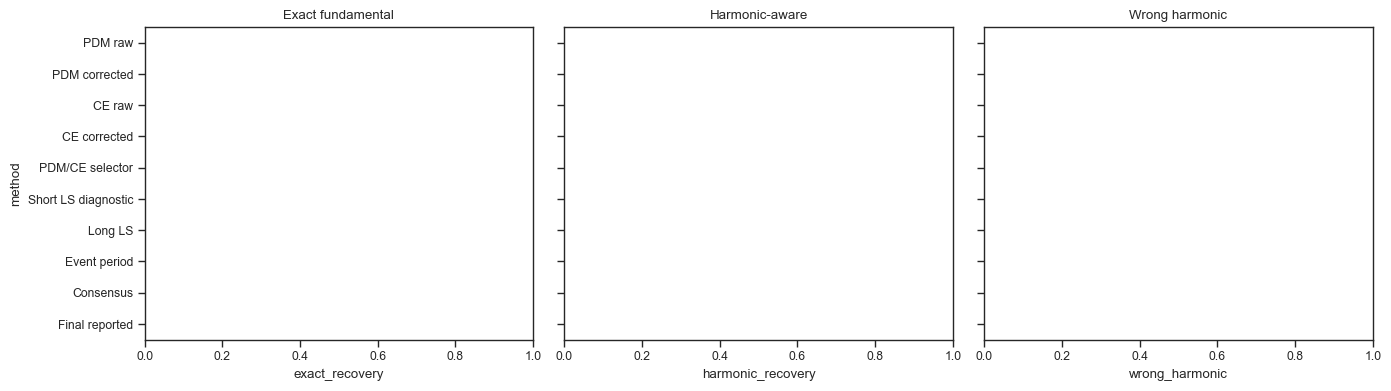

In [26]:
METHOD_LABELS = {
    "pdm_raw": "PDM raw",
    "pdm_corrected": "PDM corrected",
    "ce_raw": "CE raw",
    "ce_corrected": "CE corrected",
    "short_selected": "PDM/CE selector",
    "short_lsp": "Short LS diagnostic",
    "long_ls": "Long LS",
    "event_period": "Event period",
    "consensus": "Consensus",
    "reported": "Final reported",
}


def method_summary(frame: pd.DataFrame, group_cols: list[str] | None = None) -> pd.DataFrame:
    group_cols = list(group_cols or [])
    parts = []
    for key, label in METHOD_LABELS.items():
        exact_col = f"{key}_exact"
        if exact_col not in frame:
            continue
        grouped = frame.groupby(group_cols, dropna=False) if group_cols else [((), frame)]
        for group_key, sub in grouped:
            if not isinstance(group_key, tuple):
                group_key = (group_key,)
            row = dict(zip(group_cols, group_key))
            row.update({
                "method": label,
                "trials": len(sub),
                "period_available": float(pd.to_numeric(sub[f"{key}_period_days"], errors="coerce").notna().mean()),
                "exact_recovery": float(sub[exact_col].astype(bool).mean()),
                "harmonic_recovery": float(sub[f"{key}_harmonic"].astype(bool).mean()),
                "wrong_harmonic": float(sub[f"{key}_wrong_harmonic"].astype(bool).mean()),
            })
            parts.append(row)
    return pd.DataFrame(parts)


overall_methods = method_summary(signal)
display(overall_methods.sort_values("exact_recovery", ascending=False))
if HISTORICAL_RESULTS_AVAILABLE:
    overall_methods.to_csv(RUN_DIR / "method_recovery_overall.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, metric, title in zip(
    axes,
    ["exact_recovery", "harmonic_recovery", "wrong_harmonic"],
    ["Exact fundamental", "Harmonic-aware", "Wrong harmonic"],
):
    sns.barplot(data=overall_methods, x=metric, y="method", ax=ax, color="#4477AA")
    ax.set_title(title)
    ax.set_xlim(0, 1)
fig.tight_layout()
if HISTORICAL_RESULTS_AVAILABLE:
    fig.savefig(RUN_DIR / "method_recovery_overall.png", dpi=180, bbox_inches="tight")
plt.show()

## Recovery surfaces and selection behavior

The key slices are morphology, period regime, signal-to-noise, width, observed
cycle count, and event-information mode. Exact and wrong-harmonic recovery
must be read together.

,morphology,period_regime,amplitude_snr,width_fraction,event_mode,decision_regime,trials,exact_recovery,harmonic_recovery,wrong_harmonic,median_rel_error


,reported_method
morphology,event_mode


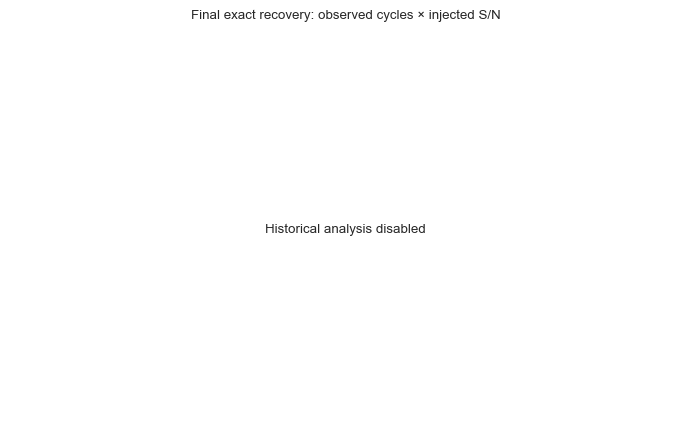

In [27]:
slice_cols = [
    "morphology",
    "period_regime",
    "amplitude_snr",
    "width_fraction",
    "event_mode",
    "decision_regime",
]
slice_summary = (
    signal.groupby(slice_cols, dropna=False)
    .agg(
        trials=("trial_id", "size"),
        exact_recovery=("reported_exact", "mean"),
        harmonic_recovery=("reported_harmonic", "mean"),
        wrong_harmonic=("reported_wrong_harmonic", "mean"),
        median_rel_error=("reported_rel_error", "median"),
    )
    .reset_index()
)
if HISTORICAL_RESULTS_AVAILABLE:
    slice_summary.to_parquet(RUN_DIR / "recovery_slices.parquet", index=False)
display(slice_summary.sort_values(["exact_recovery", "trials"]).head(25))

method_choice = pd.crosstab(
    [signal["morphology"], signal["event_mode"]],
    signal["reported_method"],
    normalize="index",
)
display(method_choice)
if HISTORICAL_RESULTS_AVAILABLE:
    method_choice.to_csv(RUN_DIR / "reported_method_by_morphology_event.csv")

heat = signal.copy()
heat["cycle_bin"] = pd.cut(
    heat["realized_baseline_cycles"],
    bins=[0, 1.75, 2.5, 4, 6.5, 12, np.inf],
    labels=["<1.75", "1.75–2.5", "2.5–4", "4–6.5", "6.5–12", ">12"],
)
pivot = heat.pivot_table(
    index="cycle_bin",
    columns="amplitude_snr",
    values="reported_exact",
    aggfunc="mean",
    observed=False,
)
fig, ax = plt.subplots(figsize=(7, 4.5))
if pivot.empty:
    ax.text(0.5, 0.5, "Historical analysis disabled", ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()
else:
    sns.heatmap(pivot, vmin=0, vmax=1, annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Final exact recovery: observed cycles × injected S/N")
fig.tight_layout()
if HISTORICAL_RESULTS_AVAILABLE:
    fig.savefig(RUN_DIR / "exact_recovery_cycles_snr.png", dpi=180, bbox_inches="tight")
plt.show()

## Paired event-epoch ablation

Rows sharing `base_trial_id` have identical sampling, injected photometry, and
bootstrap regime. Differences therefore isolate the event information given
to the arbitration layer.

In [28]:
paired = signal.loc[
    signal["morphology"].isin(["gaussian_dip", "double_dip", "asymmetric_dip", "quasi_periodic_dip"])
].copy()
event_summary = (
    paired.groupby(["event_mode", "morphology", "decision_regime"], dropna=False)
    .agg(
        trials=("trial_id", "size"),
        exact_recovery=("reported_exact", "mean"),
        wrong_harmonic=("reported_wrong_harmonic", "mean"),
        high_confidence=("consensus_confidence", lambda x: np.mean(pd.Series(x).eq("high"))),
    )
    .reset_index()
)
display(event_summary)
if HISTORICAL_RESULTS_AVAILABLE:
    event_summary.to_csv(RUN_DIR / "event_epoch_ablation.csv", index=False)

paired_wide = paired.pivot_table(
    index="base_trial_id",
    columns="event_mode",
    values="reported_exact",
    aggfunc="first",
)
if {"none", "oracle_complete"}.issubset(paired_wide.columns):
    delta = paired_wide["oracle_complete"].astype(float) - paired_wide["none"].astype(float)
    print("Paired oracle-minus-none exact-recovery change:", delta.mean())
    print("Improved:", int((delta > 0).sum()), "degraded:", int((delta < 0).sum()), "unchanged:", int((delta == 0).sum()))

,event_mode,morphology,decision_regime,trials,exact_recovery,wrong_harmonic,high_confidence


## Alias stress tests

Alias proximity is evaluated separately because an overall recovery number
can hide failures concentrated around the survey window function.

In [29]:
alias_rows = signal.loc[signal["period_regime"].eq("alias_stress")].copy()
if not alias_rows.empty:
    alias_rows["alias_label"] = alias_rows["alias_target_days"].map(lambda x: f"{x:g} d")
    alias_summary = (
        alias_rows.groupby(["alias_label", "morphology", "event_mode"], dropna=False)
        .agg(
            trials=("trial_id", "size"),
            exact_recovery=("reported_exact", "mean"),
            wrong_harmonic=("reported_wrong_harmonic", "mean"),
            short_alias_rate=("short_alias", "mean"),
            lsp_alias_rate=("lsp_is_alias", "mean"),
        )
        .reset_index()
    )
    display(alias_summary)
    alias_summary.to_csv(RUN_DIR / "alias_stress_summary.csv", index=False)
else:
    print("No alias-stress rows in this profile.")

No alias-stress rows in this profile.


## Null false positives and bootstrap calibration

Three quantities are intentionally separate:

- `reported_has_period`: consensus or the diagnostic fallback returned a
  finite period;
- `short_is_significant`: the production-style PDM/CE support, bootstrap, and
  alias decision;
- consensus confidence: whether the newer consensus labels the result high or
  tentative.

The first is not itself a claim of statistical significance.

In [30]:
if not null.empty:
    null_summary = (
        null.groupby(["morphology", "decision_regime"], dropna=False)
        .agg(
            trials=("trial_id", "size"),
            finite_period_rate=("reported_has_period", "mean"),
            short_significant_fpr=("short_is_significant", "mean"),
            lsp_significant_fpr=("lsp_is_significant", "mean"),
            consensus_high_rate=("consensus_confidence", lambda x: np.mean(pd.Series(x).eq("high"))),
            consensus_tentative_rate=("consensus_confidence", lambda x: np.mean(pd.Series(x).eq("tentative"))),
        )
        .reset_index()
    )
    display(null_summary)
    null_summary.to_csv(RUN_DIR / "null_false_positive_summary.csv", index=False)

boot_null = null.loc[null["decision_regime"].eq("production_bootstrap")].copy()
if not boot_null.empty:
    pcols = ["pdm_bootstrap_sig", "ce_bootstrap_sig", "lsp_bootstrap_sig"]
    display(boot_null[pcols].describe())
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    for ax, col in zip(axes, pcols):
        vals = pd.to_numeric(boot_null[col], errors="coerce").dropna()
        ax.hist(vals, bins=np.linspace(0, 1, 21), color="#66CCEE", edgecolor="white")
        ax.axvline(0.01, color="#CC3311", linestyle="--")
        ax.set_title(col)
        ax.set_xlabel("empirical p")
    fig.tight_layout()
    fig.savefig(RUN_DIR / "null_bootstrap_pvalues.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("No bootstrapped nulls in this profile; use PROFILE='paper' or 'production'.")

No bootstrapped nulls in this profile; use PROFILE='paper' or 'production'.


## Confidence reliability and worst failures

Confidence is useful only if higher-confidence periods recover the injected
fundamental more often. The failure table is the starting point for examining
which branch, harmonic factor, or alias caused each mistake.

In [31]:
confidence_summary = (
    signal.groupby(["consensus_confidence", "consensus_method", "decision_regime"], dropna=False)
    .agg(
        trials=("trial_id", "size"),
        exact_recovery=("reported_exact", "mean"),
        harmonic_recovery=("reported_harmonic", "mean"),
        wrong_harmonic=("reported_wrong_harmonic", "mean"),
    )
    .reset_index()
)
display(confidence_summary)
if HISTORICAL_RESULTS_AVAILABLE:
    confidence_summary.to_csv(RUN_DIR / "confidence_reliability.csv", index=False)

failure_columns = [
    "trial_id",
    "morphology",
    "event_mode",
    "decision_regime",
    "true_period_days",
    "realized_baseline_cycles",
    "reported_period_days",
    "reported_method",
    "consensus_confidence",
    "reported_period_ratio",
    "reported_nearest_factor",
    "short_selected_method",
    "pdm_raw_period_days",
    "pdm_corrected_period_days",
    "ce_raw_period_days",
    "ce_corrected_period_days",
    "short_lsp_period_days",
    "long_ls_period_days",
    "event_period_period_days",
    "pdm_bootstrap_sig",
    "ce_bootstrap_sig",
    "lsp_bootstrap_sig",
    "short_alias",
]
failures = signal.loc[~signal["reported_exact"].astype(bool)].copy()
failures = failures.sort_values(["reported_harmonic", "reported_rel_error"], ascending=[False, False])
display(failures[[c for c in failure_columns if c in failures]].head(40))
if HISTORICAL_RESULTS_AVAILABLE:
    failures.to_parquet(RUN_DIR / "failed_signal_trials.parquet", index=False)

,consensus_confidence,consensus_method,decision_regime,trials,exact_recovery,harmonic_recovery,wrong_harmonic


,trial_id,morphology,event_mode,decision_regime,true_period_days,realized_baseline_cycles,reported_period_days,reported_method,consensus_confidence,reported_period_ratio,...,pdm_corrected_period_days,ce_raw_period_days,ce_corrected_period_days,short_lsp_period_days,long_ls_period_days,event_period_period_days,pdm_bootstrap_sig,ce_bootstrap_sig,lsp_bootstrap_sig,short_alias


## Individual failure visualization

Choose a `trial_id` from the table above. The plot regenerates the deterministic
injection and shows both the time series and the fold on the true and reported
periods.

In [32]:
def plot_trial(trial_id: str) -> None:
    row = results.loc[results["trial_id"].eq(trial_id)].iloc[0]
    frame, injected_epochs = simulate_lightcurve(row)
    true_period = float(row["true_period_days"])
    reported_period = float(row["reported_period_days"])
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
    axes[0].errorbar(frame["JD"], frame["mag"], yerr=frame["error"], fmt=".", ms=2, alpha=0.6)
    for epoch in injected_epochs:
        axes[0].axvline(epoch, color="#CC3311", alpha=0.25)
    axes[0].invert_yaxis()
    axes[0].set_title(trial_id)
    axes[0].set_xlabel("JD")
    axes[0].set_ylabel("magnitude")
    for ax, period, label in [
        (axes[1], true_period, f"true P={true_period:.4g} d"),
        (axes[2], reported_period, f"reported P={reported_period:.4g} d"),
    ]:
        phase = ((frame["JD"] - frame["JD"].min()) / period) % 1.0
        ax.scatter(phase, frame["mag"], s=5, alpha=0.5)
        ax.invert_yaxis()
        ax.set_xlabel("phase")
        ax.set_title(label)
    fig.tight_layout()
    plt.show()


if not failures.empty:
    plot_trial(str(failures.iloc[0]["trial_id"]))

## Paper-report checklist

Before quoting a recovery fraction:

1. Use a non-smoke profile and retain the saved design, results, configuration,
   Git commit, and function hashes.
2. State whether the denominator is the broad no-bootstrap tier or the
   production-bootstrap tier.
3. Report exact recovery and wrong-harmonic recovery together.
4. Report null false positives by null family, not only one pooled value.
5. Keep the `none` event arm as the conservative arbitration result; label
   oracle-event results as conditional on correctly detected events.
6. Add real ASAS-SN control light curves as a second sampling/noise domain
   before treating these synthetic results as survey-level completeness.
7. Do not optimize thresholds on this benchmark and then quote the same trials
   as held-out performance. Freeze changes and rerun with new seeds or a
   separate test design.

# Experimental multimethod candidate bank (v2)

> **Separate experimental path.** Everything above is the preserved historical
> production-path discovery analysis. The cells below exercise the new candidate
> bank only; they do not write MALCA production fields or call the STV worker.

The experiment implements the complete proposed architecture:

```text
prepared 4,000-day light curve
  -> global LS + PDM + CE + event comb + BLS + multiharmonic LS
     + Lafler-Kinman + Supersmoother
  -> frequency-aware merging
  -> P/4, P/3, P/2, P, 2P, 3P, 4P expansion
  -> fixed-period LS/PDM/CE/BLS/multiharmonic/Lafler-Kinman/
     held-out-template/odd-even/event scoring
  -> deterministic baseline and learned candidate ranker
  -> secure_fundamental / secure_family_harmonic_ambiguous /
     tentative / abstain
```

Scientific contracts for this section:

- the prepared (not merely requested) span is exactly 4,000 days;
- no periodogram bootstrap or bootstrap significance enters generation,
  scoring, ranking, or acceptance;
- eight process workers are used, with one numerical thread per worker;
- photometric searches run once per base light curve and are reused across
  `none`, `detected`, `noisy_partial`, and `oracle` event views;
- event views always remain paired by `base_trial_id` and are never pooled as
  independent light curves in reported metrics;
- train, validation, and frozen-test base IDs are disjoint; the frozen split
  cannot run until an explicit model-freeze artifact exists; and
- truth labels are stored separately from deployable candidate features.

The default is **design-only smoke mode**. Execution requires an explicit
`MALCA_MM_RUN=1`; the frozen test requires an additional explicit unlock.

In [33]:
from collections.abc import Mapping, Sequence
from dataclasses import is_dataclass
from importlib import metadata as importlib_metadata
import joblib

from malca.core.event_epochs import (
    detect_dip_epochs_lightweight,
    detect_dip_epochs_via_events,
    dip_center_jds,
    parse_run_epochs_json,
    serialize_run_summaries,
)
from malca.evaluation.period_candidate_methods import (
    DEFAULT_GLOBAL_METHODS,
    PeriodCandidateMethodsConfig,
    build_candidate_bank,
    event_epoch_detection_diagnostics,
    merge_search_results,
    refine_scored_candidates,
    run_global_period_searches,
    run_period_candidate_suite,
    select_scoring_shortlist,
    score_candidate_bank,
)
import malca.evaluation.period_candidate_ranker as period_candidate_ranker
import malca.evaluation.period_hierarchical_ranker as period_hierarchical_ranker


def _env_flag(name: str, default: bool = False) -> bool:
    return os.environ.get(name, "1" if default else "0").strip().lower() in {"1", "true", "yes", "on"}


# Discovery run configuration. Restart the kernel and Run All when ready.
MM_PROFILE = "discovery"
MM_RUN_TAG = "multimethod_hierarchical_v3_independent_20260803a"
MM_RUN = True
MM_FIT_RANKER = True
MM_PRIMARY_ARBITRATOR = "hierarchical_v2"
if MM_PRIMARY_ARBITRATOR not in {"hierarchical_v2", "single_stage_v1"}:
    raise ValueError("MM_PRIMARY_ARBITRATOR must be 'hierarchical_v2' or 'single_stage_v1'")
MM_EVALUATE_FROZEN = False
MM_FREEZE_MODEL = False
MM_ALLOW_LARGE_EAGER_LOAD = False
MM_LOAD_HEAVY_DIAGNOSTICS = True
MM_WORKERS = 8
MM_BASELINE_DAYS = 4000.0
MM_SEED = 2026072502

# Narrowly scoped recovery for the interrupted July 25 discovery artifact.
# The original run manifest and checkpoint parts remain immutable. Successful
# attempts are reused; only these deterministically failed bases may be retried.
MM_RECOVERY_PATCH = (
    "baseline_anchor_error_v1"
    if MM_RUN_TAG == "multimethod_discovery_v3_20260725a"
    else None
)
MM_RECOVERY_FROM_FINGERPRINT = (
    "4412186b41bc9fe4781a3db005ce90853f4e73369a9e35a603a35c436676577b"
    if MM_RECOVERY_PATCH
    else None
)
MM_RECOVERY_SUPERSEDES_UNUSED_FINGERPRINT = (
    "86035d1b89bd443362133e97b96ba6078c34b2ba0f876e9d88d9409d59849898"
    if MM_RECOVERY_PATCH
    else None
)
MM_RECOVERY_FAILED_BASE_IDS = (
    "train-signal-000459",
    "train-signal-000640",
    "train-signal-001164",
    "validation-signal-000465",
) if MM_RECOVERY_PATCH else ()
if MM_EVALUATE_FROZEN and (MM_FIT_RANKER or MM_FREEZE_MODEL):
    raise RuntimeError("Frozen-test execution cannot refit or refreeze the model/policy.")
MM_DETECTED_EVENT_BACKEND = "pipeline"
if MM_DETECTED_EVENT_BACKEND not in {"lightweight", "pipeline"}:
    raise ValueError("MALCA_MM_DETECTED_EVENT_BACKEND must be 'lightweight' or 'pipeline'")
assert MM_WORKERS == 8

# Counts are base light curves, before paired event views are materialized.
MM_PROFILES: dict[str, dict[str, tuple[int, int]]] = {
    "targeted": {
        "train": (120, 60),
        "validation": (80, 80),
        "frozen_test": (0, 0),
    },
    "smoke": {
        "train": (12, 6),
        "validation": (8, 8),
        "frozen_test": (8, 8),
    },
    "discovery": {
        "train": (1200, 600),
        "validation": (600, 600),
        "frozen_test": (1000, 1000),
    },
    "full": {
        "train": (1600, 800),
        "validation": (800, 800),
        "frozen_test": (1000, 1000),
    },
    # The original 20k-base design is retained as an explicitly high-memory
    # generation tier, not claimed as an operational single-notebook fit.
    "ultra": {
        "train": (6000, 2000),
        "validation": (2000, 2000),
        "frozen_test": (4000, 4000),
    },
}
if MM_PROFILE not in MM_PROFILES:
    raise ValueError(f"Unknown MALCA_MM_PROFILE={MM_PROFILE!r}; choose from {tuple(MM_PROFILES)}")

# Follow the current production-candidate defaults. AoV proposer views are
# legacy-only; BLS and SuperSmoother participate without feature flags.
MM_GLOBAL_METHODS = DEFAULT_GLOBAL_METHODS
MM_PHOTOMETRIC_METHODS = tuple(name for name in MM_GLOBAL_METHODS if name != "event_comb")
MM_HARMONIC_FACTORS = (0.25, 1 / 3, 0.5, 1.0, 2.0, 3.0, 4.0)
MM_METHOD_CONFIG = PeriodCandidateMethodsConfig(
    enabled_global_methods=MM_GLOBAL_METHODS,
    pdm_method=POST_FILTER_PDM_METHOD,
    max_scored_candidates=128,
    max_refined_candidates=64,
    ls_max_frequency_points=250_000,
    general_min_samples_per_rayleigh=0.0 if MM_PROFILE == "smoke" else 1.0,
    general_max_frequency_points=50_000,
)

MM_ROOT = ROOT / "output" / "evaluation" / "period_arbitration" / "multimethod_candidate_bank" / MM_RUN_TAG
MM_CHECKPOINT_ROOT = MM_ROOT / "checkpoints"
MM_MODELS_ROOT = MM_ROOT / "models"
MM_MANIFEST_PATH = MM_ROOT / "run_manifest.json"
MM_MODEL_FREEZE_PATH = MM_MODELS_ROOT / "frozen_model_manifest.json"
MM_RECOVERY_MANIFEST_PATH = (
    MM_ROOT / "recovery_manifests" / f"{MM_RECOVERY_PATCH}.json"
    if MM_RECOVERY_PATCH
    else None
)

print({
    "profile": MM_PROFILE,
    "run_tag": MM_RUN_TAG,
    "run": MM_RUN,
    "fit_ranker": MM_FIT_RANKER,
    "primary_arbitrator": MM_PRIMARY_ARBITRATOR,
    "evaluate_frozen": MM_EVALUATE_FROZEN,
    "workers": MM_WORKERS,
    "allow_large_eager_load": MM_ALLOW_LARGE_EAGER_LOAD,
    "global_methods": list(MM_GLOBAL_METHODS),
    "load_heavy_diagnostics": MM_LOAD_HEAVY_DIAGNOSTICS,
    "detected_event_backend": MM_DETECTED_EVENT_BACKEND,
    "primary_event_mode": "detected",
    "artifact_root": str(MM_ROOT),
    "recovery_patch": MM_RECOVERY_PATCH,
    "recovery_retry_base_ids": list(MM_RECOVERY_FAILED_BASE_IDS),
})

{'profile': 'discovery', 'run_tag': 'multimethod_discovery_v3_20260725a', 'run': True, 'fit_ranker': True, 'evaluate_frozen': False, 'workers': 8, 'allow_large_eager_load': False, 'experimental_global_proposers': True, 'load_heavy_diagnostics': True, 'detected_event_backend': 'pipeline', 'primary_event_mode': 'detected', 'artifact_root': '/Users/calder/code/malca/output/evaluation/period_arbitration/multimethod_candidate_bank/multimethod_discovery_v3_20260725a', 'recovery_patch': 'baseline_anchor_error_v1', 'recovery_retry_base_ids': ['train-signal-000459', 'train-signal-000640', 'train-signal-001164', 'validation-signal-000465']}


## V2 base design and frozen split

The `targeted` profile is a pre-discovery regression suite concentrated on
long periods, width 0.01/0.03 signals, intermittent/double/trapezoidal
morphologies, and the seasonal/red-noise/isolated/aperiodic hard nulls. It
contains no frozen-test cases and must use its own run tag.

The RAM-bounded full profile contains 3,400 injected periodic bases and 2,600
null bases across train, validation, and frozen test. The original 12,000/8,000
design remains available as `ultra`, explicitly not claimed as an operational
single-notebook fit. Split assignment happens before event views are created, so all views
of one light curve stay in exactly one split. `none` and `detected` are
defined for every base. `noisy_partial` and `oracle` are defined only when
injected dip epochs exist; they are conditional-information ablations, not
additional independent signals.

The frozen-test design is generated now for provenance but is excluded from
search, feature loading, plots, and threshold selection until explicitly
unlocked after model freeze.

In [34]:
MM_SIGNAL_MORPHOLOGIES = (
    "sinusoid",
    "gaussian_dip",
    "double_dip",
    "asymmetric_dip",
    "quasi_periodic_dip",
    "trapezoid_eclipse",
    "spot_multiharmonic",
    "intermittent_dips",
    "variable_depth_dips",
    "phase_drift_dips",
)
MM_DIP_MORPHOLOGIES = frozenset({
    "gaussian_dip", "double_dip", "asymmetric_dip", "quasi_periodic_dip",
    "trapezoid_eclipse", "intermittent_dips", "variable_depth_dips", "phase_drift_dips",
})
MM_NULL_MORPHOLOGIES = (
    "white_noise",
    "red_noise",
    "seasonal_trend",
    "isolated_dip",
    "aperiodic_dips",
    "step_change",
    "outlier_clusters",
    "evolving_trend",
)
MM_NUISANCE_MODES = ("none", "camera_zero_point_step", "seasonal_scatter", "slow_curvature")


def build_mm_base_design(profile: str, seed: int = MM_SEED) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for split, (n_signal, n_null) in MM_PROFILES[profile].items():
        rng = np.random.default_rng(_stable_seed(seed, split, "base-design"))
        for index in range(n_signal):
            base_id = f"{split}-signal-{index:06d}"
            period, regime, alias_target = _period_draw(rng, MM_BASELINE_DAYS)
            morphology = str(rng.choice(MM_SIGNAL_MORPHOLOGIES))
            width_fraction = float(rng.choice((0.01, 0.03, 0.08, 0.18)))
            if profile == "targeted":
                targeted_morphologies = (
                    "intermittent_dips", "double_dip", "trapezoid_eclipse",
                    "quasi_periodic_dip", "gaussian_dip",
                )
                morphology = targeted_morphologies[index % len(targeted_morphologies)]
                width_fraction = (0.01, 0.03)[index % 2]
                if index % 3 == 0:
                    period = float(10 ** rng.uniform(np.log10(300.0), np.log10(2200.0)))
                    regime = "long"
                    alias_target = np.nan
            rows.append({
                "base_trial_id": base_id,
                "split": split,
                "is_signal": True,
                "morphology": morphology,
                "period_regime": regime,
                "alias_target_days": alias_target,
                "true_period_days": period,
                "requested_baseline_days": MM_BASELINE_DAYS,
                "amplitude_snr": float(rng.choice((2.0, 4.0, 8.0, 16.0))),
                "width_fraction": width_fraction,
                "sampling_density": float(rng.choice((0.18, 0.35, 0.60))),
                "median_error": float(rng.choice((0.015, 0.03, 0.06))),
                "phase0": float(rng.uniform(0.0, 1.0)),
                "nuisance_mode": str(rng.choice(MM_NUISANCE_MODES)),
                "signal_seed": _stable_seed(seed, base_id, "signal"),
            })
        for index in range(n_null):
            base_id = f"{split}-null-{index:06d}"
            null_morphology = str(rng.choice(MM_NULL_MORPHOLOGIES))
            if profile == "targeted":
                hard_nulls = (
                    "seasonal_trend", "red_noise", "isolated_dip", "aperiodic_dips",
                    "evolving_trend", "step_change",
                )
                null_morphology = hard_nulls[index % len(hard_nulls)]
            rows.append({
                "base_trial_id": base_id,
                "split": split,
                "is_signal": False,
                "morphology": null_morphology,
                "period_regime": "null",
                "alias_target_days": np.nan,
                "true_period_days": np.nan,
                "requested_baseline_days": MM_BASELINE_DAYS,
                "amplitude_snr": float(rng.choice((2.0, 4.0, 8.0, 16.0))),
                "width_fraction": float(rng.choice((0.01, 0.03, 0.08, 0.18))),
                "sampling_density": float(rng.choice((0.18, 0.35, 0.60))),
                "median_error": float(rng.choice((0.015, 0.03, 0.06))),
                "phase0": float(rng.uniform(0.0, 1.0)),
                "nuisance_mode": str(rng.choice(MM_NUISANCE_MODES)),
                "signal_seed": _stable_seed(seed, base_id, "null"),
            })
    design = pd.DataFrame(rows)
    design["design_version"] = "period-candidate-bank-injection-v3"
    design["n_bootstrap"] = 0
    assert design["base_trial_id"].is_unique
    assert design["requested_baseline_days"].eq(MM_BASELINE_DAYS).all()
    assert design["n_bootstrap"].eq(0).all()
    return design.sort_values(["split", "base_trial_id"]).reset_index(drop=True)


def mm_event_modes_for_base(row: Mapping[str, Any]) -> tuple[str, ...]:
    modes = ["none", "detected"]
    if bool(row["is_signal"]) and str(row["morphology"]) in MM_DIP_MORPHOLOGIES:
        modes.extend(["noisy_partial", "oracle"])
    return tuple(modes)


mm_base_design = build_mm_base_design(MM_PROFILE)
mm_view_design = pd.DataFrame([
    {
        "base_trial_id": row["base_trial_id"],
        "split": row["split"],
        "event_mode": mode,
        "base_view_id": f"{row['base_trial_id']}::{mode}",
    }
    for row in mm_base_design.to_dict(orient="records")
    for mode in mm_event_modes_for_base(row)
])
assert mm_view_design["base_view_id"].is_unique
assert mm_view_design.groupby("base_trial_id")["split"].nunique().eq(1).all()
display(mm_base_design.groupby(["split", "is_signal"]).size().rename("base_light_curves"))
display(mm_view_design.groupby(["split", "event_mode"]).size().rename("paired_views"))
mm_estimated_scored_rows = len(mm_view_design) * (
    int(MM_METHOD_CONFIG.max_scored_candidates or 0)
    + int(MM_METHOD_CONFIG.max_refined_candidates or 0)
)
print(f"Conservative candidate-feature row ceiling: {mm_estimated_scored_rows:,}")
if (
    MM_PROFILE == "ultra"
    and (MM_RUN or MM_FIT_RANKER or MM_EVALUATE_FROZEN)
    and not MM_ALLOW_LARGE_EAGER_LOAD
):
    raise RuntimeError(
        "The ultra profile can materialize many millions of candidate rows and is not a claimed "
        "single-notebook operational tier. Set MALCA_MM_ALLOW_LARGE_EAGER_LOAD=1 only for a reviewed run."
    )

split        is_signal
frozen_test  False        1000
             True         1000
train        False         600
             True         1200
validation   False         600
             True          600
Name: base_light_curves, dtype: int64

split        event_mode   
frozen_test  detected         2000
             noisy_partial     795
             none             2000
             oracle            795
train        detected         1800
             noisy_partial     952
             none             1800
             oracle            952
validation   detected         1200
             noisy_partial     481
             none             1200
             oracle            481
Name: paired_views, dtype: int64

Conservative candidate-feature row ceiling: 1,272,128


## Exact-span preparation and event views

Each base is simulated once, passed through MALCA's periodicity preparation
and V-to-g alignment, and then checked *after preparation*. A span other than
exactly 4,000 days is a failed trial, not a shorter-baseline trial.

`detected` uses the production pipeline GP/events backend by default for
discovery/full/ultra. Smoke alone defaults to a lightweight detector and is
therefore structural, not deployment evidence. The strict benchmark wrapper
re-raises backend failures; a genuine successful no-event result is recorded
separately as `ok_no_events`.
`noisy_partial` drops and jitters injected covered epochs. `oracle` uses all
covered injected epochs. The photometric periodograms do not depend on this
choice and are therefore computed once and reused.

In [35]:
MM_MAX_RECORDED_EPOCHS = 64


def _cap_recorded_epochs(epochs: Sequence[float], maximum: int = MM_MAX_RECORDED_EPOCHS) -> list[float]:
    values = np.asarray(sorted(set(float(value) for value in epochs if np.isfinite(value))), dtype=float)
    if values.size <= maximum:
        return values.tolist()
    indices = np.linspace(0, values.size - 1, maximum, dtype=int)
    return values[np.unique(indices)].tolist()


def _covered_periodic_epochs(
    jd: np.ndarray,
    period: float,
    phase0: float,
    width_days: float,
) -> list[float]:
    """Find covered cycles from observations in O(n_points), never all baseline cycles."""
    anchor = float(jd.min() + phase0 * period)
    cycle = np.rint((jd - anchor) / period).astype(np.int64)
    epoch = anchor + cycle * period
    near = np.abs(jd - epoch) <= 2.0 * max(width_days, 0.08)
    unique, counts = np.unique(cycle[near], return_counts=True)
    covered = anchor + unique[counts >= 2] * period
    return _cap_recorded_epochs(covered)


def simulate_mm_lightcurve(record: Mapping[str, Any]) -> tuple[pd.DataFrame, list[float]]:
    """Extended v2 signal/null families plus orthogonal survey nuisances."""
    record = dict(record)
    legacy_signals = {"sinusoid"}
    legacy_nulls = {"white_noise", "red_noise", "seasonal_trend", "isolated_dip", "aperiodic_dips"}
    morphology = str(record["morphology"])
    if (bool(record["is_signal"]) and morphology in legacy_signals) or (
        not bool(record["is_signal"]) and morphology in legacy_nulls
    ):
        frame, epochs = simulate_lightcurve(record)
    else:
        base_record = {**record, "is_signal": False, "morphology": "white_noise"}
        frame, _ = simulate_lightcurve(base_record)
        rng = np.random.default_rng(_stable_seed(record["signal_seed"], "extended-family"))
        jd = frame["JD"].to_numpy(dtype=float)
        mag = frame["mag"].to_numpy(dtype=float)
        amplitude = float(record["amplitude_snr"]) * float(record["median_error"])
        width_fraction = float(record["width_fraction"])
        phase0 = float(record["phase0"])
        epochs: list[float] = []
        if bool(record["is_signal"]):
            period = float(record["true_period_days"])
            phase = ((jd - jd.min()) / period) % 1.0
            distance = _circular_distance(phase, phase0)
            if morphology == "gaussian_dip":
                mag += amplitude * np.exp(-0.5 * (distance / width_fraction) ** 2)
                epochs = _covered_periodic_epochs(jd, period, phase0, width_fraction * period)
            elif morphology == "double_dip":
                secondary = _circular_distance(phase, (phase0 + 0.5) % 1.0)
                mag += amplitude * np.exp(-0.5 * (distance / width_fraction) ** 2)
                mag += 0.55 * amplitude * np.exp(-0.5 * (secondary / (1.25 * width_fraction)) ** 2)
                epochs = _covered_periodic_epochs(jd, period, phase0, width_fraction * period)
            elif morphology == "asymmetric_dip":
                scale = np.where(distance < 0, max(width_fraction / 2.5, 1e-3), 1.8 * width_fraction)
                mag += amplitude * np.exp(-np.abs(distance) / scale)
                epochs = _covered_periodic_epochs(jd, period, phase0, width_fraction * period)
            elif morphology == "trapezoid_eclipse":
                outer = max(width_fraction, 0.005)
                flat = 0.55 * outer
                profile = np.clip((outer - np.abs(distance)) / max(outer - flat, 1e-4), 0.0, 1.0)
                secondary = _circular_distance(phase, (phase0 + 0.5) % 1.0)
                profile += 0.35 * np.clip((1.2 * outer - np.abs(secondary)) / max(0.5 * outer, 1e-4), 0.0, 1.0)
                mag += amplitude * profile
                epochs = _covered_periodic_epochs(jd, period, phase0, width_fraction * period)
            elif morphology == "spot_multiharmonic":
                angle = 2.0 * np.pi * (phase - phase0)
                mag += amplitude * (0.62 * np.sin(angle) + 0.27 * np.sin(2 * angle + 0.4) + 0.16 * np.cos(3 * angle - 0.7))
            elif morphology in {"quasi_periodic_dip", "intermittent_dips", "variable_depth_dips", "phase_drift_dips"}:
                anchor = float(jd.min() + phase0 * period)
                point_cycle = np.rint((jd - anchor) / period).astype(np.int64)
                cycles, inverse = np.unique(point_cycle, return_inverse=True)
                cycle_rng = np.random.default_rng(_stable_seed(record["signal_seed"], morphology, "cycles"))
                jitter = cycle_rng.normal(0.0, (0.035 if morphology == "quasi_periodic_dip" else 0.012) * period, size=len(cycles))
                if morphology == "phase_drift_dips":
                    centered_cycle = cycles - 0.5 * (cycles.min() + cycles.max())
                    jitter = np.sign(centered_cycle) * np.minimum(0.0015 * centered_cycle**2, 0.12) * period
                active = np.ones(len(cycles), dtype=bool)
                if morphology == "intermittent_dips":
                    active = cycle_rng.random(len(cycles)) < 0.58
                depth = amplitude * cycle_rng.uniform(0.35, 1.55, size=len(cycles))
                if morphology == "quasi_periodic_dip":
                    depth = amplitude * cycle_rng.uniform(0.5, 1.4, size=len(cycles))
                event_epoch_by_cycle = anchor + cycles * period + jitter
                point_epoch = event_epoch_by_cycle[inverse]
                point_depth = depth[inverse] * active[inverse]
                sigma_days = max(width_fraction * period, 0.08)
                mag += point_depth * np.exp(-0.5 * ((jd - point_epoch) / sigma_days) ** 2)
                near = active[inverse] & (np.abs(jd - point_epoch) <= 2.0 * sigma_days)
                covered_cycles, covered_counts = np.unique(point_cycle[near], return_counts=True)
                covered_lookup = {int(cycle): float(event_epoch_by_cycle[index]) for index, cycle in enumerate(cycles)}
                epochs = _cap_recorded_epochs([
                    covered_lookup[int(cycle)] for cycle in covered_cycles[covered_counts >= 2]
                ])
            else:
                raise ValueError(f"Unknown extended signal morphology: {morphology}")
        elif morphology == "step_change":
            change_jd = float(rng.uniform(jd.min() + 0.2 * np.ptp(jd), jd.max() - 0.2 * np.ptp(jd)))
            mag += amplitude * (jd >= change_jd)
        elif morphology == "outlier_clusters":
            for center in rng.uniform(jd.min(), jd.max(), size=int(rng.integers(2, 7))):
                mask = np.abs(jd - center) < float(rng.uniform(0.05, 2.0))
                mag[mask] += amplitude * rng.normal(0.0, 2.0, size=int(mask.sum()))
        elif morphology == "evolving_trend":
            x = (jd - jd.mean()) / max(np.ptp(jd), 1.0)
            mag += amplitude * (2.2 * x**2 + 0.7 * x + np.sin(2 * np.pi * (1.7 * x + 0.8 * x**2)))
        else:
            raise ValueError(f"Unknown extended null morphology: {morphology}")
        frame = frame.copy()
        frame["mag"] = mag

    # Nuisances are crossed with every morphology rather than encoded as truth features.
    nuisance = str(record.get("nuisance_mode", "none"))
    if nuisance != "none":
        frame = frame.copy()
        jd = frame["JD"].to_numpy(dtype=float)
        mag = frame["mag"].to_numpy(dtype=float)
        error_scale = float(record["median_error"])
        rng = np.random.default_rng(_stable_seed(record["signal_seed"], nuisance))
        if nuisance == "camera_zero_point_step":
            camera = frame["camera#"].to_numpy(dtype=int)
            mag += (jd > np.median(jd)) * rng.normal(0.0, 0.8 * error_scale, size=int(camera.max()) + 1)[camera]
        elif nuisance == "seasonal_scatter":
            seasonal_scale = 1.0 + 1.5 * (0.5 + 0.5 * np.sin(2 * np.pi * (jd - jd.min()) / 365.25))
            mag += rng.normal(0.0, error_scale * seasonal_scale)
        elif nuisance == "slow_curvature":
            x = (jd - jd.mean()) / max(np.ptp(jd), 1.0)
            mag += 2.0 * error_scale * (x**2 - np.mean(x**2))
        else:
            raise ValueError(f"Unknown nuisance mode: {nuisance}")
        frame["mag"] = mag
    return frame, [float(epoch) for epoch in epochs]


def detect_dip_epochs_via_events_strict(df_lc: pd.DataFrame) -> list[Any]:
    """Pipeline detector for benchmarks: backend exceptions are implementation failures."""
    from malca.stv.events import score_lightcurve

    results = score_lightcurve(df_lc)
    if not isinstance(results, dict) or not isinstance(results.get("dip"), dict):
        raise RuntimeError("Pipeline detector returned no structured dip result.")
    summaries = results["dip"].get("run_summaries") or []
    return parse_run_epochs_json(serialize_run_summaries(summaries))


def prepare_mm_base(record: Mapping[str, Any], *, detect_events: bool = True) -> dict[str, Any]:
    simulation_record = {
        **dict(record),
        "trial_id": f"{record['base_trial_id']}::simulation",
        "event_mode": "none",
        "trial_seed": _stable_seed(MM_SEED, record["base_trial_id"], "simulation"),
        "n_bootstrap": 0,
    }
    raw_frame, injected_epochs = simulate_mm_lightcurve(simulation_record)
    prepared = prepare_periodicity_lightcurve(raw_frame)
    prepared, v_minus_g = align_v_to_g_magnitude(prepared)
    jd = prepared["JD"].to_numpy(dtype=float)
    mag = prepared["mag"].to_numpy(dtype=float)
    err = prepared["error"].to_numpy(dtype=float)
    if not detect_events:
        detected_runs = []
    elif MM_DETECTED_EVENT_BACKEND == "pipeline":
        detected_runs = detect_dip_epochs_via_events_strict(raw_frame)
    else:
        camera = prepared["camera#"].to_numpy() if "camera#" in prepared else None
        detected_runs = detect_dip_epochs_lightweight(jd, mag, err, cam_vec=camera)
    detected_epochs = dip_center_jds(detected_runs)
    detector_status = (
        "not_run" if not detect_events else ("ok_events" if detected_epochs else "ok_no_events")
    )
    realized_span = float(np.ptp(jd))
    if not np.isclose(realized_span, MM_BASELINE_DAYS, rtol=0.0, atol=1e-9):
        raise AssertionError(
            f"{record['base_trial_id']}: prepared span {realized_span:.12g} != {MM_BASELINE_DAYS:.12g} days"
        )
    return {
        "raw_frame": raw_frame,
        "prepared_frame": prepared,
        "jd": jd,
        "mag": mag,
        "err": err,
        "injected_epochs": [float(value) for value in injected_epochs],
        "detected_epochs": [float(value) for value in detected_epochs],
        "detector_status": detector_status,
        "v_minus_g": float(v_minus_g) if np.isfinite(v_minus_g) else np.nan,
        "realized_span_days": realized_span,
    }


def mm_epochs_for_view(
    record: Mapping[str, Any],
    prepared: Mapping[str, Any],
    event_mode: str,
) -> list[float]:
    if event_mode == "none":
        return []
    if event_mode == "detected":
        return list(prepared["detected_epochs"])
    true_period = float(record["true_period_days"])
    width_fraction = float(record.get("width_fraction", np.nan))
    event_match_tolerance_days = (
        max(0.5, 0.5 * true_period * width_fraction)
        if np.isfinite(true_period) and true_period > 0 and np.isfinite(width_fraction) and width_fraction > 0
        else 0.5
    )
    event_detection_metrics = event_epoch_detection_diagnostics(
        prepared["detected_epochs"],
        prepared["injected_epochs"],
        match_tolerance_days=event_match_tolerance_days,
    )
    injected = list(prepared["injected_epochs"])
    if event_mode == "oracle":
        return injected
    if event_mode == "noisy_partial":
        return event_epochs_for_mode(
            injected,
            "noisy_partial",
            true_period,
            _stable_seed(MM_SEED, record["base_trial_id"], event_mode),
        )
    raise ValueError(f"Unknown event mode: {event_mode}")


mm_example = prepare_mm_base(mm_base_design.iloc[0].to_dict(), detect_events=False)
assert mm_example["realized_span_days"] == MM_BASELINE_DAYS
print({
    "prepared_points": len(mm_example["jd"]),
    "prepared_span_days": mm_example["realized_span_days"],
    "injected_epochs": len(mm_example["injected_epochs"]),
    "detected_epochs": len(mm_example["detected_epochs"]),
})

{'prepared_points': 685, 'prepared_span_days': 4000.0, 'injected_epochs': 0, 'detected_epochs': 0}


## Provenance-safe artifact contract

The v2 root is disjoint from the historical notebook artifacts. Its manifest
fingerprints the complete design, simulator, preparation, method bank,
ranker module, configuration, dependency versions, and harmonic policy.
A mismatched manifest fails before a checkpoint is written; use a new run tag
for any scientific change. Checkpoint parts are atomically renamed.

In [36]:
def _source_sha256(obj: Any) -> str:
    return hashlib.sha256(inspect.getsource(obj).encode("utf-8")).hexdigest()


def _source_file_sha256(obj_or_path: Any) -> str:
    path = Path(obj_or_path) if isinstance(obj_or_path, (str, Path)) else Path(inspect.getsourcefile(obj_or_path))
    return hashlib.sha256(path.read_bytes()).hexdigest()


def _notebook_code_sha256(path: Path) -> str:
    """Hash executable cell sources, excluding outputs and execution counts."""
    notebook = json.loads(Path(path).read_text())
    code_cells = [
        {"cell_index": index, "source": "".join(cell.get("source", []))}
        for index, cell in enumerate(notebook.get("cells", []))
        if cell.get("cell_type") == "code"
    ]
    payload = json.dumps(code_cells, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def _package_version(name: str) -> str:
    try:
        return importlib_metadata.version(name)
    except importlib_metadata.PackageNotFoundError:
        return "not-installed"


def _design_sha256(frame: pd.DataFrame) -> str:
    ordered = frame.sort_values("base_trial_id").reset_index(drop=True)
    hashed = pd.util.hash_pandas_object(ordered, index=False).to_numpy(dtype=np.uint64)
    return hashlib.sha256(hashed.tobytes()).hexdigest()


def _git_commit() -> str:
    try:
        return subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()
    except Exception:
        return "unavailable"


mm_manifest_payload = {
    "schema_version": "period-candidate-bank-artifacts-v3",
    "profile": MM_PROFILE,
    "run_tag": MM_RUN_TAG,
    "seed": MM_SEED,
    "workers": MM_WORKERS,
    "baseline_days": MM_BASELINE_DAYS,
    "n_bootstrap": 0,
    "detected_event_backend": MM_DETECTED_EVENT_BACKEND,
    "primary_event_mode": "detected",
    "max_recorded_event_epochs": MM_MAX_RECORDED_EPOCHS,
    "split_counts": MM_PROFILES[MM_PROFILE],
    "event_modes": ["none", "detected", "noisy_partial", "oracle"],
    "global_methods": MM_GLOBAL_METHODS,
    "harmonic_factors": MM_HARMONIC_FACTORS,
    "method_config": asdict(MM_METHOD_CONFIG) if is_dataclass(MM_METHOD_CONFIG) else repr(MM_METHOD_CONFIG),
    "compatible_recovery_patch": {
        "name": MM_RECOVERY_PATCH,
        "base_manifest_fingerprint": MM_RECOVERY_FROM_FINGERPRINT,
        "supersedes_unused_recovery_fingerprint": MM_RECOVERY_SUPERSEDES_UNUSED_FINGERPRINT,
        "retry_base_ids": list(MM_RECOVERY_FAILED_BASE_IDS),
        "change_scope": "set synthetic baseline-anchor uncertainties to median_error before canonical cleaning",
    } if MM_RECOVERY_PATCH else None,
    "base_design_sha256": _design_sha256(mm_base_design),
    "view_design_sha256": _design_sha256(
        mm_view_design.drop(columns=["base_trial_id"]).rename(columns={"base_view_id": "base_trial_id"})
    ),
    "source_sha256": {
        "simulate_lightcurve": _source_sha256(simulate_lightcurve),
        "simulate_mm_lightcurve": _source_sha256(simulate_mm_lightcurve),
        "prepare_periodicity_lightcurve": _source_sha256(prepare_periodicity_lightcurve),
        "detect_dip_epochs_lightweight": _source_sha256(detect_dip_epochs_lightweight),
        "detect_dip_epochs_via_events": _source_sha256(detect_dip_epochs_via_events),
        "detect_dip_epochs_via_events_strict": _source_sha256(detect_dip_epochs_via_events_strict),
        "run_global_period_searches": _source_sha256(run_global_period_searches),
        "build_candidate_bank": _source_sha256(build_candidate_bank),
        "select_scoring_shortlist": _source_sha256(select_scoring_shortlist),
        "refine_scored_candidates": _source_sha256(refine_scored_candidates),
        "score_candidate_bank": _source_sha256(score_candidate_bank),
        "period_candidate_ranker_module": _source_sha256(period_candidate_ranker),
        "period_hierarchical_ranker_module": _source_sha256(period_hierarchical_ranker),
    },
    "source_file_sha256": {
        "period_candidate_methods.py": _source_file_sha256(run_global_period_searches),
        "period_candidate_ranker.py": _source_file_sha256(period_candidate_ranker),
        "period_hierarchical_ranker.py": _source_file_sha256(period_hierarchical_ranker),
        "event_epochs.py": _source_file_sha256(detect_dip_epochs_via_events),
        "stv_events.py": _source_file_sha256(ROOT / "malca" / "stv" / "events.py"),
        "periodicity_preparation.py": _source_file_sha256(prepare_periodicity_lightcurve),
        "v_to_g_alignment.py": _source_file_sha256(align_v_to_g_magnitude),
        "period_arbitration_injection_recovery.ipynb_code_cells": _notebook_code_sha256(
            ROOT / "malca" / "notebooks" / "evaluation" / "period_arbitration_injection_recovery.ipynb"
        ),
    },
    "dependencies": {
        name: _package_version(name)
        for name in ("numpy", "pandas", "scipy", "astropy", "scikit-learn", "lightgbm", "supersmoother", "gatspy")
    },
    "git_commit": _git_commit(),
}
mm_manifest_fingerprint = hashlib.sha256(
    json.dumps(mm_manifest_payload, sort_keys=True, default=str).encode("utf-8")
).hexdigest()
mm_manifest = {**mm_manifest_payload, "fingerprint": mm_manifest_fingerprint}


def _atomic_write_json(path: Path, payload: Mapping[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name(f".{path.name}.tmp")
    temporary.write_text(json.dumps(dict(payload), indent=2, sort_keys=True, default=str))
    temporary.replace(path)


def _atomic_write_parquet(path: Path, frame: pd.DataFrame) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name(f".{path.stem}.tmp{path.suffix}")
    frame.to_parquet(temporary, index=False)
    temporary.replace(path)


def _normalized_json(value: Any) -> Any:
    return json.loads(json.dumps(value, sort_keys=True, default=str))


def _legacy_commit_ledger() -> list[dict[str, Any]]:
    """Return original commits that predate per-commit source fingerprints."""
    commit_root = MM_CHECKPOINT_ROOT / "commits"
    records = []
    for path in sorted(commit_root.glob("part-*.json")):
        payload = json.loads(path.read_text())
        if "source_manifest_fingerprint" not in payload:
            records.append({"filename": path.name, "payload": payload})
    return records


def _legacy_commit_ledger_sha256() -> str:
    payload = json.dumps(_legacy_commit_ledger(), sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def _commit_references_fingerprint(fingerprint: str | None) -> bool:
    if not fingerprint:
        return False
    commit_root = MM_CHECKPOINT_ROOT / "commits"
    return any(
        json.loads(path.read_text()).get("source_manifest_fingerprint") == fingerprint
        for path in sorted(commit_root.glob("part-*.json"))
    )


def _is_compatible_baseline_anchor_recovery(previous: Mapping[str, Any]) -> bool:
    """Allow exactly the declared simulator fix, with every other input fixed."""
    if not MM_RECOVERY_PATCH or previous.get("fingerprint") != MM_RECOVERY_FROM_FINGERPRINT:
        return False
    previous_payload = {key: value for key, value in dict(previous).items() if key != "fingerprint"}
    current_payload = _normalized_json(mm_manifest_payload)
    current_payload.pop("compatible_recovery_patch", None)

    previous_sources = dict(previous_payload.get("source_sha256", {}))
    current_sources = dict(current_payload.get("source_sha256", {}))
    if current_sources.get("simulate_lightcurve") == previous_sources.get("simulate_lightcurve"):
        return False
    current_sources["simulate_lightcurve"] = previous_sources.get("simulate_lightcurve")
    current_payload["source_sha256"] = current_sources

    previous_files = dict(previous_payload.get("source_file_sha256", {}))
    current_files = dict(current_payload.get("source_file_sha256", {}))
    previous_files.pop("period_arbitration_injection_recovery.ipynb", None)
    current_files.pop("period_arbitration_injection_recovery.ipynb_code_cells", None)
    previous_payload["source_file_sha256"] = previous_files
    current_payload["source_file_sha256"] = current_files
    return _normalized_json(previous_payload) == _normalized_json(current_payload)


def ensure_mm_artifact_root() -> None:
    if MM_MANIFEST_PATH.exists():
        previous = json.loads(MM_MANIFEST_PATH.read_text())
        if previous.get("fingerprint") != mm_manifest_fingerprint:
            if not _is_compatible_baseline_anchor_recovery(previous):
                raise RuntimeError(
                    "Artifact manifest mismatch. Refusing to resume; choose a fresh MALCA_MM_RUN_TAG."
                )
            if MM_RECOVERY_MANIFEST_PATH is None:
                raise RuntimeError("Compatible recovery has no recovery-manifest path.")
            legacy_ledger = _legacy_commit_ledger()
            legacy_part_indices = [int(row["payload"]["part_index"]) for row in legacy_ledger]
            if _commit_references_fingerprint(MM_RECOVERY_SUPERSEDES_UNUSED_FINGERPRINT):
                raise RuntimeError("The superseded recovery fingerprint already has checkpoint commits.")
            recovery_manifest = {
                **mm_manifest,
                "recovery_schema_version": "period-candidate-compatible-recovery-v1",
                "checkpoint_compatibility": {
                    "base_manifest_fingerprint": previous["fingerprint"],
                    "reuse_policy": "reuse complete successful base attempts; retry declared failures only",
                    "retry_base_ids": list(MM_RECOVERY_FAILED_BASE_IDS),
                    "original_manifest_path": str(MM_MANIFEST_PATH),
                    "original_checkpoint_parts_remain_immutable": True,
                    "legacy_commit_count": len(legacy_ledger),
                    "legacy_max_part_index": max(legacy_part_indices) if legacy_part_indices else None,
                    "legacy_commit_ledger_sha256": _legacy_commit_ledger_sha256(),
                    "supersedes_unused_recovery_fingerprint": MM_RECOVERY_SUPERSEDES_UNUSED_FINGERPRINT,
                },
            }
            if MM_RECOVERY_MANIFEST_PATH.exists():
                recorded_recovery = json.loads(MM_RECOVERY_MANIFEST_PATH.read_text())
                if recorded_recovery.get("fingerprint") != mm_manifest_fingerprint:
                    raise RuntimeError("Recovery manifest mismatch; refusing to mix recovery sources.")
                recorded_contract = recorded_recovery.get("checkpoint_compatibility", {})
                if recorded_contract.get("legacy_commit_ledger_sha256") != _legacy_commit_ledger_sha256():
                    raise RuntimeError("Original checkpoint ledger changed after recovery was declared.")
            else:
                _atomic_write_json(MM_RECOVERY_MANIFEST_PATH, recovery_manifest)
    else:
        if MM_RECOVERY_PATCH:
            raise RuntimeError("Recovery requested but the original run manifest is missing.")
        MM_ROOT.mkdir(parents=True, exist_ok=False)
        _atomic_write_json(MM_MANIFEST_PATH, mm_manifest)
    _atomic_write_parquet(MM_ROOT / "base_trials.parquet", mm_base_design)
    _atomic_write_parquet(MM_ROOT / "split_assignments.parquet", mm_view_design)


if MM_RUN or MM_FIT_RANKER or MM_EVALUATE_FROZEN:
    ensure_mm_artifact_root()
print({
    "active_manifest_fingerprint": mm_manifest_fingerprint[:16],
    "base_manifest_fingerprint": MM_RECOVERY_FROM_FINGERPRINT[:16] if MM_RECOVERY_FROM_FINGERPRINT else None,
    "recovery_manifest": str(MM_RECOVERY_MANIFEST_PATH) if MM_RECOVERY_MANIFEST_PATH else None,
})

{'active_manifest_fingerprint': '5b491bf3ca63e10d', 'base_manifest_fingerprint': '4412186b41bc9fe4', 'recovery_manifest': '/Users/calder/code/malca/output/evaluation/period_arbitration/multimethod_candidate_bank/multimethod_discovery_v3_20260725a/recovery_manifests/baseline_anchor_error_v1.json'}


## Candidate-bank evaluator

The evaluator calls `run_global_period_searches` exactly once for all enabled
photometric proposers. For each event arm it runs only `event_comb`, merges
that cheap result with the cached photometric result, builds both unexpanded
and harmonic-expanded banks, and evaluates every expanded candidate with the
shared fixed-period scorer.

Candidate features contain no injected truth. Exact/family labels and injected
periods go to a separate label ledger joined only during evaluation/training.

`bls_coarse` is explicitly an experimental lower-bound proposer, not a resolved
global BLS search: its capped grid is intentionally too coarse for some narrow
signals. Exact-period BLS features and q-aware high-resolution local BLS
refinement remain part of the primary fixed-period scoring path. Search-status
artifacts retain effective grid/cap metadata for interpretation.

In [37]:
def _object_record(value: Any) -> dict[str, Any]:
    if is_dataclass(value):
        return dict(asdict(value))
    if isinstance(value, Mapping):
        return dict(value)
    if hasattr(value, "to_record"):
        return dict(value.to_record())
    if hasattr(value, "__dict__"):
        return dict(vars(value))
    raise TypeError(f"Cannot convert {type(value)!r} to a record")


def _parquet_value(value: Any) -> Any:
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, (list, tuple, set, frozenset, Mapping, np.ndarray)):
        return json.dumps(value, sort_keys=True, default=str)
    return value


def _flatten_score(score: Any) -> dict[str, Any]:
    # CandidateScore.to_record() adds proposer indicators and collapses
    # deterministically related searches into independent support families.
    # A raw dataclass asdict() would silently omit those ranker features.
    payload = (
        dict(score.to_record())
        if hasattr(score, "to_record")
        else _object_record(score)
    )
    features = payload.pop("features", {}) or {}
    flat = {key: _parquet_value(value) for key, value in payload.items()}
    flat.update({str(key): _parquet_value(value) for key, value in dict(features).items()})
    return flat


def _candidate_id(base_view_id: str, stage: str, period_days: float) -> str:
    token = f"{base_view_id}|{stage}|{float(period_days):.16g}".encode("utf-8")
    return hashlib.sha256(token).hexdigest()[:24]


def _candidate_truth(period_days: float, true_period_days: float) -> dict[str, Any]:
    valid = np.isfinite(period_days) and period_days > 0 and np.isfinite(true_period_days) and true_period_days > 0
    if not valid:
        return {
            "is_exact": False,
            "is_harmonic_family": False,
            "is_wrong_harmonic": False,
            "is_exact_relative": False,
            "is_harmonic_family_relative": False,
            "is_wrong_harmonic_relative": False,
            "is_exact_resolution_consistent": False,
            "is_harmonic_family_resolution_consistent": False,
            "nearest_harmonic_factor": np.nan,
            "relative_period_error": np.nan,
            "rayleigh_frequency_error": np.nan,
        }
    relative_errors = {
        factor: abs(period_days - true_period_days * factor) / (true_period_days * factor)
        for factor in MM_HARMONIC_FACTORS
    }
    rayleigh_errors = {
        factor: abs(1.0 / period_days - 1.0 / (true_period_days * factor)) * MM_BASELINE_DAYS
        for factor in MM_HARMONIC_FACTORS
    }
    nearest_factor = min(rayleigh_errors, key=rayleigh_errors.get)
    exact_rayleigh = rayleigh_errors[1.0] <= 1.0
    family_rayleigh = rayleigh_errors[nearest_factor] <= 1.0
    exact_relative = relative_errors[1.0] <= 0.05
    relative_factor = min(relative_errors, key=relative_errors.get)
    family_relative = relative_errors[relative_factor] <= 0.05
    return {
        "is_exact": bool(exact_rayleigh and exact_relative),
        "is_harmonic_family": bool(family_rayleigh and relative_errors[nearest_factor] <= 0.05),
        "is_wrong_harmonic": bool(
            family_rayleigh and relative_errors[nearest_factor] <= 0.05
            and not (exact_rayleigh and exact_relative)
        ),
        "is_exact_relative": bool(exact_relative),
        "is_harmonic_family_relative": bool(family_relative),
        "is_wrong_harmonic_relative": bool(family_relative and not exact_relative),
        "is_exact_resolution_consistent": bool(exact_rayleigh),
        "is_harmonic_family_resolution_consistent": bool(family_rayleigh),
        "nearest_harmonic_factor": float(nearest_factor),
        "relative_period_error": float(relative_errors[1.0]),
        "rayleigh_frequency_error": float(rayleigh_errors[1.0]),
    }


def _search_candidate_records(
    search_results: Mapping[str, Any],
    *,
    base_trial_id: str,
    split: str,
    event_mode: str,
) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for method, result in search_results.items():
        candidates = getattr(result, "candidates", ()) or ()
        for proposal_index, candidate in enumerate(candidates):
            record = _object_record(candidate)
            rows.append({
                "base_trial_id": base_trial_id,
                "base_view_id": f"{base_trial_id}::{event_mode}",
                "split": split,
                "event_mode": event_mode,
                "method": method,
                "proposal_index": proposal_index,
                **{key: _parquet_value(value) for key, value in record.items()},
            })
    return rows


def _search_status_records(
    search_results: Mapping[str, Any],
    *,
    base_trial_id: str,
    split: str,
    event_mode: str,
) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    for method, result in search_results.items():
        row = {
            "base_trial_id": base_trial_id,
            "base_view_id": f"{base_trial_id}::{event_mode}",
            "split": split,
            "event_mode": event_mode,
            "method": method,
            "status": str(getattr(result, "status", "unknown")),
            "message": str(getattr(result, "message", "")),
            "candidate_count": len(getattr(result, "candidates", ()) or ()),
        }
        metadata = getattr(result, "metadata", {}) or {}
        if is_dataclass(metadata):
            metadata = asdict(metadata)
        if isinstance(metadata, Mapping):
            for key, value in metadata.items():
                if value is None or isinstance(value, (str, bool, int, float, np.generic)):
                    row[f"meta_{key}"] = _parquet_value(value)
        rows.append(row)
    return rows


def evaluate_mm_base(record: Mapping[str, Any]) -> dict[str, list[dict[str, Any]]]:
    record = dict(record)
    started = time.perf_counter()
    prepared = prepare_mm_base(record)
    jd, mag, err = prepared["jd"], prepared["mag"], prepared["err"]
    base_id = str(record["base_trial_id"])
    split = str(record["split"])
    true_period = float(record["true_period_days"])

    # This is the only call that computes photometric periodograms for the base.
    photometric_searches = run_global_period_searches(
        jd,
        mag,
        err,
        event_epochs=None,
        config=MM_METHOD_CONFIG,
        methods=MM_PHOTOMETRIC_METHODS,
    )

    outputs: dict[str, list[dict[str, Any]]] = {
        "base_summaries": [],
        "search_status": [],
        "raw_method_candidates": [],
        "candidate_bank": [],
        "candidate_features": [],
        "candidate_labels": [],
    }
    for event_mode in mm_event_modes_for_base(record):
        base_view_id = f"{base_id}::{event_mode}"
        event_epochs = mm_epochs_for_view(record, prepared, event_mode)
        event_search = run_global_period_searches(
            jd,
            mag,
            err,
            event_epochs=event_epochs,
            config=MM_METHOD_CONFIG,
            methods=("event_comb",),
        )
        searches = merge_search_results(photometric_searches, event_search)
        outputs["raw_method_candidates"].extend(_search_candidate_records(
            searches,
            base_trial_id=base_id,
            split=split,
            event_mode=event_mode,
        ))
        outputs["search_status"].extend(_search_status_records(
            searches,
            base_trial_id=base_id,
            split=split,
            event_mode=event_mode,
        ))

        merged = build_candidate_bank(
            searches,
            baseline_days=prepared["realized_span_days"],
            config=MM_METHOD_CONFIG,
            expand_harmonics=False,
        )
        expanded = build_candidate_bank(
            searches,
            baseline_days=prepared["realized_span_days"],
            config=MM_METHOD_CONFIG,
            expand_harmonics=True,
        )
        scoring_shortlist = select_scoring_shortlist(expanded, config=MM_METHOD_CONFIG)
        scored = score_candidate_bank(
            jd,
            mag,
            scoring_shortlist,
            err,
            event_epochs=event_epochs,
            config=MM_METHOD_CONFIG,
        )
        refined_candidates = refine_scored_candidates(
            scoring_shortlist,
            scored,
            baseline_days=prepared["realized_span_days"],
            time=jd,
            mag=mag,
            err=err,
            config=MM_METHOD_CONFIG,
            include_original=False,
        )
        refined_scores = score_candidate_bank(
            jd,
            mag,
            refined_candidates,
            err,
            event_epochs=event_epochs,
            config=MM_METHOD_CONFIG,
        )

        for stage, candidates in (("merged", merged), ("expanded", expanded), ("refined", refined_candidates)):
            for bank_rank, candidate in enumerate(candidates, start=1):
                candidate_record = _object_record(candidate)
                period_days = float(candidate_record["period_days"])
                candidate_id = _candidate_id(base_view_id, stage, period_days)
                outputs["candidate_bank"].append({
                    "candidate_id": candidate_id,
                    "base_trial_id": base_id,
                    "base_view_id": base_view_id,
                    "split": split,
                    "event_mode": event_mode,
                    "candidate_stage": stage,
                    "bank_rank": bank_rank,
                    **{key: _parquet_value(value) for key, value in candidate_record.items()},
                })
                labels = _candidate_truth(period_days, true_period)
                outputs["candidate_labels"].append({
                    "candidate_id": candidate_id,
                    "base_trial_id": base_id,
                    "base_view_id": base_view_id,
                    "split": split,
                    "event_mode": event_mode,
                    "candidate_stage": stage,
                    "true_period_days": true_period,
                    "is_signal": bool(record["is_signal"]),
                    **labels,
                })

        for score_stage, score_rows in (("expanded", scored), ("refined", refined_scores)):
            for bank_rank, score in enumerate(score_rows, start=1):
                score_record = _flatten_score(score)
                period_days = float(score_record["period_days"])
                candidate_id = _candidate_id(base_view_id, score_stage, period_days)
                outputs["candidate_features"].append({
                    "candidate_id": candidate_id,
                    "base_trial_id": base_id,
                    "base_view_id": base_view_id,
                    "split": split,
                    "event_mode": event_mode,
                    "candidate_stage": score_stage,
                    "bank_rank": bank_rank,
                    "period_days": period_days,
                    **{key: _parquet_value(value) for key, value in score_record.items()},
                })

        expanded_labels = [
            row for row in outputs["candidate_labels"]
            if row["base_view_id"] == base_view_id and row["candidate_stage"] == "expanded"
        ]
        scored_candidate_ids = {
            _candidate_id(base_view_id, "expanded", float(_object_record(candidate)["period_days"]))
            for candidate in scoring_shortlist
        }
        scored_labels = [row for row in expanded_labels if row["candidate_id"] in scored_candidate_ids]
        refined_labels = [
            row for row in outputs["candidate_labels"]
            if row["base_view_id"] == base_view_id and row["candidate_stage"] == "refined"
        ]
        outputs["base_summaries"].append({
            "base_trial_id": base_id,
            "base_view_id": base_view_id,
            "split": split,
            "event_mode": event_mode,
            "detected_event_backend": MM_DETECTED_EVENT_BACKEND,
            "is_signal": bool(record["is_signal"]),
            "morphology": record["morphology"],
            "period_regime": record["period_regime"],
            "nuisance_mode": record["nuisance_mode"],
            "true_period_days": true_period,
            "alias_target_days": record["alias_target_days"],
            "amplitude_snr": record["amplitude_snr"],
            "width_fraction": record["width_fraction"],
            "sampling_density": record["sampling_density"],
            "median_error": record["median_error"],
            "status": "ok",
            "error": None,
            "n_points": len(jd),
            "realized_baseline_days": prepared["realized_span_days"],
            "realized_baseline_cycles": (
                prepared["realized_span_days"] / true_period
                if np.isfinite(true_period) and true_period > 0
                else np.nan
            ),
            "injected_event_count": len(prepared["injected_epochs"]),
            "detected_event_count": len(prepared["detected_epochs"]),
            "detector_status": prepared["detector_status"],
            **event_detection_metrics,
            "event_epochs_used": len(event_epochs),
            "merged_candidate_count": len(merged),
            "expanded_candidate_count": len(expanded),
            "scored_candidate_count": len(scoring_shortlist),
            "refined_candidate_count": len(refined_candidates),
            "expanded_exact_oracle": any(row["is_exact"] for row in expanded_labels),
            "expanded_family_oracle": any(row["is_harmonic_family"] for row in expanded_labels),
            "scored_exact_oracle": any(row["is_exact"] for row in scored_labels),
            "scored_family_oracle": any(row["is_harmonic_family"] for row in scored_labels),
            "post_refinement_exact_oracle": any(row["is_exact"] for row in scored_labels + refined_labels),
            "post_refinement_family_oracle": any(row["is_harmonic_family"] for row in scored_labels + refined_labels),
            "runtime_seconds": time.perf_counter() - started,
        })
    return outputs


def evaluate_mm_base_safe(record: Mapping[str, Any]) -> dict[str, list[dict[str, Any]]]:
    try:
        return evaluate_mm_base(record)
    except Exception as exc:
        return {
            "base_summaries": [{
                "base_trial_id": record["base_trial_id"],
                "base_view_id": f"{record['base_trial_id']}::error",
                "split": record["split"],
                "event_mode": "error",
                "detected_event_backend": MM_DETECTED_EVENT_BACKEND,
                "is_signal": bool(record["is_signal"]),
                "morphology": record["morphology"],
                "period_regime": record["period_regime"],
                "nuisance_mode": record["nuisance_mode"],
                "true_period_days": record["true_period_days"],
                "alias_target_days": record["alias_target_days"],
                "amplitude_snr": record["amplitude_snr"],
                "width_fraction": record["width_fraction"],
                "sampling_density": record["sampling_density"],
                "median_error": record["median_error"],
                "status": "error",
                "error": repr(exc),
            }],
            "search_status": [],
            "raw_method_candidates": [],
            "candidate_bank": [],
            "candidate_features": [],
            "candidate_labels": [],
        }

## Execute or resume with eight workers

Checkpoint parts are written by the parent process after each parallel batch.
A base is complete only when it appears in a summary part. By default only
train and validation are eligible. Setting `MALCA_MM_EVALUATE_FROZEN=1`
requires `models/frozen_model_manifest.json` to exist first.

Consolidated artifacts retain four distinct ledgers: raw proposals, the
merged/expanded candidate bank, deployable fixed-period features, and truth
labels. This prevents accidental injection-truth leakage into the ranker.

In [38]:
MM_TABLES = (
    "search_status",
    "raw_method_candidates",
    "candidate_bank",
    "candidate_features",
    "candidate_labels",
    # Commit sentinel: write this only after every detail table in the batch.
    "base_summaries",
)
MM_COMMIT_ROOT = MM_CHECKPOINT_ROOT / "commits"


def _part_paths(table_name: str) -> list[Path]:
    return sorted((MM_CHECKPOINT_ROOT / table_name).glob("part-*.parquet"))


def _commit_paths() -> list[Path]:
    return sorted(MM_COMMIT_ROOT.glob("part-*.json"))


def _read_commit_index() -> pd.DataFrame:
    if MM_RECOVERY_PATCH:
        if MM_RECOVERY_MANIFEST_PATH is None or not MM_RECOVERY_MANIFEST_PATH.exists():
            raise RuntimeError("Recovery manifest is missing before checkpoint selection.")
        recovery_manifest = json.loads(MM_RECOVERY_MANIFEST_PATH.read_text())
        recovery_contract = recovery_manifest.get("checkpoint_compatibility", {})
        if recovery_manifest.get("fingerprint") != mm_manifest_fingerprint:
            raise RuntimeError("Active recovery fingerprint does not match the recorded recovery manifest.")
        if recovery_contract.get("legacy_commit_ledger_sha256") != _legacy_commit_ledger_sha256():
            raise RuntimeError("Original checkpoint ledger no longer matches the pinned recovery ledger.")
    rows = []
    for path in _commit_paths():
        payload = json.loads(path.read_text())
        filename_part = int(path.stem.split("-")[-1])
        if int(payload.get("part_index", -1)) != filename_part:
            raise RuntimeError(f"Checkpoint commit index disagrees with filename: {path}")
        source_was_explicit = "source_manifest_fingerprint" in payload
        if MM_RECOVERY_PATCH and not source_was_explicit:
            payload["source_manifest_fingerprint"] = MM_RECOVERY_FROM_FINGERPRINT
            payload["recovery_patch"] = ""
        else:
            payload.setdefault("source_manifest_fingerprint", mm_manifest_fingerprint)
            payload.setdefault("recovery_patch", "")
        if MM_RECOVERY_PATCH and source_was_explicit:
            if payload["source_manifest_fingerprint"] != mm_manifest_fingerprint:
                raise RuntimeError(f"Foreign checkpoint source fingerprint in {path}")
            if payload.get("recovery_patch") != MM_RECOVERY_PATCH:
                raise RuntimeError(f"Checkpoint recovery-patch mismatch in {path}")
            summary_path = MM_CHECKPOINT_ROOT / "base_summaries" / f"part-{filename_part:06d}.parquet"
            if int(payload.get("table_counts", {}).get("base_summaries", 0)) <= 0 or not summary_path.exists():
                raise RuntimeError(f"Recovery commit has no base-summary sentinel: {path}")
            summary = pd.read_parquet(summary_path, columns=["base_trial_id", "attempt_id", "part_index"])
            summary = summary.loc[
                summary["attempt_id"].astype(str).eq(str(payload["attempt_id"]))
                & summary["part_index"].eq(filename_part)
            ]
            if len(summary) != int(payload["table_counts"]["base_summaries"]):
                raise RuntimeError(f"Recovery base-summary row-count mismatch for {summary_path}")
            recovery_base_ids = set(summary["base_trial_id"].astype(str))
            if not recovery_base_ids or not recovery_base_ids.issubset(set(MM_RECOVERY_FAILED_BASE_IDS)):
                raise RuntimeError(f"Recovery commit exceeds the declared retry scope: {path}")
        rows.append(payload)
    commits = pd.DataFrame(rows)
    if not commits.empty and commits["part_index"].duplicated().any():
        raise RuntimeError("Duplicate checkpoint part indices in commit ledger.")
    return commits


def _read_committed_parts(table_name: str, *, columns: Sequence[str] | None = None) -> pd.DataFrame:
    """Ignore orphan files and rows whose attempt ID is not in the atomic commit ledger."""
    commits = _read_commit_index()
    if commits.empty:
        return pd.DataFrame()
    parts = []
    for row in commits.sort_values("part_index").itertuples(index=False):
        if int(row.table_counts.get(table_name, 0)) == 0:
            continue
        path = MM_CHECKPOINT_ROOT / table_name / f"part-{int(row.part_index):06d}.parquet"
        if not path.exists():
            raise RuntimeError(f"Committed checkpoint table is missing: {path}")
        requested = None if columns is None else list(dict.fromkeys([*columns, "attempt_id", "part_index"]))
        frame = pd.read_parquet(path, columns=requested)
        frame = frame.loc[frame["attempt_id"].astype(str).eq(str(row.attempt_id))]
        if len(frame) != int(row.table_counts[table_name]):
            raise RuntimeError(f"Checkpoint row-count mismatch for {path}")
        frame["source_manifest_fingerprint"] = str(row.source_manifest_fingerprint)
        frame["recovery_patch"] = "" if pd.isna(row.recovery_patch) else str(row.recovery_patch)
        parts.append(frame)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


def _write_mm_batch(batch_outputs: Sequence[Mapping[str, Sequence[Mapping[str, Any]]]], part_index: int) -> None:
    attempt_id = hashlib.sha256(
        f"{mm_manifest_fingerprint}|{part_index}|{time.time_ns()}".encode("utf-8")
    ).hexdigest()[:24]
    table_counts: dict[str, int] = {}
    for table_name in MM_TABLES:
        rows = [row for output in batch_outputs for row in output.get(table_name, ())]
        table_counts[table_name] = len(rows)
        if rows:
            frame = pd.DataFrame(rows)
            frame["attempt_id"] = attempt_id
            frame["part_index"] = int(part_index)
            frame["source_manifest_fingerprint"] = mm_manifest_fingerprint
            frame["recovery_patch"] = MM_RECOVERY_PATCH or ""
            _atomic_write_parquet(
                MM_CHECKPOINT_ROOT / table_name / f"part-{part_index:06d}.parquet",
                frame,
            )
    # This JSON is the sole commit point and is written only after all table parts.
    _atomic_write_json(MM_COMMIT_ROOT / f"part-{part_index:06d}.json", {
        "schema_version": "period-candidate-batch-commit-v1",
        "part_index": int(part_index),
        "attempt_id": attempt_id,
        "source_manifest_fingerprint": mm_manifest_fingerprint,
        "base_manifest_fingerprint": MM_RECOVERY_FROM_FINGERPRINT or mm_manifest_fingerprint,
        "recovery_patch": MM_RECOVERY_PATCH or "",
        "table_counts": table_counts,
        "committed_unix_time": time.time(),
    })


def _selected_success_attempts(
    summaries: pd.DataFrame,
    eligible_splits: set[str],
) -> pd.DataFrame:
    if summaries.empty:
        return pd.DataFrame(columns=["base_trial_id", "attempt_id", "part_index"])
    expected = (
        mm_view_design.loc[mm_view_design["split"].isin(eligible_splits)]
        .groupby("base_trial_id")["base_view_id"]
        .nunique()
        .rename("expected_views")
    )
    attempts = (
        summaries.groupby(["base_trial_id", "attempt_id", "part_index"], dropna=False)
        .agg(
            rows=("base_view_id", "size"),
            unique_views=("base_view_id", "nunique"),
            ok_rows=("status", lambda values: int(values.eq("ok").sum())),
        )
        .reset_index()
        .merge(expected, on="base_trial_id", how="left", validate="many_to_one")
    )
    complete = attempts.loc[
        attempts["expected_views"].notna()
        & attempts["rows"].eq(attempts["expected_views"])
        & attempts["unique_views"].eq(attempts["expected_views"])
        & attempts["ok_rows"].eq(attempts["expected_views"])
    ]
    return (
        complete.sort_values(["base_trial_id", "part_index"], kind="stable")
        .groupby("base_trial_id", as_index=False)
        .tail(1)[["base_trial_id", "attempt_id", "part_index"]]
        .reset_index(drop=True)
    )


if MM_EVALUATE_FROZEN:
    if not MM_MODEL_FREEZE_PATH.exists():
        raise RuntimeError(
            "Frozen-test unlock requested before model freeze. Fit/finalize on train+validation first."
        )
    frozen_contract = json.loads(MM_MODEL_FREEZE_PATH.read_text())
    if frozen_contract.get("frozen_test_was_opened", False):
        raise RuntimeError("This frozen test was already opened; create a new run tag for another test.")
    if frozen_contract.get("run_manifest_fingerprint") != mm_manifest_fingerprint:
        raise RuntimeError("Frozen model/run manifest fingerprint mismatch.")
    frozen_ranker_path = MM_MODELS_ROOT / "candidate_ranker.joblib"
    frozen_policy_path = MM_MODELS_ROOT / "validation_threshold_policy.json"
    if not frozen_ranker_path.exists() or not frozen_policy_path.exists():
        raise RuntimeError("Frozen model or validation threshold policy is missing.")
    frozen_artifact = period_candidate_ranker.load_candidate_ranker_artifact(frozen_ranker_path)
    if frozen_artifact.metadata.get("artifact_fingerprint") != frozen_contract.get("ranker_artifact_fingerprint"):
        raise RuntimeError("Frozen ranker artifact fingerprint mismatch.")
    frozen_policy = json.loads(frozen_policy_path.read_text())
    if frozen_policy.get("metadata", {}).get("threshold_policy_fingerprint") != frozen_contract.get("threshold_policy_fingerprint"):
        raise RuntimeError("Frozen threshold-policy fingerprint mismatch.")
    frozen_hierarchical_path = MM_MODELS_ROOT / "hierarchical_period_arbitrator.joblib"
    frozen_hierarchical_policy_path = MM_MODELS_ROOT / "hierarchical_validation_threshold_policy.json"
    if not frozen_hierarchical_path.exists() or not frozen_hierarchical_policy_path.exists():
        raise RuntimeError("Frozen hierarchical arbitrator or policy is missing.")
    frozen_hierarchical_artifact = period_hierarchical_ranker.load_hierarchical_period_arbitrator(
        frozen_hierarchical_path
    )
    if frozen_hierarchical_artifact.metadata.get("artifact_fingerprint") != frozen_contract.get("hierarchical_artifact_fingerprint"):
        raise RuntimeError("Frozen hierarchical artifact fingerprint mismatch.")
    frozen_hierarchical_policy = json.loads(frozen_hierarchical_policy_path.read_text())
    if frozen_hierarchical_policy.get("metadata", {}).get("threshold_policy_fingerprint") != frozen_contract.get("hierarchical_threshold_policy_fingerprint"):
        raise RuntimeError("Frozen hierarchical threshold-policy fingerprint mismatch.")
    # Consume the one-shot frozen-test token before loading or generating any
    # frozen rows. A failed run remains opened and requires a fresh run tag.
    frozen_contract["frozen_test_was_opened"] = True
    frozen_contract["opened_unix_time"] = time.time()
    _atomic_write_json(MM_MODEL_FREEZE_PATH, frozen_contract)

eligible_splits = {"train", "validation"}
if MM_EVALUATE_FROZEN:
    eligible_splits.add("frozen_test")
eligible_design = mm_base_design.loc[mm_base_design["split"].isin(eligible_splits)].copy()

existing_summary = _read_committed_parts("base_summaries") if MM_ROOT.exists() else pd.DataFrame()
selected_existing_attempts = _selected_success_attempts(existing_summary, eligible_splits)
completed_base_ids = set(selected_existing_attempts.get("base_trial_id", pd.Series(dtype=str)).astype(str))
pending_design = eligible_design.loc[~eligible_design["base_trial_id"].astype(str).isin(completed_base_ids)]
pending_base_ids = set(pending_design["base_trial_id"].astype(str))
if MM_RECOVERY_PATCH:
    declared_retry_ids = set(MM_RECOVERY_FAILED_BASE_IDS)
    recovery_scope_ids = set(
        mm_base_design.loc[
            mm_base_design["split"].isin({"train", "validation"}),
            "base_trial_id",
        ].astype(str)
    )
    unexpected_pending = (pending_base_ids & recovery_scope_ids) - declared_retry_ids
    missing_preexisting_successes = (recovery_scope_ids - declared_retry_ids) - completed_base_ids
    if unexpected_pending or missing_preexisting_successes:
        raise RuntimeError(
            "Recovery checkpoint state does not match the declared four-base retry scope: "
            f"unexpected_pending={sorted(unexpected_pending)}, "
            f"missing_preexisting_successes={sorted(missing_preexisting_successes)}"
        )
    print({
        "recovery_patch": MM_RECOVERY_PATCH,
        "declared_retry_bases": len(declared_retry_ids),
        "currently_pending_declared_bases": sorted(pending_base_ids & declared_retry_ids),
        "reused_successful_bases": len(completed_base_ids & recovery_scope_ids),
    })
print({
    "eligible_bases": len(eligible_design),
    "completed_bases": len(completed_base_ids & set(eligible_design["base_trial_id"])),
    "pending_bases": len(pending_design),
    "eligible_splits": sorted(eligible_splits),
})

if MM_RUN and not pending_design.empty:
    records = pending_design.to_dict(orient="records")
    batch_size = max(MM_WORKERS, 8 if MM_PROFILE == "smoke" else 64)
    existing_commits = _read_commit_index()
    next_part = 0 if existing_commits.empty else int(existing_commits["part_index"].max()) + 1
    progress = tqdm(total=len(records), desc=f"multimethod candidate bank [{MM_PROFILE}; 8 CPUs]")
    for start in range(0, len(records), batch_size):
        batch = records[start : start + batch_size]
        outputs = Parallel(
            n_jobs=MM_WORKERS,
            backend="loky",
            batch_size=1,
            pre_dispatch="2*n_jobs",
        )(delayed(evaluate_mm_base_safe)(record) for record in batch)
        _write_mm_batch(outputs, next_part)
        next_part += 1
        progress.update(len(batch))
    progress.close()

all_committed_summaries = _read_committed_parts("base_summaries") if MM_ROOT.exists() else pd.DataFrame()
selected_attempts = _selected_success_attempts(all_committed_summaries, eligible_splits)
eligible_base_ids = set(eligible_design["base_trial_id"].astype(str))
successful_base_ids = set(selected_attempts["base_trial_id"].astype(str))
unresolved_base_ids = eligible_base_ids - successful_base_ids
selected_summary = (
    all_committed_summaries.merge(
        selected_attempts,
        on=["base_trial_id", "attempt_id", "part_index"],
        how="inner",
        validate="many_to_one",
    )
    if not selected_attempts.empty else pd.DataFrame()
)
if MM_RECOVERY_PATCH and not selected_summary.empty:
    recovery_selected = selected_summary.loc[
        selected_summary["source_manifest_fingerprint"].astype(str).eq(mm_manifest_fingerprint)
    ]
    recovery_selected_ids = set(recovery_selected["base_trial_id"].astype(str))
    if not recovery_selected_ids.issubset(set(MM_RECOVERY_FAILED_BASE_IDS)):
        raise RuntimeError("Selected recovery attempts exceed the declared four-base scope.")
    remaining_declared = set(MM_RECOVERY_FAILED_BASE_IDS) - successful_base_ids
    if not remaining_declared:
        expected_recovery_views = set(
            mm_view_design.loc[
                mm_view_design["base_trial_id"].astype(str).isin(MM_RECOVERY_FAILED_BASE_IDS),
                "base_view_id",
            ].astype(str)
        )
        if len(expected_recovery_views) != 10:
            raise RuntimeError("The declared four-base recovery design no longer has exactly ten views.")
        if recovery_selected_ids != set(MM_RECOVERY_FAILED_BASE_IDS):
            raise RuntimeError("Completed recovery does not select all four declared bases.")
        if set(recovery_selected["base_view_id"].astype(str)) != expected_recovery_views:
            raise RuntimeError("Completed recovery does not contain exactly the ten declared views.")
        if not recovery_selected["status"].eq("ok").all():
            raise RuntimeError("Completed recovery contains a non-ok selected view.")
        if not recovery_selected["realized_baseline_days"].eq(MM_BASELINE_DAYS).all():
            raise RuntimeError("Completed recovery contains a non-4000-day selected view.")
        print({
            "recovery_selected_bases": len(recovery_selected_ids),
            "recovery_selected_views": len(recovery_selected),
            "recovery_selected_source": mm_manifest_fingerprint[:16],
        })
latest_unresolved = pd.DataFrame()
if unresolved_base_ids and not all_committed_summaries.empty:
    unresolved_attempts = (
        all_committed_summaries.loc[
            all_committed_summaries["base_trial_id"].astype(str).isin(unresolved_base_ids),
            ["base_trial_id", "attempt_id", "part_index"],
        ]
        .drop_duplicates()
        .sort_values(["base_trial_id", "part_index"], kind="stable")
        .groupby("base_trial_id", as_index=False)
        .tail(1)
    )
    latest_unresolved = all_committed_summaries.merge(
        unresolved_attempts,
        on=["base_trial_id", "attempt_id", "part_index"],
        how="inner",
        validate="many_to_one",
    )

mm_tables: dict[str, pd.DataFrame] = {}
for table_name in MM_TABLES:
    if table_name in {"raw_method_candidates", "candidate_bank"} and not MM_LOAD_HEAVY_DIAGNOSTICS:
        # Full-profile proposer ledgers stay queryable as committed checkpoint
        # parts but are not eagerly concatenated into RAM in the fit notebook.
        frame = pd.DataFrame()
    elif table_name == "base_summaries":
        frame = pd.concat([selected_summary, latest_unresolved], ignore_index=True)
    else:
        read_columns = None
        if table_name == "candidate_labels" and not MM_LOAD_HEAVY_DIAGNOSTICS:
            read_columns = (
                "base_trial_id", "base_view_id", "split", "event_mode", "candidate_id",
                "candidate_stage", "true_period_days", "is_signal", "is_exact",
                "is_harmonic_family",
            )
        all_attempt_rows = (
            _read_committed_parts(table_name, columns=read_columns)
            if MM_ROOT.exists() else pd.DataFrame()
        )
        frame = (
            all_attempt_rows.merge(
                selected_attempts,
                on=["base_trial_id", "attempt_id", "part_index"],
                how="inner",
                validate="many_to_one",
            )
            if not all_attempt_rows.empty and not selected_attempts.empty else pd.DataFrame()
        )
    if not MM_EVALUATE_FROZEN and not frame.empty and "split" in frame:
        frame = frame.loc[~frame["split"].eq("frozen_test")].copy()
    mm_tables[table_name] = frame
    if MM_RUN and not frame.empty:
        final_name = {
            "base_summaries": "base_results.parquet",
            "search_status": "search_status.parquet",
            "raw_method_candidates": "raw_method_candidates.parquet",
            "candidate_bank": "candidate_bank.parquet",
            "candidate_features": "candidate_features.parquet",
            "candidate_labels": "candidate_labels.parquet",
        }[table_name]
        _atomic_write_parquet(MM_ROOT / final_name, frame)

mm_base_results = mm_tables["base_summaries"]
mm_search_status = mm_tables["search_status"]
mm_raw_candidates = mm_tables["raw_method_candidates"]
mm_candidate_bank = mm_tables["candidate_bank"]
mm_candidate_features = mm_tables["candidate_features"]
mm_candidate_labels = mm_tables["candidate_labels"]

mm_result_accounting = pd.DataFrame()
if not mm_base_results.empty:
    expected_view_ids = set(
        mm_view_design.loc[mm_view_design["split"].isin(eligible_splits), "base_view_id"].astype(str)
    )
    ok_results = mm_base_results.loc[mm_base_results["status"].eq("ok")].copy()
    if ok_results["base_view_id"].duplicated().any():
        raise RuntimeError("Duplicate committed base_view_id rows in checkpoint summaries.")
    completed_view_ids = set(ok_results["base_view_id"].astype(str))
    missing_view_ids = expected_view_ids - completed_view_ids
    error_rows = mm_base_results.loc[~mm_base_results["status"].eq("ok")]
    no_candidate_rows = ok_results.loc[
        pd.to_numeric(
            ok_results.get("expanded_candidate_count", pd.Series(0, index=ok_results.index)),
            errors="coerce",
        ).fillna(0).le(0)
    ]
    mm_result_accounting = pd.DataFrame([{
        "expected_views": len(expected_view_ids),
        "completed_ok_views": len(completed_view_ids & expected_view_ids),
        "missing_views": len(missing_view_ids),
        "worker_errors": len(error_rows),
        "views_without_candidates": len(no_candidate_rows),
        # A committed view with zero candidates remains a valid denominator:
        # select_trial_solutions(expected_trials=...) turns it into an explicit abstention.
        "complete": not missing_view_ids and error_rows.empty,
    }])
    display(mm_result_accounting)
    if MM_ROOT.exists():
        _atomic_write_parquet(MM_ROOT / "metrics" / "result_accounting.parquet", mm_result_accounting)
    if (MM_RUN or MM_FIT_RANKER or MM_EVALUATE_FROZEN) and not bool(mm_result_accounting.iloc[0]["complete"]):
        raise RuntimeError(
            "Candidate benchmark accounting is incomplete; missing views or worker errors remain. "
            "Inspect metrics/result_accounting.parquet before continuing."
        )

if not mm_base_results.empty:
    assert mm_base_results.loc[mm_base_results["status"].eq("ok"), "realized_baseline_days"].eq(MM_BASELINE_DAYS).all()
    display(mm_base_results.groupby(["split", "event_mode", "status"], dropna=False).size().rename("rows"))
else:
    print("Design-only: set MALCA_MM_RUN=1 to compute train/validation artifacts.")

{'recovery_patch': 'baseline_anchor_error_v1', 'declared_retry_bases': 4, 'currently_pending_declared_bases': ['train-signal-000459', 'train-signal-000640', 'train-signal-001164', 'validation-signal-000465'], 'reused_successful_bases': 2996}
{'eligible_bases': 3000, 'completed_bases': 2996, 'pending_bases': 4, 'eligible_splits': ['train', 'validation']}


multimethod candidate bank [discovery; 8 CPUs]:   0%|          | 0/4 [00:00<?, ?it/s]OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
multimethod candidate bank [discovery; 8 CPUs]: 100%|██████████| 4/4 [00:42<00:00, 10.57s/it]


{'recovery_selected_bases': 4, 'recovery_selected_views': 10, 'recovery_selected_source': '5b491bf3ca63e10d'}


,expected_views,completed_ok_views,missing_views,worker_errors,views_without_candidates,complete
0,8866,8866,0,0,0,True


split       event_mode     status
train       detected       ok        1800
            noisy_partial  ok         952
            none           ok        1800
            oracle         ok         952
validation  detected       ok        1200
            noisy_partial  ok         481
            none           ok        1200
            oracle         ok         481
Name: rows, dtype: int64

## Candidate oracle, top-K saturation, and proposer ablations

Candidate generation is evaluated before fitting a selector. The principal
oracle table reports unexpanded and expanded exact/family coverage separately
for every split and event mode. Event modes are never averaged together.

The diagnostics below include:

1. exact and harmonic-family oracle coverage before/after expansion;
2. top-K saturation of the scored expanded bank;
3. raw proposal coverage by method;
4. leave-one-proposer-out coverage, preserving candidates independently
   proposed by another method; and
5. coverage slices by morphology and period regime.

Ranker fitting is blocked unless validation candidate generation reaches the
configured global and slice gates.

,split,event_mode,candidate_stage,base_views,base_views_with_candidates,exact_oracle,family_oracle,median_candidates
0,train,detected,expanded,1200,1200,0.895000,0.953333,233.0
1,train,detected,merged,1200,1200,0.822500,0.946667,46.0
2,train,detected,ranker_pool_post_refinement,1200,1200,0.906667,0.953333,88.0
3,train,detected,scored_shortlist,1200,1200,0.876667,0.923333,64.0
4,train,noisy_partial,expanded,952,952,0.945378,0.968487,234.0
5,train,noisy_partial,merged,952,952,0.928571,0.966387,46.0
6,train,noisy_partial,ranker_pool_post_refinement,952,952,0.950630,0.967437,88.0
7,train,noisy_partial,scored_shortlist,952,952,0.939076,0.955882,64.0
8,train,none,expanded,1200,1200,0.900000,0.953333,222.0
9,train,none,merged,1200,1200,0.825833,0.942500,42.0


,split,event_mode,base_views,base_views_with_candidates,exact_oracle,family_oracle,median_candidates,top_k
0,train,detected,1200,1200,0.033333,0.052500,1.0,1
1,train,noisy_partial,952,952,0.033613,0.052521,1.0,1
2,train,none,1200,1200,0.033333,0.052500,1.0,1
3,train,oracle,952,952,0.033613,0.052521,1.0,1
4,validation,detected,600,600,0.025000,0.043333,1.0,1
5,validation,noisy_partial,481,481,0.022869,0.045738,1.0,1
6,validation,none,600,600,0.025000,0.043333,1.0,1
7,validation,oracle,481,481,0.022869,0.045738,1.0,1
8,train,detected,1200,1200,0.333333,0.516667,2.0,2
9,train,noisy_partial,952,952,0.307773,0.497899,2.0,2


,split,event_mode,base_views,base_views_with_candidates,exact_oracle,family_oracle,median_candidates,removed_method
4,validation,detected,600,600,0.875000,0.938333,198.0,ls_short
5,validation,noisy_partial,481,481,0.933472,0.964657,202.0,ls_short
6,validation,none,600,600,0.886667,0.941667,190.5,ls_short
7,validation,oracle,481,481,0.962578,0.983368,202.0,ls_short
12,validation,detected,600,600,0.670000,0.821667,201.0,ls_long
13,validation,noisy_partial,481,481,0.920998,0.943867,201.0,ls_long
14,validation,none,600,600,0.643333,0.791667,185.0,ls_long
15,validation,oracle,481,481,0.950104,0.958420,200.0,ls_long
20,validation,detected,600,600,0.876667,0.941667,217.0,pdm
21,validation,noisy_partial,481,481,0.935551,0.968815,217.0,pdm


,split,event_mode,method,n_trials,n_trials_with_candidates,exact_oracle_n,exact_oracle_rate,family_oracle_n,family_oracle_rate,exact_top_1_n,...,family_top_3_n,family_top_3_rate,exact_top_5_n,exact_top_5_rate,family_top_5_n,family_top_5_rate,exact_top_10_n,exact_top_10_rate,family_top_10_n,family_top_10_rate
47,validation,detected,bls_coarse,600,600,19,0.031667,37,0.061667,18,...,36,0.060000,19,0.031667,37,0.061667,19,0.031667,37,0.061667
48,validation,detected,ce,600,600,254,0.423333,322,0.536667,224,...,322,0.536667,254,0.423333,322,0.536667,254,0.423333,322,0.536667
49,validation,detected,event_comb,600,207,13,0.021667,32,0.053333,9,...,19,0.031667,12,0.020000,23,0.038333,13,0.021667,32,0.053333
50,validation,detected,lafler_kinman,600,600,168,0.280000,254,0.423333,116,...,242,0.403333,168,0.280000,254,0.423333,168,0.280000,254,0.423333
51,validation,detected,ls_long,600,600,285,0.475000,359,0.598333,250,...,338,0.563333,276,0.460000,348,0.580000,285,0.475000,359,0.598333
52,validation,detected,ls_short,600,600,276,0.460000,359,0.598333,244,...,351,0.585000,272,0.453333,354,0.590000,276,0.460000,359,0.598333
53,validation,detected,multiharmonic_aov_2,600,600,284,0.473333,347,0.578333,260,...,347,0.578333,284,0.473333,347,0.578333,284,0.473333,347,0.578333
54,validation,detected,multiharmonic_aov_3,600,600,280,0.466667,347,0.578333,253,...,347,0.578333,280,0.466667,347,0.578333,280,0.466667,347,0.578333
55,validation,detected,multiharmonic_ls_2,600,600,284,0.473333,347,0.578333,260,...,347,0.578333,284,0.473333,347,0.578333,284,0.473333,347,0.578333
56,validation,detected,multiharmonic_ls_3,600,600,280,0.466667,347,0.578333,253,...,347,0.578333,280,0.466667,347,0.578333,280,0.466667,347,0.578333


,event_mode,candidate_stage,gate,value,threshold,passed,base_views,run_manifest_fingerprint
0,detected,expanded,expanded_exact_oracle_ge_0.98,0.876667,0.98,False,NaN,5b491bf3ca63e10db4b367996ba74905ca110899482dec...
1,detected,expanded,expanded_family_oracle_ge_0.99,0.941667,0.99,False,NaN,5b491bf3ca63e10db4b367996ba74905ca110899482dec...
2,detected,ranker_pool_post_refinement,ranker_pool_post_refinement_exact_oracle_ge_0.98,0.906667,0.98,False,NaN,5b491bf3ca63e10db4b367996ba74905ca110899482dec...
3,detected,ranker_pool_post_refinement,ranker_pool_post_refinement_family_oracle_ge_0.99,0.945000,0.99,False,NaN,5b491bf3ca63e10db4b367996ba74905ca110899482dec...
4,detected,scored_shortlist,scored_shortlist_exact_oracle_ge_0.98,0.870000,0.98,False,NaN,5b491bf3ca63e10db4b367996ba74905ca110899482dec...
...,...,...,...,...,...,...,...,...
80,none,expanded,slice_exact_ge_0.95::nuisance_mode::camera_zer...,0.912752,0.95,False,149.0,5b491bf3ca63e10db4b367996ba74905ca110899482dec...
81,none,expanded,slice_exact_ge_0.95::nuisance_mode::none,0.885135,0.95,False,148.0,5b491bf3ca63e10db4b367996ba74905ca110899482dec...
82,none,expanded,slice_exact_ge_0.95::nuisance_mode::seasonal_s...,0.836735,0.95,False,147.0,5b491bf3ca63e10db4b367996ba74905ca110899482dec...
83,none,expanded,slice_exact_ge_0.95::nuisance_mode::slow_curva...,0.916667,0.95,False,156.0,5b491bf3ca63e10db4b367996ba74905ca110899482dec...


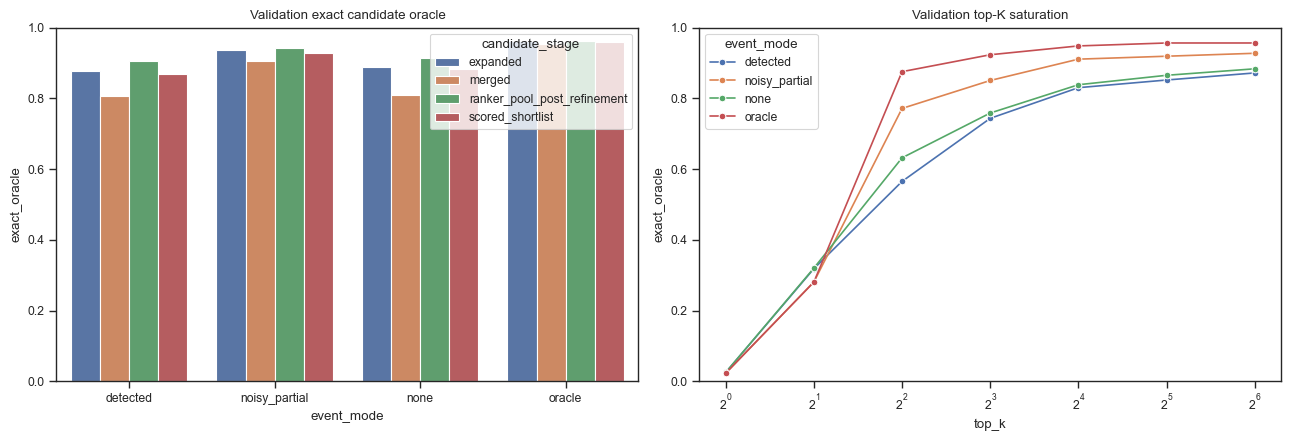

In [39]:
def _decode_methods(value: Any) -> frozenset[str]:
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return frozenset()
    if isinstance(value, str):
        try:
            decoded = json.loads(value)
        except json.JSONDecodeError:
            decoded = [part for part in value.split(",") if part]
        return frozenset(map(str, decoded if isinstance(decoded, list) else [decoded]))
    if isinstance(value, Sequence):
        return frozenset(map(str, value))
    return frozenset({str(value)})


def _oracle_by_group(
    frame: pd.DataFrame,
    group_cols: list[str],
    trial_ledger: pd.DataFrame,
) -> pd.DataFrame:
    """Candidate ceiling with the complete expected-view ledger as denominator."""
    rows = []
    for group_key, denominator in trial_ledger.groupby(group_cols, dropna=False):
        group_key = group_key if isinstance(group_key, tuple) else (group_key,)
        mask = pd.Series(True, index=frame.index)
        for column, value in zip(group_cols, group_key):
            mask &= frame[column].isna() if pd.isna(value) else frame[column].eq(value)
        subset = frame.loc[mask]
        summary = period_candidate_ranker.candidate_oracle_summary(
            subset,
            group_col="base_view_id",
            exact_col="is_exact",
            family_col="is_harmonic_family",
            periodic_col="is_signal",
            rank_col=None,
            trial_ids=denominator,
            periodic_only=True,
        ).iloc[0]
        candidate_counts = (
            subset.groupby("base_view_id").size()
            .reindex(denominator["base_view_id"].astype(str), fill_value=0)
        )
        row = dict(zip(group_cols, group_key))
        row.update({
            "base_views": int(summary["n_trials"]),
            "base_views_with_candidates": int(summary["n_trials_with_candidates"]),
            "exact_oracle": float(summary["exact_oracle_rate"]),
            "family_oracle": float(summary["family_oracle_rate"]),
            "median_candidates": float(candidate_counts.median()),
        })
        rows.append(row)
    return pd.DataFrame(rows)


mm_bank_labeled = pd.DataFrame()
mm_oracle_summary = pd.DataFrame()
mm_topk_summary = pd.DataFrame()
mm_method_ablation = pd.DataFrame()
mm_candidate_gates = pd.DataFrame()
mm_oracle_expected_views = (
    mm_base_results.loc[
        mm_base_results.get("status", pd.Series(dtype=str)).eq("ok")
        & mm_base_results.get("is_signal", pd.Series(dtype=bool)).astype(bool)
    ].drop_duplicates("base_view_id").copy()
    if not mm_base_results.empty else pd.DataFrame()
)

if not mm_candidate_bank.empty and not mm_candidate_labels.empty:
    truth_columns = [
        "candidate_id",
        "true_period_days",
        "is_signal",
        "is_exact",
        "is_harmonic_family",
        "is_wrong_harmonic",
        "is_exact_relative",
        "is_harmonic_family_relative",
        "is_wrong_harmonic_relative",
        "is_exact_resolution_consistent",
        "is_harmonic_family_resolution_consistent",
        "nearest_harmonic_factor",
        "relative_period_error",
        "rayleigh_frequency_error",
    ]
    mm_bank_labeled = mm_candidate_bank.merge(
        mm_candidate_labels[truth_columns],
        on="candidate_id",
        how="inner",
        validate="one_to_one",
    )
    signal_bank = mm_bank_labeled.loc[mm_bank_labeled["is_signal"].astype(bool)].copy()
    scored_seed = signal_bank.loc[
        signal_bank["candidate_stage"].eq("expanded")
        & signal_bank.get("was_scored", False).astype(bool)
    ].copy()
    scored_shortlist = scored_seed.copy()
    scored_shortlist["candidate_stage"] = "scored_shortlist"
    ranker_pool = pd.concat([
        scored_seed,
        signal_bank.loc[signal_bank["candidate_stage"].eq("refined")],
    ], ignore_index=True)
    ranker_pool["candidate_stage"] = "ranker_pool_post_refinement"
    oracle_input = pd.concat([signal_bank, scored_shortlist, ranker_pool], ignore_index=True)
    oracle_stage_ledger = mm_oracle_expected_views.merge(
        pd.DataFrame({"candidate_stage": [
            "merged", "expanded", "scored_shortlist", "ranker_pool_post_refinement",
        ]}),
        how="cross",
    )
    mm_oracle_summary = _oracle_by_group(
        oracle_input,
        ["split", "event_mode", "candidate_stage"],
        oracle_stage_ledger,
    )
    display(mm_oracle_summary)
    _atomic_write_parquet(MM_ROOT / "metrics" / "candidate_oracle_summary.parquet", mm_oracle_summary)

    expanded = signal_bank.loc[signal_bank["candidate_stage"].eq("expanded")].copy()
    topk_rows: list[dict[str, Any]] = []
    for k in (1, 2, 4, 8, 16, 32, 64):
        subset = expanded.loc[expanded["bank_rank"] <= k]
        summary = _oracle_by_group(subset, ["split", "event_mode"], mm_oracle_expected_views)
        if not summary.empty:
            summary["top_k"] = k
            topk_rows.extend(summary.to_dict(orient="records"))
    mm_topk_summary = pd.DataFrame(topk_rows)
    display(mm_topk_summary)
    _atomic_write_parquet(MM_ROOT / "metrics" / "topk_oracle_saturation.parquet", mm_topk_summary)

    ablation_rows: list[dict[str, Any]] = []
    expanded["method_set"] = expanded["contributing_methods"].map(_decode_methods)
    for method in MM_GLOBAL_METHODS:
        # A candidate survives when at least one independent proposer remains.
        surviving = expanded.loc[expanded["method_set"].map(lambda values: bool(values - {method}))]
        summary = _oracle_by_group(surviving, ["split", "event_mode"], mm_oracle_expected_views)
        if not summary.empty:
            summary["removed_method"] = method
            ablation_rows.extend(summary.to_dict(orient="records"))
    mm_method_ablation = pd.DataFrame(ablation_rows)
    display(mm_method_ablation.loc[mm_method_ablation["split"].eq("validation")])
    _atomic_write_parquet(MM_ROOT / "metrics" / "leave_one_method_out_oracle.parquet", mm_method_ablation)

    raw_context = mm_base_results[[
        "base_view_id", "split", "event_mode", "true_period_days", "is_signal"
    ]].drop_duplicates("base_view_id")
    raw_labeled = period_candidate_ranker.label_candidates(
        mm_raw_candidates.merge(
            raw_context.drop(columns=["split", "event_mode"]),
            on="base_view_id",
            how="left",
            validate="many_to_one",
        ),
        period_col="period_days",
        truth_col="true_period_days",
        harmonic_factors=MM_HARMONIC_FACTORS,
        truth_periodic_col="is_signal",
        baseline_days=MM_BASELINE_DAYS,
        rayleigh_tolerance=1.0,
        require_relative_with_rayleigh=True,
    )
    proposer_rows = []
    for (split_name, event_mode), denominator in raw_context.loc[raw_context["is_signal"].astype(bool)].groupby(["split", "event_mode"]):
        for method, method_rows in raw_labeled.loc[
            raw_labeled["split"].eq(split_name) & raw_labeled["event_mode"].eq(event_mode)
        ].groupby("method"):
            summary = period_candidate_ranker.candidate_oracle_summary(
                method_rows,
                group_col="base_view_id",
                rank_col="proposal_index",
                top_ks=(1, 3, 5, 10),
                trial_ids=denominator,
                periodic_only=True,
            )
            summary.insert(0, "method", method)
            summary.insert(0, "event_mode", event_mode)
            summary.insert(0, "split", split_name)
            proposer_rows.append(summary)
    mm_raw_proposer_oracle = pd.concat(proposer_rows, ignore_index=True) if proposer_rows else pd.DataFrame()
    if not mm_raw_proposer_oracle.empty:
        display(mm_raw_proposer_oracle.loc[mm_raw_proposer_oracle["split"].eq("validation")])
        _atomic_write_parquet(MM_ROOT / "metrics" / "raw_proposer_oracle.parquet", mm_raw_proposer_oracle)

    module_method_rows = []
    module_input = expanded.copy()
    module_input["truth_is_periodic"] = True
    module_input["contributing_methods"] = module_input["method_set"].map(lambda values: "|".join(sorted(values)))
    for (split_name, event_mode), subset in module_input.groupby(["split", "event_mode"]):
        method_ledger = mm_oracle_expected_views.loc[
            mm_oracle_expected_views["split"].eq(split_name)
            & mm_oracle_expected_views["event_mode"].eq(event_mode)
        ]
        summary = period_candidate_ranker.method_ablation_summary(
            subset,
            method_col="contributing_methods",
            group_col="base_view_id",
            trial_ids=method_ledger,
        )
        summary.insert(0, "event_mode", event_mode)
        summary.insert(0, "split", split_name)
        module_method_rows.append(summary)
    mm_module_method_ablation = pd.concat(module_method_rows, ignore_index=True)
    _atomic_write_parquet(MM_ROOT / "metrics" / "method_ablation_module_check.parquet", mm_module_method_ablation)

    method_availability = (
        mm_search_status.groupby(["split", "event_mode", "method", "status"], dropna=False)
        .agg(searches=("base_view_id", "size"), median_candidates=("candidate_count", "median"))
        .reset_index()
    )
    metadata_columns = [name for name in mm_search_status if name.startswith("meta_")]
    if metadata_columns:
        metadata_summary = (
            mm_search_status.groupby(["split", "event_mode", "method", "status"], dropna=False)[metadata_columns]
            .first()
            .reset_index()
        )
        method_availability = method_availability.merge(
            metadata_summary,
            on=["split", "event_mode", "method", "status"],
            how="left",
            validate="one_to_one",
        )
    method_availability["interpretation"] = np.where(
        method_availability["method"].eq("bls_coarse"),
        "coarse_lower_bound_experiment_not_a_resolved_global_BLS",
        "configured_search",
    )
    _atomic_write_parquet(MM_ROOT / "metrics" / "method_availability.parquet", method_availability)

    base_context = mm_base_results[[
        "base_view_id", "morphology", "period_regime", "nuisance_mode", "is_signal"
    ]].drop_duplicates("base_view_id")
    sliced = expanded.merge(base_context, on="base_view_id", how="left", suffixes=("", "_base"))
    slice_parts = []
    for slice_axis in ("morphology", "period_regime", "nuisance_mode"):
        part = _oracle_by_group(
            sliced,
            ["split", "event_mode", slice_axis],
            mm_oracle_expected_views,
        )
        part = part.rename(columns={slice_axis: "slice_value"})
        part["slice_axis"] = slice_axis
        slice_parts.append(part)
    slice_oracle = pd.concat(slice_parts, ignore_index=True)
    _atomic_write_parquet(MM_ROOT / "metrics" / "candidate_oracle_slices.parquet", slice_oracle)

    validation_global = mm_oracle_summary.loc[
        mm_oracle_summary["split"].eq("validation")
        & mm_oracle_summary["candidate_stage"].isin([
            "expanded", "scored_shortlist", "ranker_pool_post_refinement"
        ])
    ].copy()
    gate_rows = []
    for (event_mode, candidate_stage), sub in validation_global.groupby(["event_mode", "candidate_stage"], dropna=False):
        gate_rows.extend([
            {
                "event_mode": event_mode,
                "candidate_stage": candidate_stage,
                "gate": f"{candidate_stage}_exact_oracle_ge_0.98",
                "value": float(sub["exact_oracle"].iloc[0]),
                "threshold": 0.98,
                "passed": bool(sub["exact_oracle"].iloc[0] >= 0.98),
            },
            {
                "event_mode": event_mode,
                "candidate_stage": candidate_stage,
                "gate": f"{candidate_stage}_family_oracle_ge_0.99",
                "value": float(sub["family_oracle"].iloc[0]),
                "threshold": 0.99,
                "passed": bool(sub["family_oracle"].iloc[0] >= 0.99),
            },
        ])
    validation_slices = slice_oracle.loc[
        slice_oracle["split"].eq("validation") & (slice_oracle["base_views"] >= 50)
    ]
    for _, row in validation_slices.iterrows():
        gate_rows.append({
            "event_mode": row["event_mode"],
            "candidate_stage": "expanded",
            "gate": f"slice_exact_ge_0.95::{row['slice_axis']}::{row['slice_value']}",
            "base_views": int(row["base_views"]),
            "value": float(row["exact_oracle"]),
            "threshold": 0.95,
            "passed": bool(row["exact_oracle"] >= 0.95),
        })
    mm_candidate_gates = pd.DataFrame(gate_rows)
    mm_candidate_gates["run_manifest_fingerprint"] = mm_manifest_fingerprint
    display(mm_candidate_gates.loc[~mm_candidate_gates["passed"]])
    _atomic_write_parquet(MM_ROOT / "metrics" / "candidate_generation_gates.parquet", mm_candidate_gates)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    validation_oracle = mm_oracle_summary.loc[mm_oracle_summary["split"].eq("validation")]
    sns.barplot(
        data=validation_oracle,
        x="event_mode",
        y="exact_oracle",
        hue="candidate_stage",
        ax=axes[0],
    )
    axes[0].set_ylim(0, 1)
    axes[0].set_title("Validation exact candidate oracle")
    validation_topk = mm_topk_summary.loc[mm_topk_summary["split"].eq("validation")]
    sns.lineplot(
        data=validation_topk,
        x="top_k",
        y="exact_oracle",
        hue="event_mode",
        marker="o",
        ax=axes[1],
    )
    axes[1].set_xscale("log", base=2)
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Validation top-K saturation")
    fig.tight_layout()
    (MM_ROOT / "figures").mkdir(parents=True, exist_ok=True)
    fig.savefig(MM_ROOT / "figures" / "candidate_oracle_and_topk.png", dpi=200, bbox_inches="tight")
    plt.show()
elif not mm_base_results.empty:
    # RAM-bounded full profile: derive the freeze-critical ceilings from the
    # committed one-row-per-view summaries without loading raw/bank ledgers.
    signal_views = mm_base_results.loc[
        mm_base_results["status"].eq("ok") & mm_base_results["is_signal"].astype(bool)
    ].copy()
    stage_columns = {
        "expanded": ("expanded_exact_oracle", "expanded_family_oracle"),
        "scored_shortlist": ("scored_exact_oracle", "scored_family_oracle"),
        "ranker_pool_post_refinement": ("post_refinement_exact_oracle", "post_refinement_family_oracle"),
    }
    summary_parts = []
    for candidate_stage, (exact_col, family_col) in stage_columns.items():
        part = (
            signal_views.groupby(["split", "event_mode"], dropna=False)
            .agg(
                base_views=("base_view_id", "size"),
                exact_oracle=(exact_col, "mean"),
                family_oracle=(family_col, "mean"),
                median_candidates=("expanded_candidate_count", "median"),
            )
            .reset_index()
        )
        part["candidate_stage"] = candidate_stage
        summary_parts.append(part)
    mm_oracle_summary = pd.concat(summary_parts, ignore_index=True)
    _atomic_write_parquet(MM_ROOT / "metrics" / "candidate_oracle_summary.parquet", mm_oracle_summary)
    gate_rows = []
    primary = mm_oracle_summary.loc[
        mm_oracle_summary["split"].eq("validation")
        & mm_oracle_summary["event_mode"].eq("detected")
    ]
    for _, row in primary.iterrows():
        gate_rows.extend([
            {
                "event_mode": "detected", "candidate_stage": row["candidate_stage"],
                "gate": f"{row['candidate_stage']}_exact_oracle_ge_0.98",
                "value": float(row["exact_oracle"]), "threshold": 0.98,
                "passed": bool(row["exact_oracle"] >= 0.98),
            },
            {
                "event_mode": "detected", "candidate_stage": row["candidate_stage"],
                "gate": f"{row['candidate_stage']}_family_oracle_ge_0.99",
                "value": float(row["family_oracle"]), "threshold": 0.99,
                "passed": bool(row["family_oracle"] >= 0.99),
            },
        ])
    for slice_axis in ("morphology", "period_regime", "nuisance_mode"):
        sliced = (
            signal_views.loc[
                signal_views["split"].eq("validation") & signal_views["event_mode"].eq("detected")
            ]
            .groupby(slice_axis, dropna=False)
            .agg(base_views=("base_view_id", "size"), exact_oracle=("expanded_exact_oracle", "mean"))
            .reset_index()
        )
        for _, row in sliced.loc[sliced["base_views"] >= 50].iterrows():
            gate_rows.append({
                "event_mode": "detected", "candidate_stage": "expanded",
                "gate": f"slice_exact_ge_0.95::{slice_axis}::{row[slice_axis]}",
                "base_views": int(row["base_views"]), "value": float(row["exact_oracle"]),
                "threshold": 0.95, "passed": bool(row["exact_oracle"] >= 0.95),
            })
    mm_candidate_gates = pd.DataFrame(gate_rows)
    mm_candidate_gates["run_manifest_fingerprint"] = mm_manifest_fingerprint
    _atomic_write_parquet(MM_ROOT / "metrics" / "candidate_generation_gates.parquet", mm_candidate_gates)
    display(mm_oracle_summary)
    print("Heavy proposer ledgers remain in committed checkpoint parts; set MALCA_MM_LOAD_HEAVY_DIAGNOSTICS=1 in a separate diagnostics run.")
else:
    print("Candidate-oracle analysis waits for MALCA_MM_RUN=1 artifacts.")

# Always-on method/scorer health gates: caught method errors cannot masquerade
# as scientifically valid no-extrema, no-event, or insufficient-cycle states.
health_gate_rows = []
if not mm_search_status.empty:
    optional_global_methods = {"bls_coarse", "supersmoother"}
    mm_method_health = (
        mm_search_status.assign(
            is_runtime_failure=mm_search_status["status"].isin(["error", "unavailable", "disabled", "unknown"])
        )
        .groupby(["method", "status"], dropna=False)
        .size()
        .rename("searches")
        .reset_index()
    )
    mm_method_health["optional_experiment"] = mm_method_health["method"].isin(optional_global_methods)
    health_metadata_columns = [name for name in mm_search_status if name.startswith("meta_")]
    if health_metadata_columns:
        health_metadata = (
            mm_search_status.groupby(["method", "status"], dropna=False)[health_metadata_columns]
            .first()
            .reset_index()
        )
        mm_method_health = mm_method_health.merge(
            health_metadata, on=["method", "status"], how="left", validate="one_to_one"
        )
    mm_method_health["interpretation"] = np.where(
        mm_method_health["method"].eq("bls_coarse"),
        "coarse_lower_bound_experiment_not_a_resolved_global_BLS",
        "configured_search",
    )
    _atomic_write_parquet(MM_ROOT / "metrics" / "global_method_health.parquet", mm_method_health)
    for method in MM_GLOBAL_METHODS:
        rows = mm_search_status.loc[mm_search_status["method"].eq(method)]
        failure_fraction = (
            float(rows["status"].isin(["error", "unavailable", "disabled", "unknown"]).mean())
            if not rows.empty else 1.0
        )
        if method not in optional_global_methods:
            health_gate_rows.append({
                "event_mode": "all", "candidate_stage": "global_search_health",
                "gate": f"required_global_method_runtime_failure_fraction_eq_0::{method}",
                "value": failure_fraction, "threshold": 0.0,
                "passed": bool(failure_fraction == 0.0),
            })

if not mm_candidate_features.empty:
    expected_fixed_statuses = (
        "ls_status", "pdm_status", "ce_status", "bls_status",
        "multiharmonic_fourier_status", "lafler_kinman_status", "template_status",
        "odd_even_status", "event_status", "alias_status",
    )
    scorer_health_rows = []
    for status_col in (*expected_fixed_statuses, "supersmoother_status"):
        if status_col not in mm_candidate_features:
            if status_col in expected_fixed_statuses:
                health_gate_rows.append({
                    "event_mode": "all", "candidate_stage": "fixed_scorer_health",
                    "gate": f"required_fixed_scorer_status_present::{status_col}",
                    "value": 0.0, "threshold": 1.0, "passed": False,
                })
            continue
        counts = mm_candidate_features[status_col].astype("string").fillna("missing").value_counts(dropna=False)
        for status, count in counts.items():
            scorer_health_rows.append({
                "status_column": status_col, "status": str(status), "candidate_rows": int(count),
                "optional_experiment": status_col == "supersmoother_status",
            })
        if status_col in expected_fixed_statuses:
            failure_fraction = float(
                mm_candidate_features[status_col].astype("string").isin(["error", "unavailable"]).mean()
            )
            health_gate_rows.append({
                "event_mode": "all", "candidate_stage": "fixed_scorer_health",
                "gate": f"required_fixed_scorer_failure_fraction_le_0.01::{status_col}",
                "value": failure_fraction, "threshold": 0.01,
                "passed": bool(failure_fraction <= 0.01),
            })
    mm_fixed_scorer_health = pd.DataFrame(scorer_health_rows)
    if not mm_fixed_scorer_health.empty:
        _atomic_write_parquet(MM_ROOT / "metrics" / "fixed_scorer_health.parquet", mm_fixed_scorer_health)

if health_gate_rows:
    health_gates = pd.DataFrame(health_gate_rows)
    health_gates["run_manifest_fingerprint"] = mm_manifest_fingerprint
    mm_candidate_gates = pd.concat([mm_candidate_gates, health_gates], ignore_index=True)
    _atomic_write_parquet(MM_ROOT / "metrics" / "candidate_generation_gates.parquet", mm_candidate_gates)

## Deterministic baseline, learned ranker, and acceptance calibration

Candidate labels are recomputed through `label_candidates` after joining the
separate truth ledger. The concrete deployable feature allowlist is inferred,
printed, and stored in the model artifact; truth, morphology, S/N, nuisance,
split identity, and injection metadata cannot enter it.

The learned model trains only on `train`. Early stopping and probability/status
calibration use only `validation`. The group is `base_view_id`, so selection
occurs within one event view; base IDs remain split-disjoint, and results are
reported per event mode. A transparent percentile-score baseline is evaluated
alongside it. Training contains one `none` and one `detected` view per base.
Probability calibration, primary threshold selection, gates, and headline
development reporting use `detected`, the deployable event path. `none` has a
separately tuned paired-ablation policy; privileged `noisy_partial` and
`oracle` arms are evaluation-only and inherit the detected policy.

Validation base IDs are split deterministically and at base level into disjoint
probability-calibration and threshold-development halves, stratified by signal
versus null. An expected-view ledger preserves successfully processed views with
zero candidates as explicit abstentions in every metric denominator.

Optional feature-family ablations refit on train, recalibrate on the detected
calibration half, and retune on the disjoint threshold-development half.
They are expensive and require `MALCA_MM_RUN_ABLATIONS=1`. Model freezing is
allowed only for the full profile after all candidate-generation gates pass.

In [40]:
MM_RUN_ABLATIONS = True
MM_RANKER_PATH = MM_MODELS_ROOT / "candidate_ranker.joblib"
MM_RANKER_METADATA_PATH = MM_MODELS_ROOT / "candidate_ranker_metadata.json"
MM_THRESHOLD_POLICY_PATH = MM_MODELS_ROOT / "validation_threshold_policy.json"
MM_THRESHOLD_SWEEP_PATH = MM_MODELS_ROOT / "validation_threshold_sweep.parquet"
if MM_MODEL_FREEZE_PATH.exists() and (MM_FIT_RANKER or MM_FREEZE_MODEL):
    raise RuntimeError(
        "This run tag is frozen; refitting or rewriting its model/policy is forbidden. Use a fresh run tag."
    )

mm_model_candidates = pd.DataFrame()
mm_ranker_artifact = None
mm_ranker_predictions = pd.DataFrame()
mm_solution_predictions = pd.DataFrame()
mm_baseline_solutions = pd.DataFrame()
mm_feature_ablation = pd.DataFrame()
mm_refinement_ablation = pd.DataFrame()
MM_PRIMARY_EVENT_MODE = "detected"
MM_ABLATION_EVENT_MODE = "none"
MM_DEPLOYABLE_EVENT_MODES = (MM_ABLATION_EVENT_MODE, MM_PRIMARY_EVENT_MODE)
mm_status_thresholds_by_mode: dict[str, Any] = {}
mm_threshold_constraints_satisfied = False


def _policy_mode(event_mode: Any) -> str:
    return MM_ABLATION_EVENT_MODE if str(event_mode) == MM_ABLATION_EVENT_MODE else MM_PRIMARY_EVENT_MODE


def _select_with_event_policies(
    scored: pd.DataFrame,
    artifact: Any,
    policies: Mapping[str, Any],
    expected_trials: pd.DataFrame,
) -> pd.DataFrame:
    """Select each event arm separately and retain candidate-less expected views."""
    parts = []
    for event_mode, expected in expected_trials.groupby("event_mode", sort=False, dropna=False):
        subset = scored.loc[scored["event_mode"].eq(event_mode)].copy()
        policy = policies[_policy_mode(event_mode)]
        parts.append(period_candidate_ranker.select_trial_solutions(
            subset,
            artifact,
            status_thresholds=policy,
            expected_trials=expected,
        ))
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


def _tune_event_policies(
    scored: pd.DataFrame,
    artifact: Any,
    expected_trials: pd.DataFrame,
) -> tuple[dict[str, Any], pd.DataFrame, dict[str, Any]]:
    policies: dict[str, Any] = {}
    policy_records: dict[str, Any] = {}
    sweep_parts = []
    for event_mode in MM_DEPLOYABLE_EVENT_MODES:
        expected = expected_trials.loc[expected_trials["event_mode"].eq(event_mode)].copy()
        subset = scored.loc[scored["event_mode"].eq(event_mode)].copy()
        selected = period_candidate_ranker.select_trial_solutions(
            subset,
            artifact,
            expected_trials=expected,
        )
        tuning = period_candidate_ranker.tune_solution_thresholds(
            selected,
            artifact,
            require_feasible=False,
            group_col="base_view_id",
            target_null_accepted_rate=0.05,
            target_harmonic_only_rate=0.05,
            minimum_exact_recovery_rate=0.80,
            minimum_family_recovery_rate=0.95,
            minimum_periodic_coverage=0.90,
            use_confidence_bounds_for_constraints=True,
            constraint_confidence_level=0.95,
        )
        policies[event_mode] = tuning.thresholds
        policy_records[event_mode] = {
            "thresholds": tuning.thresholds.as_dict(),
            "metadata": tuning.metadata,
            "source_event_mode": event_mode,
            "role": "primary" if event_mode == MM_PRIMARY_EVENT_MODE else "paired_ablation",
        }
        sweep = tuning.sweep.copy()
        sweep.insert(0, "source_event_mode", event_mode)
        sweep_parts.append(sweep)
    combined_core = {
        "schema_version": "period-candidate-thresholds-by-event-v2",
        "selection_role": "threshold_dev",
        "primary_event_mode": MM_PRIMARY_EVENT_MODE,
        "policies": policy_records,
    }
    combined_fingerprint = hashlib.sha256(
        json.dumps(combined_core, sort_keys=True, separators=(",", ":"), default=str).encode("utf-8")
    ).hexdigest()
    payload = {
        **combined_core,
        "metadata": {
            "threshold_policy_fingerprint": combined_fingerprint,
            "confidence_scope": "balanced_case_control_injection_benchmark_not_survey_posterior",
            "deployment_recalibration_required": True,
            "constraints_satisfied": bool(
                policy_records[MM_PRIMARY_EVENT_MODE]["metadata"].get("constraints_satisfied", False)
            ),
            "all_event_policies_constraints_satisfied": bool(all(
                record["metadata"].get("constraints_satisfied", False) for record in policy_records.values()
            )),
        },
    }
    return policies, pd.concat(sweep_parts, ignore_index=True), payload

if not mm_candidate_features.empty and not mm_candidate_labels.empty:
    deployable_features = mm_candidate_features.copy()
    deployable_features["contributing_methods"] = deployable_features["contributing_methods"].map(
        lambda value: "|".join(sorted(_decode_methods(value)))
    )
    inferred_features = period_candidate_ranker.default_feature_columns(deployable_features)
    mm_feature_columns = tuple(
        name for name in inferred_features
        if not name.endswith(("_message", "_error", "_dependency_version"))
        and name not in {"proposal_metadata", "attempt_id", "part_index"}
    )
    forbidden_design_features = {
        "alias_target_days", "sampling_density", "amplitude_snr", "width_fraction",
        "median_error", "morphology", "nuisance_mode", "period_regime", "split",
        "base_trial_id", "base_view_id", "true_period_days", "is_signal",
        "attempt_id", "part_index", "evaluation_role", "detected_event_backend",
    }
    leaked_features = forbidden_design_features.intersection(mm_feature_columns)
    assert not leaked_features, f"Injection/design leakage in ranker allowlist: {sorted(leaked_features)}"
    truth = mm_candidate_labels.loc[
        mm_candidate_labels["candidate_stage"].isin(["expanded", "refined"]),
        ["candidate_id", "true_period_days", "is_signal", "is_exact", "is_harmonic_family"],
    ].drop_duplicates("candidate_id")
    base_context_columns = [
        "base_view_id", "detected_event_backend", "morphology", "period_regime", "nuisance_mode",
        "alias_target_days", "amplitude_snr", "width_fraction", "sampling_density",
        "median_error", "realized_baseline_cycles",
    ]
    base_context = mm_base_results[base_context_columns].drop_duplicates("base_view_id")
    mm_model_candidates = (
        deployable_features
        .merge(truth, on="candidate_id", how="inner", validate="one_to_one", suffixes=("", "_ledger"))
        .merge(base_context, on="base_view_id", how="left", validate="many_to_one")
    )
    mm_model_candidates = period_candidate_ranker.label_candidates(
        mm_model_candidates.drop(columns=["is_exact", "is_harmonic_family"], errors="ignore"),
        period_col="period_days",
        truth_col="true_period_days",
        harmonic_factors=MM_HARMONIC_FACTORS,
        tolerance=0.05,
        exact_tolerance=0.05,
        truth_periodic_col="is_signal",
        baseline_days=MM_BASELINE_DAYS,
        rayleigh_tolerance=1.0,
        require_relative_with_rayleigh=True,
    )
    mm_ranker_config = period_candidate_ranker.RankerConfig(
        feature_columns=mm_feature_columns,
        group_col="base_view_id",
        candidate_id_col="candidate_id",
        period_col="period_days",
        method_col="contributing_methods",
        random_state=MM_SEED,
        n_jobs=MM_WORKERS,
        model_kind="classifier",
    )
    print(f"Ranker deployable features ({len(mm_feature_columns)}):")
    print("\n".join(f"  - {name}" for name in mm_feature_columns))

    validation_base_table = (
        mm_base_results.loc[mm_base_results["split"].eq("validation"), ["base_trial_id", "is_signal"]]
        .drop_duplicates("base_trial_id")
    )
    role_by_base: dict[str, str] = {}
    for is_signal, subset in validation_base_table.groupby("is_signal", dropna=False):
        ordered = sorted(
            subset["base_trial_id"].astype(str),
            key=lambda base_id: _stable_seed(MM_SEED, base_id, "validation-role"),
        )
        if len(ordered) < 2:
            raise RuntimeError("Validation signal/null strata each need at least two bases.")
        cut = len(ordered) // 2
        role_by_base.update({base_id: "calibration" for base_id in ordered[:cut]})
        role_by_base.update({base_id: "threshold_dev" for base_id in ordered[cut:]})

    def _evaluation_role(row: pd.Series) -> str:
        split = str(row["split"])
        if split == "validation":
            return role_by_base[str(row["base_trial_id"])]
        return split

    mm_model_candidates["evaluation_role"] = mm_model_candidates.apply(_evaluation_role, axis=1)
    expected_columns = [
        "base_trial_id", "base_view_id", "split", "event_mode", "detected_event_backend", "is_signal",
        "morphology", "period_regime", "nuisance_mode", "alias_target_days",
        "amplitude_snr", "width_fraction", "sampling_density", "median_error",
        "realized_baseline_cycles", "true_period_days",
    ]
    mm_expected_trials = (
        mm_base_results.loc[mm_base_results["status"].eq("ok"), expected_columns]
        .drop_duplicates("base_view_id")
        .copy()
    )
    mm_expected_trials["evaluation_role"] = mm_expected_trials.apply(_evaluation_role, axis=1)
    mm_expected_trials["truth_is_periodic"] = mm_expected_trials["is_signal"].astype(bool)
    for label_col in (
        "is_exact", "is_harmonic_family", "is_harmonic_only",
        "is_exact_relative", "is_harmonic_family_relative", "is_harmonic_only_relative",
        "is_exact_resolution_consistent", "is_harmonic_family_resolution_consistent",
        "is_harmonic_only_resolution_consistent",
    ):
        mm_expected_trials[label_col] = False

    mm_train = mm_model_candidates.loc[
        mm_model_candidates["split"].eq("train")
        & mm_model_candidates["event_mode"].isin(MM_DEPLOYABLE_EVENT_MODES)
    ].copy()
    mm_calibration = mm_model_candidates.loc[
        mm_model_candidates["evaluation_role"].eq("calibration")
        & mm_model_candidates["event_mode"].eq(MM_PRIMARY_EVENT_MODE)
    ].copy()
    mm_threshold_dev = mm_model_candidates.loc[
        mm_model_candidates["evaluation_role"].eq("threshold_dev")
        & mm_model_candidates["event_mode"].isin(MM_DEPLOYABLE_EVENT_MODES)
    ].copy()
    mm_threshold_expected = mm_expected_trials.loc[
        mm_expected_trials["evaluation_role"].eq("threshold_dev")
        & mm_expected_trials["event_mode"].isin(MM_DEPLOYABLE_EVENT_MODES)
    ].copy()
    train_base_ids = set(mm_expected_trials.loc[mm_expected_trials["split"].eq("train"), "base_trial_id"].astype(str))
    calibration_base_ids = {base_id for base_id, role in role_by_base.items() if role == "calibration"}
    threshold_dev_base_ids = {base_id for base_id, role in role_by_base.items() if role == "threshold_dev"}
    assert train_base_ids.isdisjoint(calibration_base_ids | threshold_dev_base_ids)
    assert calibration_base_ids.isdisjoint(threshold_dev_base_ids)
    expected_deployable = mm_expected_trials.loc[
        mm_expected_trials["event_mode"].isin(MM_DEPLOYABLE_EVENT_MODES)
        & mm_expected_trials["evaluation_role"].isin(["train", "calibration", "threshold_dev"])
    ]
    for role_name, split_frame in expected_deployable.groupby("evaluation_role"):
        deployable_views_per_base = (
            split_frame[["base_trial_id", "event_mode"]]
            .drop_duplicates()
            .groupby("base_trial_id")["event_mode"]
            .nunique()
        )
        assert deployable_views_per_base.eq(2).all(), f"Every {role_name} base must have exactly none+detected views"

    if not mm_threshold_dev.empty:
        baseline_ranked = period_candidate_ranker.rank_deterministic_baseline(
            mm_threshold_dev,
            group_col="base_view_id",
            period_col="period_days",
            candidate_id_col="candidate_id",
        )
        mm_baseline_solutions = period_candidate_ranker.select_trial_solutions(
            baseline_ranked,
            artifact=None,
            group_col="base_view_id",
            period_col="period_days",
            candidate_id_col="candidate_id",
            score_col="baseline_score",
            rank_col="baseline_rank",
            expected_trials=mm_threshold_expected,
        )
        # The baseline has no calibrated abstention model; accept all only for ranking comparison.
        mm_baseline_solutions.loc[~mm_baseline_solutions["no_candidate"].astype(bool), "solution_status"] = "tentative"
        _atomic_write_parquet(MM_ROOT / "predictions" / "deterministic_validation_solutions.parquet", mm_baseline_solutions)
        baseline_summary_rows = []
        for event_mode, subset in mm_baseline_solutions.groupby("event_mode", dropna=False):
            summary = period_candidate_ranker.summarize_recovery(
                subset,
                accepted_statuses=("tentative",),
            )
            summary.insert(0, "event_mode", event_mode)
            summary.insert(0, "policy", "accept_all_top1_no_calibration")
            baseline_summary_rows.append(summary)
        mm_baseline_top1_summary = pd.concat(baseline_summary_rows, ignore_index=True)
        display(mm_baseline_top1_summary)
        _atomic_write_parquet(MM_ROOT / "metrics" / "deterministic_baseline_top1_recovery.parquet", mm_baseline_top1_summary)

    failed_gates = (
        mm_candidate_gates.loc[
            ~mm_candidate_gates["passed"]
            & mm_candidate_gates["event_mode"].isin([MM_PRIMARY_EVENT_MODE, "all"])
        ]
        if not mm_candidate_gates.empty else pd.DataFrame()
    )
    gates_current = (
        not mm_candidate_gates.empty
        and "run_manifest_fingerprint" in mm_candidate_gates
        and mm_candidate_gates["run_manifest_fingerprint"].eq(mm_manifest_fingerprint).all()
    )
    if MM_FIT_RANKER:
        if MM_PROFILE != "smoke" and not failed_gates.empty:
            warnings.warn(
                f"Candidate generation failed {len(failed_gates)} validation gates; fit proceeds for diagnostics, but freeze remains blocked.",
                RuntimeWarning,
            )
        mm_ranker_artifact = period_candidate_ranker.fit_candidate_ranker(
            mm_train,
            mm_calibration,
            config=mm_ranker_config,
        )
        period_candidate_ranker.save_candidate_ranker_artifact(mm_ranker_artifact, MM_RANKER_PATH)
        _atomic_write_json(MM_RANKER_METADATA_PATH, {
            **mm_ranker_artifact.metadata,
            "probability_calibration_event_mode": MM_PRIMARY_EVENT_MODE,
            "probability_calibration_role": "calibration",
            "confidence_scope": "balanced_case_control_injection_benchmark_not_survey_posterior",
            "deployment_recalibration_required": True,
        })
    elif MM_RANKER_PATH.exists():
        mm_ranker_artifact = period_candidate_ranker.load_candidate_ranker_artifact(MM_RANKER_PATH)

    if MM_FREEZE_MODEL:
        if MM_MODEL_FREEZE_PATH.exists():
            raise RuntimeError("Model freeze manifest already exists; refusing to overwrite it.")
        if MM_PROFILE != "full":
            raise RuntimeError("Only the full profile can produce the frozen-test model.")
        if mm_ranker_artifact is None:
            raise RuntimeError("Fit or load a ranker before freezing it.")
        if not gates_current:
            raise RuntimeError("Candidate-generation gates are absent or belong to a different run manifest.")
        if not failed_gates.empty:
            raise RuntimeError("Candidate-generation gates must all pass before model freeze.")

    if mm_ranker_artifact is not None:
        threshold_scored_for_policy = period_candidate_ranker.score_candidate_ranker(
            mm_threshold_dev,
            mm_ranker_artifact,
        )
        if MM_FIT_RANKER:
            mm_status_thresholds_by_mode, threshold_sweep, threshold_payload = _tune_event_policies(
                threshold_scored_for_policy,
                mm_ranker_artifact,
                mm_threshold_expected,
            )
            mm_threshold_constraints_satisfied = bool(threshold_payload["metadata"]["constraints_satisfied"])
            _atomic_write_parquet(MM_THRESHOLD_SWEEP_PATH, threshold_sweep)
            _atomic_write_json(MM_THRESHOLD_POLICY_PATH, threshold_payload)
        elif MM_THRESHOLD_POLICY_PATH.exists():
            threshold_payload = json.loads(MM_THRESHOLD_POLICY_PATH.read_text())
            if threshold_payload.get("schema_version") != "period-candidate-thresholds-by-event-v2":
                raise RuntimeError("Threshold policy predates separate detected/none policies; use a fresh run tag.")
            mm_status_thresholds_by_mode = {
                mode: period_candidate_ranker.StatusThresholds(**record["thresholds"])
                for mode, record in threshold_payload["policies"].items()
            }
            mm_threshold_constraints_satisfied = bool(threshold_payload.get("metadata", {}).get("constraints_satisfied", False))
        else:
            default_thresholds = period_candidate_ranker.StatusThresholds(
                secure_acceptance_threshold=mm_ranker_artifact.config.secure_acceptance_threshold,
                secure_exact_threshold=mm_ranker_artifact.config.secure_exact_threshold,
                secure_family_threshold=mm_ranker_artifact.config.secure_family_threshold,
                tentative_acceptance_threshold=mm_ranker_artifact.config.tentative_acceptance_threshold,
            )
            mm_status_thresholds_by_mode = {
                mode: default_thresholds for mode in MM_DEPLOYABLE_EVENT_MODES
            }

        if MM_FREEZE_MODEL:
            if MM_PRIMARY_ARBITRATOR == "single_stage_v1" and not mm_threshold_constraints_satisfied:
                raise RuntimeError("Validation threshold policy does not satisfy recovery/FPR/coverage constraints.")
            threshold_payload = json.loads(MM_THRESHOLD_POLICY_PATH.read_text())
            freeze_payload = {
                "schema_version": "period-candidate-model-freeze-v2",
                "run_manifest_fingerprint": mm_manifest_fingerprint,
                "ranker_artifact_fingerprint": mm_ranker_artifact.metadata["artifact_fingerprint"],
                "threshold_policy_fingerprint": threshold_payload["metadata"]["threshold_policy_fingerprint"],
                "threshold_policies": threshold_payload["policies"],
                "primary_arbitrator": MM_PRIMARY_ARBITRATOR,
                "primary_event_mode": MM_PRIMARY_EVENT_MODE,
                "detected_event_backend": MM_DETECTED_EVENT_BACKEND,
                "confidence_scope": "balanced_case_control_injection_benchmark_not_survey_posterior",
                "deployment_recalibration_required": True,
                "feature_columns": list(mm_ranker_artifact.feature_columns),
                "train_base_id_sha256": hashlib.sha256("\n".join(sorted(train_base_ids)).encode()).hexdigest(),
                "calibration_base_id_sha256": hashlib.sha256("\n".join(sorted(calibration_base_ids)).encode()).hexdigest(),
                "threshold_dev_base_id_sha256": hashlib.sha256("\n".join(sorted(threshold_dev_base_ids)).encode()).hexdigest(),
                "frozen_test_was_opened": False,
            }
            _atomic_write_json(MM_MODEL_FREEZE_PATH, freeze_payload)

        scored_parts = []
        solution_parts = []
        for split_name, expected_split in mm_expected_trials.groupby("split", sort=False):
            split_frame = mm_model_candidates.loc[mm_model_candidates["split"].eq(split_name)].copy()
            scored = period_candidate_ranker.score_candidate_ranker(split_frame, mm_ranker_artifact)
            solutions = _select_with_event_policies(
                scored,
                mm_ranker_artifact,
                mm_status_thresholds_by_mode,
                expected_split,
            )
            scored_parts.append(scored)
            solution_parts.append(solutions)
        mm_ranker_predictions = pd.concat(scored_parts, ignore_index=True)
        mm_solution_predictions = pd.concat(solution_parts, ignore_index=True)
        _atomic_write_parquet(MM_ROOT / "predictions" / "candidate_scores.parquet", mm_ranker_predictions)
        _atomic_write_parquet(MM_ROOT / "predictions" / "trial_solutions.parquet", mm_solution_predictions)
        ranker_oracle_rows = []
        for (split_name, event_mode), subset in mm_ranker_predictions.groupby(["split", "event_mode"]):
            oracle_ledger = mm_expected_trials.loc[
                mm_expected_trials["split"].eq(split_name)
                & mm_expected_trials["event_mode"].eq(event_mode)
            ]
            summary = period_candidate_ranker.candidate_oracle_summary(
                subset,
                group_col="base_view_id",
                rank_col="candidate_rank",
                top_ks=(1, 2, 4, 8, 16, 32, 64),
                trial_ids=oracle_ledger,
            )
            summary.insert(0, "event_mode", event_mode)
            summary.insert(0, "split", split_name)
            ranker_oracle_rows.append(summary)
        mm_ranker_topk_oracle = pd.concat(ranker_oracle_rows, ignore_index=True)
        _atomic_write_parquet(MM_ROOT / "metrics" / "ranker_topk_oracle.parquet", mm_ranker_topk_oracle)

        refinement_rows = []
        for pool_name, pool_frame in (
            ("pre_refinement", mm_threshold_dev.loc[~mm_threshold_dev["candidate_stage"].eq("refined")]),
            ("post_refinement", mm_threshold_dev),
        ):
            pool_scored = period_candidate_ranker.score_candidate_ranker(pool_frame, mm_ranker_artifact)
            pool_solutions = _select_with_event_policies(
                pool_scored,
                mm_ranker_artifact,
                mm_status_thresholds_by_mode,
                mm_threshold_expected,
            )
            for event_mode, sub in pool_solutions.groupby("event_mode", dropna=False):
                summary = period_candidate_ranker.summarize_recovery(sub)
                summary.insert(0, "event_mode", event_mode)
                summary.insert(0, "candidate_pool", pool_name)
                refinement_rows.append(summary)
        mm_refinement_ablation = pd.concat(refinement_rows, ignore_index=True)
        _atomic_write_parquet(MM_ROOT / "metrics" / "local_refinement_ablation.parquet", mm_refinement_ablation)
        display(mm_refinement_ablation)

        if MM_RUN_ABLATIONS:
            feature_families = {
                "ls": ("ls_",),
                "pdm_ce": ("pdm_", "ce_"),
                "bls": ("bls_",),
                "multiharmonic_fourier": ("fourier_", "multiharmonic_"),
                "string_smoother_template": ("lafler_", "string_length", "supersmoother_", "template_", "heldout_"),
                "odd_even": ("odd_even_",),
                "events": ("event_",),
                "aliases_support": ("alias_", "support_", "method_", "proposal_"),
            }
            ablation_rows = []
            for family_name, prefixes in feature_families.items():
                retained = tuple(
                    name for name in mm_feature_columns
                    if not any(name.startswith(prefix) for prefix in prefixes)
                )
                if not retained:
                    continue
                ablated_config = replace(mm_ranker_config, feature_columns=retained)
                artifact = period_candidate_ranker.fit_candidate_ranker(mm_train, mm_calibration, config=ablated_config)
                scored = period_candidate_ranker.score_candidate_ranker(mm_threshold_dev, artifact)
                ablation_policies, _, ablation_policy_payload = _tune_event_policies(
                    scored,
                    artifact,
                    mm_threshold_expected,
                )
                solutions = _select_with_event_policies(
                    scored,
                    artifact,
                    ablation_policies,
                    mm_threshold_expected,
                )
                for event_mode, sub in solutions.groupby("event_mode", dropna=False):
                    summary = period_candidate_ranker.summarize_recovery(sub)
                    summary.insert(0, "event_mode", event_mode)
                    summary.insert(0, "removed_feature_family", family_name)
                    summary["remaining_feature_count"] = len(retained)
                    summary["threshold_constraints_satisfied"] = ablation_policy_payload["metadata"]["constraints_satisfied"]
                    ablation_rows.append(summary)
            mm_feature_ablation = pd.concat(ablation_rows, ignore_index=True) if ablation_rows else pd.DataFrame()
            if not mm_feature_ablation.empty:
                _atomic_write_parquet(MM_ROOT / "metrics" / "feature_family_ablation.parquet", mm_feature_ablation)
                display(mm_feature_ablation)
    else:
        print("No ranker artifact yet; set MALCA_MM_FIT_RANKER=1 after candidate gates are reviewed.")
else:
    print("Ranker stage waits for candidate feature and truth ledgers.")

Ranker deployable features (132):
  - period_days
  - contributing_methods
  - harmonic_factor
  - proposal_method
  - proposal_raw_score
  - proposal_rank
  - proposal_prominence
  - proposal_normalized_score
  - proposal_search_band
  - proposal_contributing_method_count
  - proposal_independent_method_family_count
  - proposal_harmonic_factor
  - proposal_is_harmonic_expansion
  - proposal_merged_count
  - n_points
  - baseline_days
  - baseline_cycles
  - ls_power
  - ls_local_best_power
  - ls_local_relative_shift
  - ls_local_frequency_half_width
  - pdm_theta
  - ce_entropy
  - bls_power
  - bls_exact_power
  - bls_exact_duration_days
  - bls_exact_duration_phase_fraction
  - bls_exact_depth
  - bls_exact_depth_err
  - bls_exact_depth_snr
  - bls_exact_log_likelihood
  - bls_duration_days
  - bls_duration_phase_fraction
  - bls_depth
  - bls_depth_err
  - bls_depth_snr
  - bls_log_likelihood
  - bls_local_best_power
  - bls_refined_relative_shift
  - fourier_1_power
  - fourier_

,policy,event_mode,n_trials,n_periodic,n_null,n_accepted,coverage,abstention_rate,exact_recovery_n,exact_recovery_rate,...,periodic_accepted_n,periodic_coverage,conditional_exact_rate,conditional_family_rate,null_accepted_n,null_accepted_rate,secure_fundamental_n,secure_family_harmonic_ambiguous_n,tentative_n,abstain_n
0,accept_all_top1_no_calibration,detected,600,300,300,600,1.0,0.0,210,0.700000,...,300,1.0,0.700000,0.846667,300,1.0,0,0,600,0
1,accept_all_top1_no_calibration,none,600,300,300,600,1.0,0.0,214,0.713333,...,300,1.0,0.713333,0.853333,300,1.0,0,0,600,0


/var/folders/z5/95nmr_n10ls6x2913x09nzs80000gn/T/ipykernel_58146/3142193108.py:297: RuntimeWarning: Candidate generation failed 19 validation gates; fit proceeds for diagnostics, but freeze remains blocked.
  warnings.warn(
/Users/calder/code/malca/malca/evaluation/period_candidate_ranker.py:349: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[name] = values.where(np.isfinite(values), np.nan)
/Users/calder/code/malca/malca/evaluation/period_candidate_ranker.py:349: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[name] = valu

,candidate_pool,event_mode,n_trials,n_periodic,n_null,n_accepted,coverage,abstention_rate,exact_recovery_n,exact_recovery_rate,...,periodic_accepted_n,periodic_coverage,conditional_exact_rate,conditional_family_rate,null_accepted_n,null_accepted_rate,secure_fundamental_n,secure_family_harmonic_ambiguous_n,tentative_n,abstain_n
0,pre_refinement,detected,600,300,300,272,0.453333,0.546667,215,0.716667,...,241,0.803333,0.892116,0.966805,31,0.103333,81,191,10,318
1,pre_refinement,none,600,300,300,279,0.465000,0.535000,223,0.743333,...,247,0.823333,0.902834,0.975709,32,0.106667,86,193,11,310
2,post_refinement,detected,600,300,300,266,0.443333,0.556667,215,0.716667,...,241,0.803333,0.892116,0.979253,25,0.083333,4,262,24,310
3,post_refinement,none,600,300,300,266,0.443333,0.556667,216,0.720000,...,241,0.803333,0.896266,0.987552,25,0.083333,3,263,25,309


/Users/calder/code/malca/malca/evaluation/period_candidate_ranker.py:349: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[name] = values.where(np.isfinite(values), np.nan)
/Users/calder/code/malca/malca/evaluation/period_candidate_ranker.py:349: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[name] = values.where(np.isfinite(values), np.nan)
/Users/calder/code/malca/malca/evaluation/period_candidate_ranker.py:349: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many t

,removed_feature_family,event_mode,n_trials,n_periodic,n_null,n_accepted,coverage,abstention_rate,exact_recovery_n,exact_recovery_rate,...,conditional_exact_rate,conditional_family_rate,null_accepted_n,null_accepted_rate,secure_fundamental_n,secure_family_harmonic_ambiguous_n,tentative_n,abstain_n,remaining_feature_count,threshold_constraints_satisfied
0,ls,detected,600,300,300,277,0.461667,0.538333,222,0.740000,...,0.888000,0.976000,27,0.090000,2,275,8,315,128,False
1,ls,none,600,300,300,281,0.468333,0.531667,225,0.750000,...,0.885827,0.984252,27,0.090000,1,280,5,314,128,False
2,pdm_ce,detected,600,300,300,291,0.485000,0.515000,226,0.753333,...,0.886275,0.980392,36,0.120000,2,289,1,308,130,False
3,pdm_ce,none,600,300,300,294,0.490000,0.510000,228,0.760000,...,0.880309,0.976834,35,0.116667,2,292,2,304,130,False
4,bls,detected,600,300,300,271,0.451667,0.548333,217,0.723333,...,0.904167,0.979167,31,0.103333,2,269,12,317,116,False
5,bls,none,600,300,300,276,0.460000,0.540000,220,0.733333,...,0.897959,0.983673,31,0.103333,1,275,10,314,116,False
6,multiharmonic_fourier,detected,600,300,300,271,0.451667,0.548333,215,0.716667,...,0.899582,0.983264,32,0.106667,0,271,30,299,117,False
7,multiharmonic_fourier,none,600,300,300,272,0.453333,0.546667,218,0.726667,...,0.900826,0.987603,30,0.100000,0,272,30,298,117,False
8,string_smoother_template,detected,600,300,300,268,0.446667,0.553333,200,0.666667,...,0.896861,0.973094,45,0.150000,0,268,57,275,113,False
9,string_smoother_template,none,600,300,300,265,0.441667,0.558333,201,0.670000,...,0.893333,0.968889,40,0.133333,0,265,69,266,113,False


## Hierarchical V2: family ranker, fundamental resolver, and null gate

This is the primary V2 arbitration experiment. Candidate rows are clustered
into harmonic families without truth, families receive graded relevance
(exact=2, harmonic-family=1, unrelated=0), and a separate resolver compares
members of the selected family with explicit P/2 and 2P sibling differences.
A third classifier accepts or rejects the resolved solution and upweights the
seasonal-trend, red-noise, isolated-dip, and aperiodic-dip hard negatives.

The three models learn on `train`; their probability calibrators use only the
disjoint `calibration` bases. Status thresholds use only `threshold_dev`.
The existing single-stage predictions are retained as V1 comparison output,
but downstream notebook metrics use the hierarchical V2 solutions.


In [ ]:
MM_HIERARCHICAL_PATH = MM_MODELS_ROOT / "hierarchical_period_arbitrator.joblib"
MM_HIERARCHICAL_METADATA_PATH = MM_MODELS_ROOT / "hierarchical_period_arbitrator_metadata.json"
MM_HIERARCHICAL_POLICY_PATH = MM_MODELS_ROOT / "hierarchical_validation_threshold_policy.json"
MM_HIERARCHICAL_SWEEP_PATH = MM_MODELS_ROOT / "hierarchical_validation_threshold_sweep.parquet"

mm_hierarchical_artifact = None
mm_hierarchical_solutions = pd.DataFrame()
mm_hierarchical_family_scores = pd.DataFrame()
mm_hierarchical_resolver_scores = pd.DataFrame()
mm_hierarchical_acceptance_scores = pd.DataFrame()
mm_hierarchical_policies: dict[str, Any] = {}
mm_event_detector_diagnostics = pd.DataFrame()
mm_event_detector_summary = pd.DataFrame()

event_diagnostic_columns = [
    "base_trial_id", "morphology", "period_regime", "amplitude_snr", "width_fraction",
    "event_detection_status", "event_detection_match_tolerance_days",
    "event_detection_injected_count", "event_detection_detected_count",
    "event_detection_matched_count", "event_detection_precision", "event_detection_recall",
    "event_detection_false_event_fraction", "event_detection_missed_event_fraction",
    "event_detection_epoch_bias_days", "event_detection_epoch_median_abs_error_days",
    "event_detection_epoch_rms_days",
]
available_event_diagnostic_columns = [name for name in event_diagnostic_columns if name in mm_base_results]
if available_event_diagnostic_columns and "event_detection_recall" in mm_base_results:
    mm_event_detector_diagnostics = (
        mm_base_results.loc[
            mm_base_results["event_mode"].eq("detected")
            & mm_base_results["is_signal"].astype(bool)
            & mm_base_results["event_detection_injected_count"].gt(0),
            available_event_diagnostic_columns,
        ]
        .drop_duplicates("base_trial_id")
        .copy()
    )
    _atomic_write_parquet(MM_ROOT / "metrics" / "event_epoch_detection_diagnostics.parquet", mm_event_detector_diagnostics)
    if not mm_event_detector_diagnostics.empty:
        mm_event_detector_summary = (
            mm_event_detector_diagnostics
            .groupby(["morphology", "width_fraction", "amplitude_snr"], dropna=False)
            .agg(
                n_bases=("base_trial_id", "nunique"),
                mean_precision=("event_detection_precision", "mean"),
                mean_recall=("event_detection_recall", "mean"),
                median_abs_epoch_error_days=("event_detection_epoch_median_abs_error_days", "median"),
                mean_false_event_fraction=("event_detection_false_event_fraction", "mean"),
            )
            .reset_index()
        )
        _atomic_write_parquet(MM_ROOT / "metrics" / "event_epoch_detection_summary.parquet", mm_event_detector_summary)
        display(mm_event_detector_summary)


def _tune_hierarchical_event_policies(
    candidates: pd.DataFrame,
    artifact: Any,
    expected_trials: pd.DataFrame,
) -> tuple[dict[str, Any], pd.DataFrame, dict[str, Any]]:
    policies: dict[str, Any] = {}
    policy_records: dict[str, Any] = {}
    sweeps = []
    for event_mode in MM_DEPLOYABLE_EVENT_MODES:
        subset = candidates.loc[candidates["event_mode"].eq(event_mode)].copy()
        expected = expected_trials.loc[expected_trials["event_mode"].eq(event_mode)].copy()
        scored = period_hierarchical_ranker.score_hierarchical_period_arbitrator(
            subset,
            artifact,
            expected_trials=expected,
        )
        tuning = period_candidate_ranker.tune_solution_thresholds(
            scored.solutions,
            artifact=None,
            require_feasible=False,
            group_col="base_view_id",
            target_null_accepted_rate=0.05,
            target_harmonic_only_rate=0.05,
            minimum_exact_recovery_rate=0.90,
            minimum_family_recovery_rate=0.95,
            minimum_periodic_coverage=0.90,
            use_confidence_bounds_for_constraints=True,
            constraint_confidence_level=0.95,
        )
        policies[event_mode] = tuning.thresholds
        policy_records[event_mode] = {
            "thresholds": tuning.thresholds.as_dict(),
            "metadata": tuning.metadata,
            "source_event_mode": event_mode,
            "role": "primary" if event_mode == MM_PRIMARY_EVENT_MODE else "paired_ablation",
        }
        sweep = tuning.sweep.copy()
        sweep.insert(0, "source_event_mode", event_mode)
        sweeps.append(sweep)
    core = {
        "schema_version": "period-hierarchical-thresholds-by-event-v2",
        "selection_role": "threshold_dev",
        "primary_event_mode": MM_PRIMARY_EVENT_MODE,
        "policies": policy_records,
    }
    fingerprint = hashlib.sha256(
        json.dumps(core, sort_keys=True, separators=(",", ":"), default=str).encode("utf-8")
    ).hexdigest()
    payload = {
        **core,
        "metadata": {
            "threshold_policy_fingerprint": fingerprint,
            "confidence_scope": "balanced_case_control_injection_benchmark_not_survey_posterior",
            "deployment_recalibration_required": True,
            "constraints_satisfied": bool(
                policy_records[MM_PRIMARY_EVENT_MODE]["metadata"].get("constraints_satisfied", False)
            ),
            "all_event_policies_constraints_satisfied": bool(all(
                record["metadata"].get("constraints_satisfied", False)
                for record in policy_records.values()
            )),
        },
    }
    return policies, pd.concat(sweeps, ignore_index=True), payload


def _score_hierarchical_by_event_policy(
    candidates: pd.DataFrame,
    artifact: Any,
    expected_trials: pd.DataFrame,
    policies: Mapping[str, Any],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    solution_parts = []
    family_parts = []
    resolver_parts = []
    acceptance_parts = []
    for event_mode, expected in expected_trials.groupby("event_mode", sort=False, dropna=False):
        subset = candidates.loc[candidates["event_mode"].eq(event_mode)].copy()
        result = period_hierarchical_ranker.score_hierarchical_period_arbitrator(
            subset,
            artifact,
            status_thresholds=policies[_policy_mode(event_mode)],
            expected_trials=expected,
        )
        solution_parts.append(result.solutions)
        family_parts.append(result.family_scores)
        resolver_parts.append(result.resolver_scores)
        acceptance_parts.append(result.acceptance_scores)
    return (
        pd.concat(solution_parts, ignore_index=True) if solution_parts else pd.DataFrame(),
        pd.concat(family_parts, ignore_index=True) if family_parts else pd.DataFrame(),
        pd.concat(resolver_parts, ignore_index=True) if resolver_parts else pd.DataFrame(),
        pd.concat(acceptance_parts, ignore_index=True) if acceptance_parts else pd.DataFrame(),
    )


if not mm_model_candidates.empty:
    mm_hierarchical_config = period_hierarchical_ranker.HierarchicalArbitratorConfig(
        group_col="base_view_id",
        split_group_col="base_trial_id",
        candidate_id_col="candidate_id",
        period_col="period_days",
        harmonic_factors=MM_HARMONIC_FACTORS,
        random_state=MM_SEED + 17,
        n_jobs=MM_WORKERS,
        n_estimators=500,
        learning_rate=0.02,
        min_child_samples=12,
    )
    if MM_FIT_RANKER:
        mm_hierarchical_artifact = period_hierarchical_ranker.fit_hierarchical_period_arbitrator(
            mm_train,
            mm_calibration,
            candidate_feature_columns=mm_feature_columns,
            config=mm_hierarchical_config,
        )
        period_hierarchical_ranker.save_hierarchical_period_arbitrator(
            mm_hierarchical_artifact,
            MM_HIERARCHICAL_PATH,
        )
        _atomic_write_json(MM_HIERARCHICAL_METADATA_PATH, mm_hierarchical_artifact.metadata)
    elif MM_HIERARCHICAL_PATH.exists():
        mm_hierarchical_artifact = period_hierarchical_ranker.load_hierarchical_period_arbitrator(
            MM_HIERARCHICAL_PATH
        )

    if mm_hierarchical_artifact is not None:
        if MM_FIT_RANKER:
            mm_hierarchical_policies, hierarchical_sweep, hierarchical_policy_payload = (
                _tune_hierarchical_event_policies(
                    mm_threshold_dev,
                    mm_hierarchical_artifact,
                    mm_threshold_expected,
                )
            )
            _atomic_write_parquet(MM_HIERARCHICAL_SWEEP_PATH, hierarchical_sweep)
            _atomic_write_json(MM_HIERARCHICAL_POLICY_PATH, hierarchical_policy_payload)
        elif MM_HIERARCHICAL_POLICY_PATH.exists():
            hierarchical_policy_payload = json.loads(MM_HIERARCHICAL_POLICY_PATH.read_text())
            if hierarchical_policy_payload.get("schema_version") != "period-hierarchical-thresholds-by-event-v2":
                raise RuntimeError("Hierarchical threshold policy has an incompatible schema.")
            mm_hierarchical_policies = {
                mode: period_candidate_ranker.StatusThresholds(**record["thresholds"])
                for mode, record in hierarchical_policy_payload["policies"].items()
            }
        else:
            mm_hierarchical_policies = {
                mode: mm_hierarchical_config.status_thresholds()
                for mode in MM_DEPLOYABLE_EVENT_MODES
            }

        if MM_FREEZE_MODEL:
            if not hierarchical_policy_payload.get("metadata", {}).get("constraints_satisfied", False):
                raise RuntimeError("Hierarchical validation policy does not satisfy the required recovery/FPR/coverage constraints.")
            freeze_payload = json.loads(MM_MODEL_FREEZE_PATH.read_text())
            freeze_payload.update({
                "primary_arbitrator": "hierarchical_v2",
                "hierarchical_artifact_fingerprint": mm_hierarchical_artifact.metadata["artifact_fingerprint"],
                "hierarchical_threshold_policy_fingerprint": hierarchical_policy_payload["metadata"]["threshold_policy_fingerprint"],
                "hierarchical_feature_columns": {
                    "candidate": list(mm_hierarchical_artifact.candidate_feature_columns),
                    "family": list(mm_hierarchical_artifact.family_feature_columns),
                    "resolver": list(mm_hierarchical_artifact.resolver_feature_columns),
                    "acceptance": list(mm_hierarchical_artifact.acceptance_feature_columns),
                },
            })
            _atomic_write_json(MM_MODEL_FREEZE_PATH, freeze_payload)

        solution_parts = []
        family_parts = []
        resolver_parts = []
        acceptance_parts = []
        for split_name, expected_split in mm_expected_trials.groupby("split", sort=False):
            split_candidates = mm_model_candidates.loc[mm_model_candidates["split"].eq(split_name)].copy()
            solutions, family_scores, resolver_scores, acceptance_scores = _score_hierarchical_by_event_policy(
                split_candidates,
                mm_hierarchical_artifact,
                expected_split,
                mm_hierarchical_policies,
            )
            solution_parts.append(solutions)
            family_parts.append(family_scores)
            resolver_parts.append(resolver_scores)
            acceptance_parts.append(acceptance_scores)
        mm_hierarchical_solutions = pd.concat(solution_parts, ignore_index=True)
        mm_hierarchical_family_scores = pd.concat(family_parts, ignore_index=True)
        mm_hierarchical_resolver_scores = pd.concat(resolver_parts, ignore_index=True)
        mm_hierarchical_acceptance_scores = pd.concat(acceptance_parts, ignore_index=True)
        _atomic_write_parquet(MM_ROOT / "predictions" / "hierarchical_trial_solutions.parquet", mm_hierarchical_solutions)
        _atomic_write_parquet(MM_ROOT / "predictions" / "hierarchical_family_scores.parquet", mm_hierarchical_family_scores)
        _atomic_write_parquet(MM_ROOT / "predictions" / "hierarchical_resolver_scores.parquet", mm_hierarchical_resolver_scores)
        _atomic_write_parquet(MM_ROOT / "predictions" / "hierarchical_acceptance_scores.parquet", mm_hierarchical_acceptance_scores)

        mm_v1_solution_predictions = mm_solution_predictions.copy()
        mm_solution_predictions = mm_hierarchical_solutions.copy()
        hierarchical_summary_rows = []
        for (role, event_mode), subset in mm_hierarchical_solutions.groupby(["evaluation_role", "event_mode"], dropna=False):
            summary = period_candidate_ranker.summarize_recovery(subset, group_col="base_view_id")
            summary.insert(0, "event_mode", event_mode)
            summary.insert(0, "evaluation_role", role)
            summary.insert(0, "arbitrator", "hierarchical_v2")
            hierarchical_summary_rows.append(summary)
        mm_hierarchical_summary = pd.concat(hierarchical_summary_rows, ignore_index=True)
        _atomic_write_parquet(MM_ROOT / "metrics" / "hierarchical_recovery_summary.parquet", mm_hierarchical_summary)
        display(mm_hierarchical_summary)
    else:
        print("No hierarchical artifact yet; fit it after candidate gates are reviewed.")
else:
    print("Hierarchical V2 waits for the candidate feature table.")

## Paper metrics, calibration, and paired event ablations

Paper metrics use one selected solution per `base_view_id`, with event arms
and evaluation roles reported on separate rows—calibration and threshold-dev
are never pooled under a generic validation label. The `detected` arm is the
primary deployable view; `none` is a paired ablation, and oracle/noisy arms are
privileged diagnostics. Accepted exact, accepted harmonic-family,
wrong-harmonic, catastrophic, coverage, conditional accuracy, abstention, and
null accepted-period false-positive rates are all retained. Wilson binomial
intervals are used; there is no bootstrap. Exact/family success requires both
`|delta f| T <= 1` and <=5% relative period error. Separate artifacts retain
Rayleigh-resolution-only and legacy relative-only results so long-period
resolution consistency cannot silently inflate strict recovery.

The target scoreboard shows point estimates and Wilson-bound decisions for the
requested exact >0.80, family >0.95,
harmonic-only <0.05, null-FPR <0.05, and periodic-coverage criteria. Because
`family = exact + harmonic_only` under these disjoint labels, jointly meeting
family >0.95 and harmonic-only <0.05 mathematically implies exact >0.90; that
stronger implied check is shown explicitly. Conditional accuracy among secure
accepted solutions remains separate from unconditional recovery.

The probability columns are confidence calibrated to this deliberately
balanced case-control injection mixture, not survey posterior probabilities.
Conditional recovery/FPR operating characteristics remain meaningful, but a
deployment posterior requires recalibration on representative real controls
and the survey periodic prevalence.

The frozen-test rows appear only after the explicit frozen unlock. Calibration
and threshold-development rows remain visible for diagnosis but are never
relabeled as unbiased held-out paper performance.

,label_scheme,split,evaluation_role,event_mode,detected_event_backend,n_trials,n_periodic,n_null,n_accepted,coverage,...,exact_recovery_ci_low,exact_recovery_ci_high,family_recovery_ci_low,family_recovery_ci_high,wrong_harmonic_ci_low,wrong_harmonic_ci_high,catastrophic_ci_low,catastrophic_ci_high,null_fpr_ci_low,null_fpr_ci_high
0,rayleigh_T_le_1_AND_relative_error_le_0.05,train,train,detected,pipeline,1800.0,1200.0,600.0,1125.0,0.625000,...,0.867483,0.903382,0.876377,0.911102,0.004533,0.015272,0.002828,0.011992,0.055079,0.097016
1,rayleigh_T_le_1_AND_relative_error_le_0.05,train,train,noisy_partial,pipeline,952.0,952.0,0.0,768.0,0.806723,...,0.753070,0.805601,0.771655,0.822586,0.011179,0.028411,0.004264,0.016494,NaN,NaN
2,rayleigh_T_le_1_AND_relative_error_le_0.05,train,train,none,pipeline,1800.0,1200.0,600.0,1125.0,0.625000,...,0.861276,0.897960,0.871037,0.906474,0.005126,0.016340,0.004533,0.015272,0.059417,0.102614
3,rayleigh_T_le_1_AND_relative_error_le_0.05,train,train,oracle,pipeline,952.0,952.0,0.0,759.0,0.797269,...,0.742171,0.795575,0.763993,0.815601,0.013640,0.032227,0.002892,0.013682,NaN,NaN
4,rayleigh_T_le_1_AND_relative_error_le_0.05,validation,calibration,detected,pipeline,600.0,300.0,300.0,277.0,0.461667,...,0.691047,0.789467,0.758216,0.847363,0.040917,0.096791,0.009198,0.042940,0.068150,0.135382
5,rayleigh_T_le_1_AND_relative_error_le_0.05,validation,calibration,noisy_partial,pipeline,238.0,238.0,0.0,180.0,0.756303,...,0.610311,0.728754,0.689094,0.798829,0.048372,0.116370,0.002308,0.030116,NaN,NaN
6,rayleigh_T_le_1_AND_relative_error_le_0.05,validation,calibration,none,pipeline,600.0,300.0,300.0,276.0,0.460000,...,0.687552,0.786379,0.758216,0.847363,0.043568,0.100723,0.007139,0.038415,0.068150,0.135382
7,rayleigh_T_le_1_AND_relative_error_le_0.05,validation,calibration,oracle,pipeline,238.0,238.0,0.0,182.0,0.764706,...,0.632008,0.748406,0.697971,0.806492,0.038563,0.101370,0.002308,0.030116,NaN,NaN
8,rayleigh_T_le_1_AND_relative_error_le_0.05,validation,threshold_dev,detected,pipeline,600.0,300.0,300.0,266.0,0.443333,...,0.663186,0.764669,0.736837,0.829247,0.046237,0.104636,0.007139,0.038415,0.057081,0.120122
9,rayleigh_T_le_1_AND_relative_error_le_0.05,validation,threshold_dev,noisy_partial,pipeline,243.0,243.0,0.0,180.0,0.740741,...,0.613678,0.730673,0.677872,0.788014,0.037762,0.099336,0.000727,0.022938,NaN,NaN


/var/folders/z5/95nmr_n10ls6x2913x09nzs80000gn/T/ipykernel_58146/4128202869.py:111: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & mm_target_scoreboard["wilson_null_fpr_upper_lt_0.05"].fillna(True).astype(bool)


,label_scheme,split,evaluation_role,event_mode,detected_event_backend,n_periodic,n_null,exact_recovery_rate,family_recovery_rate,harmonic_only_rate,...,family_gt_0.95,harmonic_only_lt_0.05,null_fpr_lt_0.05,periodic_coverage_ge_0.90,wilson_exact_lower_gt_0.80,wilson_family_lower_gt_0.95,wilson_harmonic_upper_lt_0.05,wilson_null_fpr_upper_lt_0.05,wilson_periodic_coverage_lower_ge_0.90,wilson_all_targets_pass
0,rayleigh_T_le_1_AND_relative_error_le_0.05,train,train,detected,pipeline,1200.0,600.0,0.886667,0.895000,0.008333,...,False,True,False,True,True,False,True,False,False,False
1,rayleigh_T_le_1_AND_relative_error_le_0.05,train,train,noisy_partial,pipeline,952.0,0.0,0.780462,0.798319,0.017857,...,False,True,<NA>,False,False,False,True,<NA>,False,False
2,rayleigh_T_le_1_AND_relative_error_le_0.05,train,train,none,pipeline,1200.0,600.0,0.880833,0.890000,0.009167,...,False,True,False,False,True,False,True,False,False,False
3,rayleigh_T_le_1_AND_relative_error_le_0.05,train,train,oracle,pipeline,952.0,0.0,0.769958,0.790966,0.021008,...,False,True,<NA>,False,False,False,True,<NA>,False,False
4,rayleigh_T_le_1_AND_relative_error_le_0.05,validation,calibration,detected,pipeline,300.0,300.0,0.743333,0.806667,0.063333,...,False,False,False,False,False,False,False,False,False,False
5,rayleigh_T_le_1_AND_relative_error_le_0.05,validation,calibration,noisy_partial,pipeline,238.0,0.0,0.672269,0.747899,0.075630,...,False,False,<NA>,False,False,False,False,<NA>,False,False
6,rayleigh_T_le_1_AND_relative_error_le_0.05,validation,calibration,none,pipeline,300.0,300.0,0.740000,0.806667,0.066667,...,False,False,False,False,False,False,False,False,False,False
7,rayleigh_T_le_1_AND_relative_error_le_0.05,validation,calibration,oracle,pipeline,238.0,0.0,0.693277,0.756303,0.063025,...,False,False,<NA>,False,False,False,False,<NA>,False,False
8,rayleigh_T_le_1_AND_relative_error_le_0.05,validation,threshold_dev,detected,pipeline,300.0,300.0,0.716667,0.786667,0.070000,...,False,False,False,False,False,False,False,False,False,False
9,rayleigh_T_le_1_AND_relative_error_le_0.05,validation,threshold_dev,noisy_partial,pipeline,243.0,0.0,0.674897,0.736626,0.061728,...,False,False,<NA>,False,False,False,False,<NA>,False,False


,event_mode,evaluation_role,calibration_scope,probability,trials,brier_score
0,detected,threshold_dev,balanced_injection_benchmark_not_survey_posterior,acceptance,600,0.108832
1,detected,threshold_dev,balanced_injection_benchmark_not_survey_posterior,exact,600,0.101491
2,detected,threshold_dev,balanced_injection_benchmark_not_survey_posterior,family,600,0.084857
3,noisy_partial,threshold_dev,balanced_injection_benchmark_not_survey_posterior,acceptance,243,0.158086
4,noisy_partial,threshold_dev,balanced_injection_benchmark_not_survey_posterior,exact,243,0.165749
5,noisy_partial,threshold_dev,balanced_injection_benchmark_not_survey_posterior,family,243,0.113671
6,none,threshold_dev,balanced_injection_benchmark_not_survey_posterior,acceptance,600,0.106929
7,none,threshold_dev,balanced_injection_benchmark_not_survey_posterior,exact,600,0.100184
8,none,threshold_dev,balanced_injection_benchmark_not_survey_posterior,family,600,0.081124
9,oracle,threshold_dev,balanced_injection_benchmark_not_survey_posterior,acceptance,243,0.163544


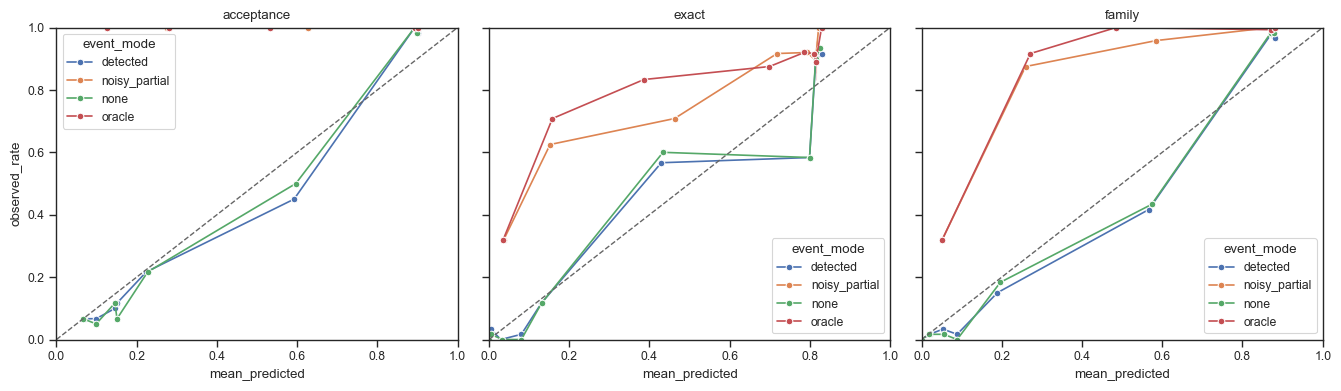

,split,evaluation_role,comparison,paired_bases,mean_delta_is_exact,improved_is_exact,degraded_is_exact,mean_delta_is_harmonic_family,improved_is_harmonic_family,degraded_is_harmonic_family,mean_delta_acceptance_probability,improved_acceptance_probability,degraded_acceptance_probability
0,train,train,detected_minus_none,952,0.004202,5,1,0.003151,4,1,0.002866,17,9
1,validation,calibration,detected_minus_none,238,0.008403,3,1,0.008403,2,0,0.005785,7,4
2,validation,threshold_dev,detected_minus_none,243,-0.008230,1,3,-0.012346,0,3,-0.002718,7,10
3,train,train,noisy_partial_minus_none,952,-0.005252,31,36,0.021008,32,12,-0.038830,41,98
4,validation,calibration,noisy_partial_minus_none,238,0.021008,11,6,0.025210,8,2,-0.010082,22,21
5,validation,threshold_dev,noisy_partial_minus_none,243,0.041152,13,3,0.016461,6,2,-0.009450,23,27
6,train,train,oracle_minus_none,952,-0.007353,32,39,0.031513,40,10,-0.043934,46,107
7,validation,calibration,oracle_minus_none,238,0.042017,11,1,0.033613,9,1,-0.005010,20,23
8,validation,threshold_dev,oracle_minus_none,243,0.057613,16,2,0.020576,7,2,-0.017712,22,35


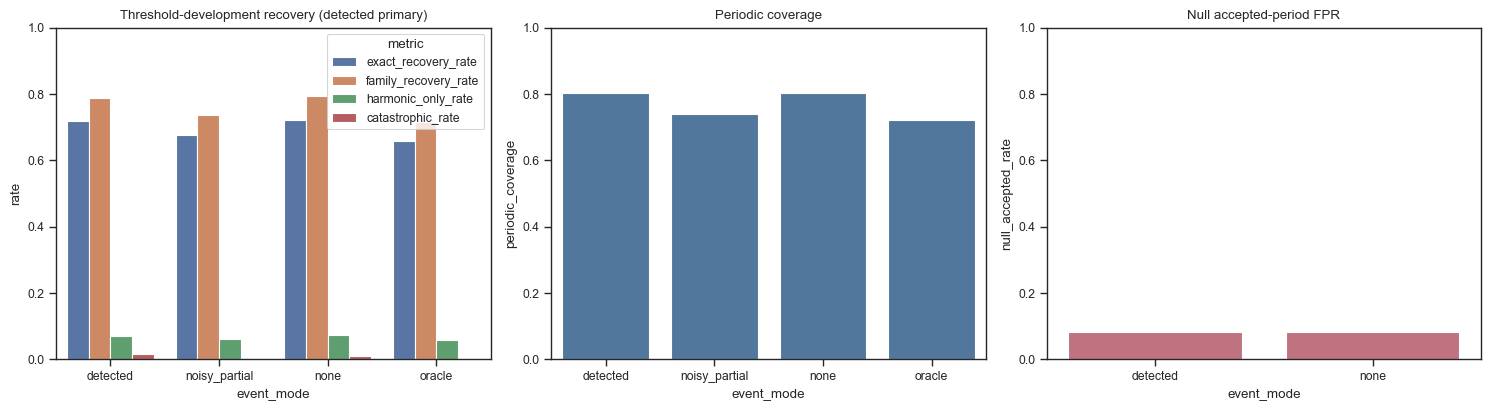

In [41]:
def _wilson_interval(successes: int, trials: int, z: float = 1.959963984540054) -> tuple[float, float]:
    if trials <= 0:
        return np.nan, np.nan
    p = successes / trials
    denominator = 1.0 + z**2 / trials
    center = (p + z**2 / (2.0 * trials)) / denominator
    half = z * np.sqrt(p * (1.0 - p) / trials + z**2 / (4.0 * trials**2)) / denominator
    return float(max(0.0, center - half)), float(min(1.0, center + half))


def mm_recovery_table(
    solutions: pd.DataFrame,
    group_cols: Sequence[str],
    *,
    exact_col: str = "is_exact",
    family_col: str = "is_harmonic_family",
) -> pd.DataFrame:
    rows = []
    for group_key, subset in solutions.groupby(list(group_cols), dropna=False):
        group_key = group_key if isinstance(group_key, tuple) else (group_key,)
        summary = period_candidate_ranker.summarize_recovery(
            subset,
            group_col="base_view_id",
            exact_col=exact_col,
            family_col=family_col,
        ).iloc[0].to_dict()
        row = dict(zip(group_cols, group_key))
        row.update(summary)
        interval_specs = {
            "overall_coverage": (int(summary["n_accepted"]), int(summary["n_trials"])),
            "periodic_coverage": (int(summary["periodic_accepted_n"]), int(summary["n_periodic"])),
            "exact_recovery": (int(summary["exact_recovery_n"]), int(summary["n_periodic"])),
            "family_recovery": (int(summary["family_recovery_n"]), int(summary["n_periodic"])),
            "wrong_harmonic": (int(summary["harmonic_only_n"]), int(summary["n_periodic"])),
            "catastrophic": (int(summary["catastrophic_n"]), int(summary["n_periodic"])),
            "null_fpr": (int(summary["null_accepted_n"]), int(summary["n_null"])),
        }
        for name, (successes, trials) in interval_specs.items():
            low, high = _wilson_interval(successes, trials)
            row[f"{name}_ci_low"] = low
            row[f"{name}_ci_high"] = high
        rows.append(row)
    return pd.DataFrame(rows)


mm_paper_metrics = pd.DataFrame()
mm_legacy_relative_metrics = pd.DataFrame()
mm_resolution_consistent_metrics = pd.DataFrame()
mm_slice_metrics = pd.DataFrame()
mm_paired_event_ablation = pd.DataFrame()
if not mm_solution_predictions.empty:
    metric_groups = ["split", "evaluation_role", "event_mode", "detected_event_backend"]
    mm_paper_metrics = mm_recovery_table(mm_solution_predictions, metric_groups)
    mm_paper_metrics.insert(0, "label_scheme", "rayleigh_T_le_1_AND_relative_error_le_0.05")
    display(mm_paper_metrics)
    _atomic_write_parquet(MM_ROOT / "metrics" / "paper_recovery_by_event_mode.parquet", mm_paper_metrics)
    mm_legacy_relative_metrics = mm_recovery_table(
        mm_solution_predictions,
        metric_groups,
        exact_col="is_exact_relative",
        family_col="is_harmonic_family_relative",
    )
    mm_legacy_relative_metrics.insert(0, "label_scheme", "legacy_relative_error_le_0.05")
    _atomic_write_parquet(
        MM_ROOT / "metrics" / "legacy_relative_recovery_by_event_mode.parquet",
        mm_legacy_relative_metrics,
    )
    mm_resolution_consistent_metrics = mm_recovery_table(
        mm_solution_predictions,
        metric_groups,
        exact_col="is_exact_resolution_consistent",
        family_col="is_harmonic_family_resolution_consistent",
    )
    mm_resolution_consistent_metrics.insert(0, "label_scheme", "rayleigh_resolution_consistent_only_T_le_1")
    _atomic_write_parquet(
        MM_ROOT / "metrics" / "resolution_consistent_recovery_by_event_mode.parquet",
        mm_resolution_consistent_metrics,
    )
    mm_target_scoreboard = mm_paper_metrics[[
        "label_scheme", "split", "evaluation_role", "event_mode", "detected_event_backend", "n_periodic", "n_null",
        "exact_recovery_rate", "family_recovery_rate", "harmonic_only_rate",
        "null_accepted_rate", "periodic_coverage", "conditional_exact_rate",
        "conditional_family_rate",
        "exact_recovery_ci_low", "family_recovery_ci_low", "wrong_harmonic_ci_high",
        "null_fpr_ci_high", "periodic_coverage_ci_low",
    ]].copy()
    mm_target_scoreboard["requested_exact_gt_0.80"] = mm_target_scoreboard["exact_recovery_rate"] > 0.80
    mm_target_scoreboard["joint_implied_exact_gt_0.90"] = mm_target_scoreboard["exact_recovery_rate"] > 0.90
    mm_target_scoreboard["family_gt_0.95"] = mm_target_scoreboard["family_recovery_rate"] > 0.95
    mm_target_scoreboard["harmonic_only_lt_0.05"] = mm_target_scoreboard["harmonic_only_rate"] < 0.05
    mm_target_scoreboard["null_fpr_lt_0.05"] = np.where(
        mm_target_scoreboard["n_null"] > 0,
        mm_target_scoreboard["null_accepted_rate"] < 0.05,
        pd.NA,
    )
    mm_target_scoreboard["periodic_coverage_ge_0.90"] = mm_target_scoreboard["periodic_coverage"] >= 0.90
    mm_target_scoreboard["wilson_exact_lower_gt_0.80"] = mm_target_scoreboard["exact_recovery_ci_low"] > 0.80
    mm_target_scoreboard["wilson_family_lower_gt_0.95"] = mm_target_scoreboard["family_recovery_ci_low"] > 0.95
    mm_target_scoreboard["wilson_harmonic_upper_lt_0.05"] = mm_target_scoreboard["wrong_harmonic_ci_high"] < 0.05
    mm_target_scoreboard["wilson_null_fpr_upper_lt_0.05"] = np.where(
        mm_target_scoreboard["n_null"] > 0,
        mm_target_scoreboard["null_fpr_ci_high"] < 0.05,
        pd.NA,
    )
    mm_target_scoreboard["wilson_periodic_coverage_lower_ge_0.90"] = mm_target_scoreboard["periodic_coverage_ci_low"] >= 0.90
    mm_target_scoreboard["wilson_all_targets_pass"] = (
        mm_target_scoreboard["wilson_exact_lower_gt_0.80"]
        & mm_target_scoreboard["wilson_family_lower_gt_0.95"]
        & mm_target_scoreboard["wilson_harmonic_upper_lt_0.05"]
        & mm_target_scoreboard["wilson_periodic_coverage_lower_ge_0.90"]
        & mm_target_scoreboard["wilson_null_fpr_upper_lt_0.05"].fillna(True).astype(bool)
    )
    display(mm_target_scoreboard)
    _atomic_write_parquet(MM_ROOT / "metrics" / "target_scoreboard.parquet", mm_target_scoreboard)

    slice_columns = [
        "split", "evaluation_role", "event_mode", "detected_event_backend",
        "morphology", "period_regime", "nuisance_mode",
        "amplitude_snr", "width_fraction",
    ]
    mm_slice_metrics = mm_recovery_table(mm_solution_predictions, slice_columns)
    _atomic_write_parquet(MM_ROOT / "metrics" / "paper_recovery_slices.parquet", mm_slice_metrics)

    status_counts = (
        mm_solution_predictions.groupby(
            ["split", "evaluation_role", "event_mode", "detected_event_backend", "solution_status"],
            dropna=False,
        )
        .size()
        .rename("trials")
        .reset_index()
    )
    _atomic_write_parquet(MM_ROOT / "metrics" / "solution_status_counts.parquet", status_counts)

    calibration_rows = []
    brier_rows = []
    threshold_dev_solutions = mm_solution_predictions.loc[
        mm_solution_predictions["evaluation_role"].eq("threshold_dev")
    ].copy()
    calibration_specs = (
        ("acceptance", "acceptance_probability", "truth_is_periodic"),
        ("exact", "exact_probability", "is_exact"),
        ("family", "family_probability", "is_harmonic_family"),
    )
    for event_mode, event_rows in threshold_dev_solutions.groupby("event_mode", dropna=False):
        for probability_name, probability_col, truth_col in calibration_specs:
            probability = pd.to_numeric(event_rows[probability_col], errors="coerce")
            truth_values = event_rows[truth_col].astype(bool)
            finite = probability.notna() & np.isfinite(probability)
            if not finite.any():
                continue
            p = probability.loc[finite].clip(0, 1)
            y = truth_values.loc[finite].astype(float)
            brier_rows.append({
                "event_mode": event_mode,
                "evaluation_role": "threshold_dev",
                "calibration_scope": "balanced_injection_benchmark_not_survey_posterior",
                "probability": probability_name,
                "trials": len(p),
                "brier_score": float(np.mean((p - y) ** 2)),
            })
            n_bins = min(10, max(1, len(p) // 20))
            bin_id = pd.qcut(p.rank(method="first"), q=n_bins, labels=False, duplicates="drop")
            binned = pd.DataFrame({"predicted": p, "observed": y, "bin": bin_id}).groupby("bin", dropna=False).agg(
                trials=("observed", "size"),
                mean_predicted=("predicted", "mean"),
                observed_rate=("observed", "mean"),
            ).reset_index()
            binned.insert(0, "probability", probability_name)
            binned.insert(0, "event_mode", event_mode)
            binned.insert(0, "evaluation_role", "threshold_dev")
            binned.insert(0, "calibration_scope", "balanced_injection_benchmark_not_survey_posterior")
            calibration_rows.append(binned)
    mm_calibration_reliability = pd.concat(calibration_rows, ignore_index=True) if calibration_rows else pd.DataFrame()
    mm_brier_scores = pd.DataFrame(brier_rows)
    if not mm_calibration_reliability.empty:
        _atomic_write_parquet(MM_ROOT / "metrics" / "threshold_dev_calibration_reliability.parquet", mm_calibration_reliability)
        _atomic_write_parquet(MM_ROOT / "metrics" / "threshold_dev_brier_scores.parquet", mm_brier_scores)
        display(mm_brier_scores)
        fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0), sharex=True, sharey=True)
        for ax, probability_name in zip(axes, ("acceptance", "exact", "family")):
            subset = mm_calibration_reliability.loc[mm_calibration_reliability["probability"].eq(probability_name)]
            sns.lineplot(data=subset, x="mean_predicted", y="observed_rate", hue="event_mode", marker="o", ax=ax)
            ax.plot([0, 1], [0, 1], color="0.4", linestyle="--", linewidth=1)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_title(probability_name)
        fig.tight_layout()
        fig.savefig(MM_ROOT / "figures" / "threshold_dev_probability_reliability.png", dpi=200, bbox_inches="tight")
        plt.show()

    dip_solutions = mm_solution_predictions.loc[
        mm_solution_predictions["morphology"].isin(MM_DIP_MORPHOLOGIES)
    ].copy()
    paired = dip_solutions.pivot_table(
        index=["split", "evaluation_role", "base_trial_id"],
        columns="event_mode",
        values=["is_exact", "is_harmonic_family", "acceptance_probability"],
        aggfunc="first",
    )
    paired_rows = []
    if not paired.empty and "none" in paired.columns.get_level_values(1):
        for comparison in ("detected", "noisy_partial", "oracle"):
            if comparison not in paired.columns.get_level_values(1):
                continue
            for (split_name, evaluation_role), subset in paired.groupby(level=["split", "evaluation_role"]):
                row = {
                    "split": split_name,
                    "evaluation_role": evaluation_role,
                    "comparison": f"{comparison}_minus_none",
                    "paired_bases": len(subset),
                }
                for metric in ("is_exact", "is_harmonic_family", "acceptance_probability"):
                    comparison_values = pd.to_numeric(
                        subset[(metric, comparison)], errors="coerce"
                    ).astype(float)
                    none_values = pd.to_numeric(
                        subset[(metric, "none")], errors="coerce"
                    ).astype(float)
                    difference = comparison_values - none_values
                    row[f"mean_delta_{metric}"] = float(difference.mean())
                    row[f"improved_{metric}"] = int((difference > 0).sum())
                    row[f"degraded_{metric}"] = int((difference < 0).sum())
                paired_rows.append(row)
    mm_paired_event_ablation = pd.DataFrame(paired_rows)
    display(mm_paired_event_ablation)
    if not mm_paired_event_ablation.empty:
        _atomic_write_parquet(MM_ROOT / "metrics" / "paired_event_view_ablation.parquet", mm_paired_event_ablation)

    harmonic_confusion = pd.crosstab(
        [
            mm_solution_predictions["split"],
            mm_solution_predictions["evaluation_role"],
            mm_solution_predictions["event_mode"],
        ],
        mm_solution_predictions["truth_matched_harmonic_factor"],
        normalize="index",
    )
    harmonic_confusion.to_csv(MM_ROOT / "metrics" / "selected_harmonic_factor_confusion.csv")

    validation_metrics = mm_paper_metrics.loc[
        mm_paper_metrics["evaluation_role"].eq("threshold_dev")
    ].copy()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    melted = validation_metrics.melt(
        id_vars="event_mode",
        value_vars=["exact_recovery_rate", "family_recovery_rate", "harmonic_only_rate", "catastrophic_rate"],
        var_name="metric",
        value_name="rate",
    )
    sns.barplot(data=melted, x="event_mode", y="rate", hue="metric", ax=axes[0])
    axes[0].set_ylim(0, 1)
    axes[0].set_title("Threshold-development recovery (detected primary)")
    sns.barplot(data=validation_metrics, x="event_mode", y="periodic_coverage", color="#4477AA", ax=axes[1])
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Periodic coverage")
    null_metrics = validation_metrics.loc[validation_metrics["n_null"] > 0]
    sns.barplot(data=null_metrics, x="event_mode", y="null_accepted_rate", color="#CC6677", ax=axes[2])
    axes[2].set_ylim(0, 1)
    axes[2].set_title("Null accepted-period FPR")
    fig.tight_layout()
    fig.savefig(MM_ROOT / "figures" / "threshold_dev_ranker_metrics.png", dpi=200, bbox_inches="tight")
    plt.show()

    if MM_EVALUATE_FROZEN:
        frozen = mm_paper_metrics.loc[mm_paper_metrics["split"].eq("frozen_test")]
        if frozen.empty:
            raise RuntimeError("Frozen unlock was set but no frozen-test solutions were produced.")
        frozen.to_csv(MM_ROOT / "metrics" / "FROZEN_TEST_ALL_EVENT_ARMS.csv", index=False)
        frozen_primary = frozen.loc[frozen["event_mode"].eq(MM_PRIMARY_EVENT_MODE)].copy()
        if frozen_primary.empty:
            raise RuntimeError("Frozen test is missing the primary detected-event arm.")
        frozen_primary.to_csv(MM_ROOT / "metrics" / "FROZEN_TEST_PAPER_METRICS.csv", index=False)
        freeze_payload = json.loads(MM_MODEL_FREEZE_PATH.read_text())
        freeze_payload["frozen_test_completed"] = True
        freeze_payload["frozen_metrics_sha256"] = hashlib.sha256(
            frozen_primary.to_csv(index=False).encode("utf-8")
        ).hexdigest()
        _atomic_write_json(MM_MODEL_FREEZE_PATH, freeze_payload)
else:
    print("Paper metrics wait for a fitted/loaded ranker artifact.")

## Runbook: discovery, full fit/freeze, and frozen test

All commands leave the source notebook untouched and save the executed copy in
`/tmp`. Replace the dated run tag whenever the design, simulator, methods,
features, or policy changes. The manifest deliberately refuses cross-version
resume.

### 1. Fast structural smoke (candidate generation + ranker)

```bash
MALCA_MM_PROFILE=smoke \
MALCA_MM_RUN_TAG=multimethod_smoke_v3_20260725a \
MALCA_MM_RUN=1 \
MALCA_MM_FIT_RANKER=1 \
conda run -n malca jupyter nbconvert \
  --to notebook --execute \
  --ExecutePreprocessor.timeout=-1 \
  --output-dir /tmp --output period_mm_smoke_executed.ipynb \
  malca/notebooks/evaluation/period_arbitration_injection_recovery.ipynb
```

### 2. Discovery-scale method and feature ablations

```bash
MALCA_MM_PROFILE=discovery \
MALCA_MM_RUN_TAG=multimethod_discovery_v3_20260725a \
MALCA_MM_RUN=1 \
MALCA_MM_FIT_RANKER=1 \
MALCA_MM_RUN_ABLATIONS=1 \
conda run -n malca jupyter nbconvert \
  --to notebook --execute \
  --ExecutePreprocessor.timeout=-1 \
  --output-dir /tmp --output period_mm_discovery_executed.ipynb \
  malca/notebooks/evaluation/period_arbitration_injection_recovery.ipynb
```

### 3. Full train + validation, threshold policy, ablations, and model freeze

This computes 1,600/800 periodic/null train bases and 800/800 validation bases;
the frozen 1,000/1,000 bases remain unopened. Discovery/full default to the
strict production pipeline-event backend. Model freeze requires current
candidate/method/scorer gates plus CI-conservative threshold targets.

```bash
MALCA_MM_PROFILE=full \
MALCA_MM_RUN_TAG=multimethod_full_v3_20260725a \
MALCA_MM_RUN=1 \
MALCA_MM_FIT_RANKER=1 \
MALCA_MM_RUN_ABLATIONS=1 \
MALCA_MM_FREEZE_MODEL=1 \
conda run -n malca jupyter nbconvert \
  --to notebook --execute \
  --ExecutePreprocessor.timeout=-1 \
  --output-dir /tmp --output period_mm_full_fit_executed.ipynb \
  malca/notebooks/evaluation/period_arbitration_injection_recovery.ipynb
```

### 4. Open the frozen test exactly once with the frozen model/policy

Use the identical full run tag. The notebook requires the prior freeze
manifest, applies the saved threshold-development policies unchanged, writes a
frozen metrics checksum, and marks the test as opened.

```bash
MALCA_MM_PROFILE=full \
MALCA_MM_RUN_TAG=multimethod_full_v3_20260725a \
MALCA_MM_RUN=1 \
MALCA_MM_EVALUATE_FROZEN=1 \
conda run -n malca jupyter nbconvert \
  --to notebook --execute \
  --ExecutePreprocessor.timeout=-1 \
  --output-dir /tmp --output period_mm_frozen_test_executed.ipynb \
  malca/notebooks/evaluation/period_arbitration_injection_recovery.ipynb
```

### 5. Force the production detector in the structural smoke tier

Smoke defaults to the lightweight detector and cannot support deployment
claims. Use a fresh tag to validate the full GP/events path cheaply:

```bash
MALCA_MM_PROFILE=smoke \
MALCA_MM_RUN_TAG=multimethod_detector_pipeline_smoke_v3_20260725a \
MALCA_MM_DETECTED_EVENT_BACKEND=pipeline \
MALCA_MM_RUN=1 \
conda run -n malca jupyter nbconvert \
  --to notebook --execute \
  --ExecutePreprocessor.timeout=-1 \
  --output-dir /tmp --output period_mm_detector_pipeline_executed.ipynb \
  malca/notebooks/evaluation/period_arbitration_injection_recovery.ipynb
```

Primary artifacts live under
`output/evaluation/period_arbitration/multimethod_candidate_bank/<run_tag>/`:

- `run_manifest.json`, `base_trials.parquet`, `split_assignments.parquet`;
- `search_status.parquet`; raw proposer/bank ledgers are always retained as
  transactionally committed checkpoint parts and are consolidated only when
  `MALCA_MM_LOAD_HEAVY_DIAGNOSTICS=1`;
- separate `candidate_features.parquet` and `candidate_labels.parquet`;
- `models/` with the ranker, validation threshold sweep/policy, and freeze
  manifest;
- `predictions/` with candidate scores and one solution per event view; and
- `metrics/` and `figures/` with oracle, shortlist/refinement, proposer,
  feature, acceptance, recovery, calibration, and paired-event results.

No command above enables the historical v1 benchmark or any bootstrap.